In [1]:
# -------------------------
# Standard Library Imports
# -------------------------
import copy, gc, glob, json, multiprocessing, os, random, re, shutil, sys, time, warnings, logging, numbers, tqdm
from importlib import reload
from pprint import pprint

os.environ['GRISM_CAL_DIR'] = '/data/grism_cal'

# -------------------------
# Scientific Libraries
# -------------------------
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
import numpy as np
from PIL import Image
from scipy import interpolate
from scipy.optimize import minimize
import matplotlib.patches as patches


# -------------------------
# Astropy
# -------------------------
import astropy.constants as ac
import astropy.units as u
from astropy import table
from astropy.convolution import Box1DKernel, convolve
from astropy.coordinates import SkyCoord, concatenate
from astropy.io import fits, ascii
from astropy.modeling import functional_models, models
from astropy.modeling.models import Gaussian2D
from astropy.nddata import Cutout2D, NDData
from astropy.stats import sigma_clipped_stats, SigmaClip
from astropy.table import Table
from astropy.visualization.wcsaxes import WCSAxes
from astropy.wcs import WCS, FITSFixedWarning
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.visualization import astropy_mpl_style, AsinhStretch

# -------------------------
# Other Astronomy packages
# -------------------------
from photutils.detection import DAOStarFinder
from photutils.psf import EPSFBuilder, extract_stars
from astroquery.sdss import SDSS
from stpsf import NIRCam
os.environ['STPSF_PATH'] = '/home/yichenliu/stpsf-data'


# -------------------------
# Plotting and Pringting Style
# -------------------------
import scienceplots
plt.style.use(astropy_mpl_style)
plt.style.use(['bright', 'science', 'no-latex', 'notebook'])
plt.rcParams['image.origin'] = 'lower'
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams['image.interpolation'] = 'none'
np.set_printoptions(precision=3)
np.set_printoptions(suppress=True)

# -------------------------
# Suppress Astropy Warnings
# -------------------------
warnings.simplefilter('ignore', FITSFixedWarning)

# -------------------------
# Jupyter Display Settings
# -------------------------
%matplotlib inline
%config InlineBackend.figure_format = 'retina'


# -------------------------
# GPU/ML related
# -------------------------
import torch
from torch.autograd import grad

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using device: {device}')


**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-072
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


Using device: cpu


In [2]:
from dingo import grism, utils, galaxy, kinematics, fitting, plot

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
LOG = logging.getLogger(__name__)
LOG.setLevel(logging.INFO)

# Only add handler once 
if not LOG.handlers:
    console_handler = logging.StreamHandler()
    formatter = logging.Formatter(
        '%(asctime)s - %(levelname)s - %(name)s - %(message)s',
        datefmt='%H:%M:%S'  # Or '%Y-%m-%d %H:%M:%S' for full timestamp
    )
    console_handler.setFormatter(formatter)
    LOG.addHandler(console_handler)


In [5]:
def recursive_reload(module, visited=None):
    import importlib, types
    if visited is None:
        visited = set()
    if module in visited:
        return
    visited.add(module)
    for attr in dir(module):
        sub = getattr(module, attr)
        if isinstance(sub, types.ModuleType) and sub.__name__.startswith(module.__name__):
            recursive_reload(sub, visited)
    importlib.reload(module)


In [6]:
def asinhstretch(im): return np.arcsinh(im/sigma_clipped_stats(im)[2])

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## Get the data

In [8]:
IMAGE_DIR = '/data/sapphires/all_mosaics/YF_working/direct_imaging' # XXX: Using Yoshi's stage 2 result
GRISM_DIR = '/data/sapphires/grism/'

# coord_gal = SkyCoord('04h15m46.987s-24d10m50.0s') # ID3700
# z = 1.123 # ID3700
# ID15665
coord_gal = SkyCoord(64.007840*u.deg, -24.148910*u.deg)
z = 1.161

line_wavelengths = 1.875*(1 + z) # nm, Pa alpha
r_fit = 40

In [9]:
TBL_PHOT = Table.read('../EDR/sapphires_edr_phot_cat.fits', hdu=1)
TBL_SPEC = Table.read('../EDR/sapphires_edr_spec_cat.fits', hdu=1)

In [10]:
from astropy.table import Table
import numpy as np

# Assume TBL_SPEC is already loaded as an Astropy Table

line = 'PaA'
# line = 'Ha'

# Output lists
ids, ras, decs, zs, paA_waves = [], [], [], [], []

for row in TBL_SPEC:
    line_names = row['name'].split('|')
    if line in line_names:
        idx = line_names.index(line)
        wave_values = list(map(float, row['wave'].split('|')))
        paA_wave = wave_values[idx]

        ids.append(row['ID'])
        ras.append(row['RA'])
        decs.append(row['DEC'])
        zs.append(row['zspec'])
        paA_waves.append(paA_wave)

# Create the new table
paA_table = Table(
    [ids, ras, decs, zs, paA_waves],
    names=['ID', 'RA', 'DEC', 'z', 'wave']
)

paA_table

ID,RA,DEC,z,wave
int64,float64,float64,float64,float64
203,63.94666,-24.19776,1.0322,3.812
797,63.94203,-24.19251,1.184,4.094
838,63.94729,-24.19374,1.4017,4.505
958,63.94497,-24.19304,1.4013,4.504
991,63.93917,-24.19092,1.2506,4.22
1019,63.9368,-24.19254,1.5778,4.834
1028,63.96591,-24.19228,1.5248,4.735
1047,63.96698,-24.19231,1.4043,4.508
1102,63.96548,-24.19178,1.0061,3.761


visual select

In [11]:
IDs_PaA_356 = [3700, 13624, 19710, 6170]
# IDs_PaA_444 = [8910, 15665, 16887, 21636, 15977, 3700, 6170, 21619]
IDs_PaA_444 = [8910, 15665, 16887, 21636, 3700, 6170, 21619]

mask_any = np.isin(paA_table['ID'], IDs_PaA_356 + IDs_PaA_444)
paA_table_sel = paA_table[mask_any]

In [276]:
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import glob
import os
from tqdm import tqdm
from scipy.signal import convolve2d

# Constants
GRISM_DIR = '/data/sapphires/grism/'
IMAGE_DIR = '/data/sapphires/all_mosaics/YF_working/direct_imaging'
# FILTER = 'F356W'
FILTER = 'F444W'
fit_r = 40

# Load grism models
WRANGE_R, spatial_model_R, disp_model_R = grism.load_nircam_wfss_model(pupil='R', module='A', filter=FILTER)
WRANGE_C, spatial_model_C, disp_model_C = grism.load_nircam_wfss_model(pupil='C', module='A', filter=FILTER)

# Discover data paths
grism_paths = glob.glob(os.path.join(GRISM_DIR, f'jw064341[1-3]*nrc[a-b]long_rate_lv1.5.fits'))
image_paths = glob.glob(os.path.join(IMAGE_DIR, 'obsnum1[1-3]*', f'{FILTER}_imaging', '*_crf.fits'))

# Helpers
def get_cutout_from_paths(paths, coord, size):
    cutouts = []
    for path in paths:
        with fits.open(path) as hdu:
            data = hdu['SCI'].data
            wcs = WCS(hdu['SCI'].header)
        if not wcs.footprint_contains(coord):
            continue
        cutout = Cutout2D(data, coord, size, wcs, mode='partial', fill_value=np.nan)
        cutouts.append(np.array(cutout.data, dtype=np.float32))
    return cutouts

def collect_grism_cutouts(coord, wave_obs, pupil):
    cutouts = []
    module = None
    for path in grism_paths:
        with fits.open(path) as hdu:
            head = hdu[0].header
            if head['FILTER'] != FILTER or head['PUPIL'][-1] != pupil:
                continue
            wcs = WCS(hdu['SCI'].header)
            if not wcs.footprint_contains(coord):
                continue
            WRANGE, spat_model, disp_model = grism.load_nircam_wfss_model(
                pupil=head['PUPIL'][-1], module=head['MODULE'], filter=head['FILTER']
            )
            # print(head['PUPIL'][-1], head['MODULE'])
            if not WRANGE[0] <= wave_obs <= WRANGE[1]:
                continue
            px, py = wcs.world_to_pixel(coord)
            x, y = grism.find_pixel_location(WRANGE, spat_model, disp_model, pupil, px, py, wave_obs)
            if not (0 < x < 2048 and 0 < y < 2048):
                continue
            data = hdu['EMLINE'].data
            cutout = Cutout2D(data, (x, y), fit_r*2+1, mode='partial', fill_value=np.nan)
            cutouts.append(np.array(cutout.data, dtype=np.float32))
            module = head['MODULE']
    return cutouts, module


def iterative_nan_fill(array, kernel=None):
    if kernel is None:
        kernel = np.array([[0, 0.25, 0], 
                           [0.25, 0, 0.25], 
                           [0, 0.25, 0]])
    filled_array = array.copy()
    while np.isnan(filled_array).any():
        num_neighbors = convolve2d(~np.isnan(filled_array), kernel, mode='same', boundary='symm')
        neighbor_sum = convolve2d(np.nan_to_num(filled_array, nan=0), kernel, mode='same', boundary='symm')
        mask = np.isnan(filled_array) & (num_neighbors > 0)
        avg_neighbors = np.zeros_like(filled_array)
        valid = num_neighbors > 0
        avg_neighbors[valid] = neighbor_sum[valid] / num_neighbors[valid]
        filled_array[mask] = avg_neighbors[mask]
    return filled_array


# Outputs
direct_cutouts_list = []
grismR_cutouts_list = []
grismC_cutouts_list = []
filtered_rows = []
grismR_module_list = []
grismC_module_list = []

# Main loop
for row in tqdm(paA_table_sel):
    ID, ra, dec, wave_obs = row['ID'], row['RA'], row['DEC'], row['wave']
    coord = SkyCoord(ra*u.deg, dec*u.deg)

    # Collect cutouts
    image_cutouts = get_cutout_from_paths(image_paths, coord, fit_r*2+1)
    # print(ID)
    grism_R_cutouts, module_R = collect_grism_cutouts(coord, wave_obs, pupil='R')
    grism_C_cutouts, module_C = collect_grism_cutouts(coord, wave_obs, pupil='C')

    if not grism_R_cutouts or not grism_C_cutouts:
        continue  # skip sources without both R and C grism data

    clip_minmax = True if ID!=21619 else False
    coadd_image = utils.coadd_images(image_cutouts, clip_minmax=clip_minmax) if image_cutouts else np.full((fit_r*2+1, fit_r*2+1), np.nan)
    coadd_R = utils.coadd_images(grism_R_cutouts, clip_minmax=clip_minmax)
    coadd_C = utils.coadd_images(grism_C_cutouts, clip_minmax=clip_minmax)
    coadd_image = iterative_nan_fill(coadd_image)
    coadd_R = iterative_nan_fill(coadd_R)
    coadd_C = iterative_nan_fill(coadd_C)

    # Store valid results
    direct_cutouts_list.append(coadd_image)
    grismR_cutouts_list.append(coadd_R)
    grismC_cutouts_list.append(coadd_C)
    filtered_rows.append(row)
    grismR_module_list.append(module_R)
    grismC_module_list.append(module_C)

# Convert to filtered table
from astropy.table import Table
paA_table_filtered = Table(rows=filtered_rows, names=paA_table.colnames)


100%|██████████| 9/9 [00:09<00:00,  1.10s/it]


2 4


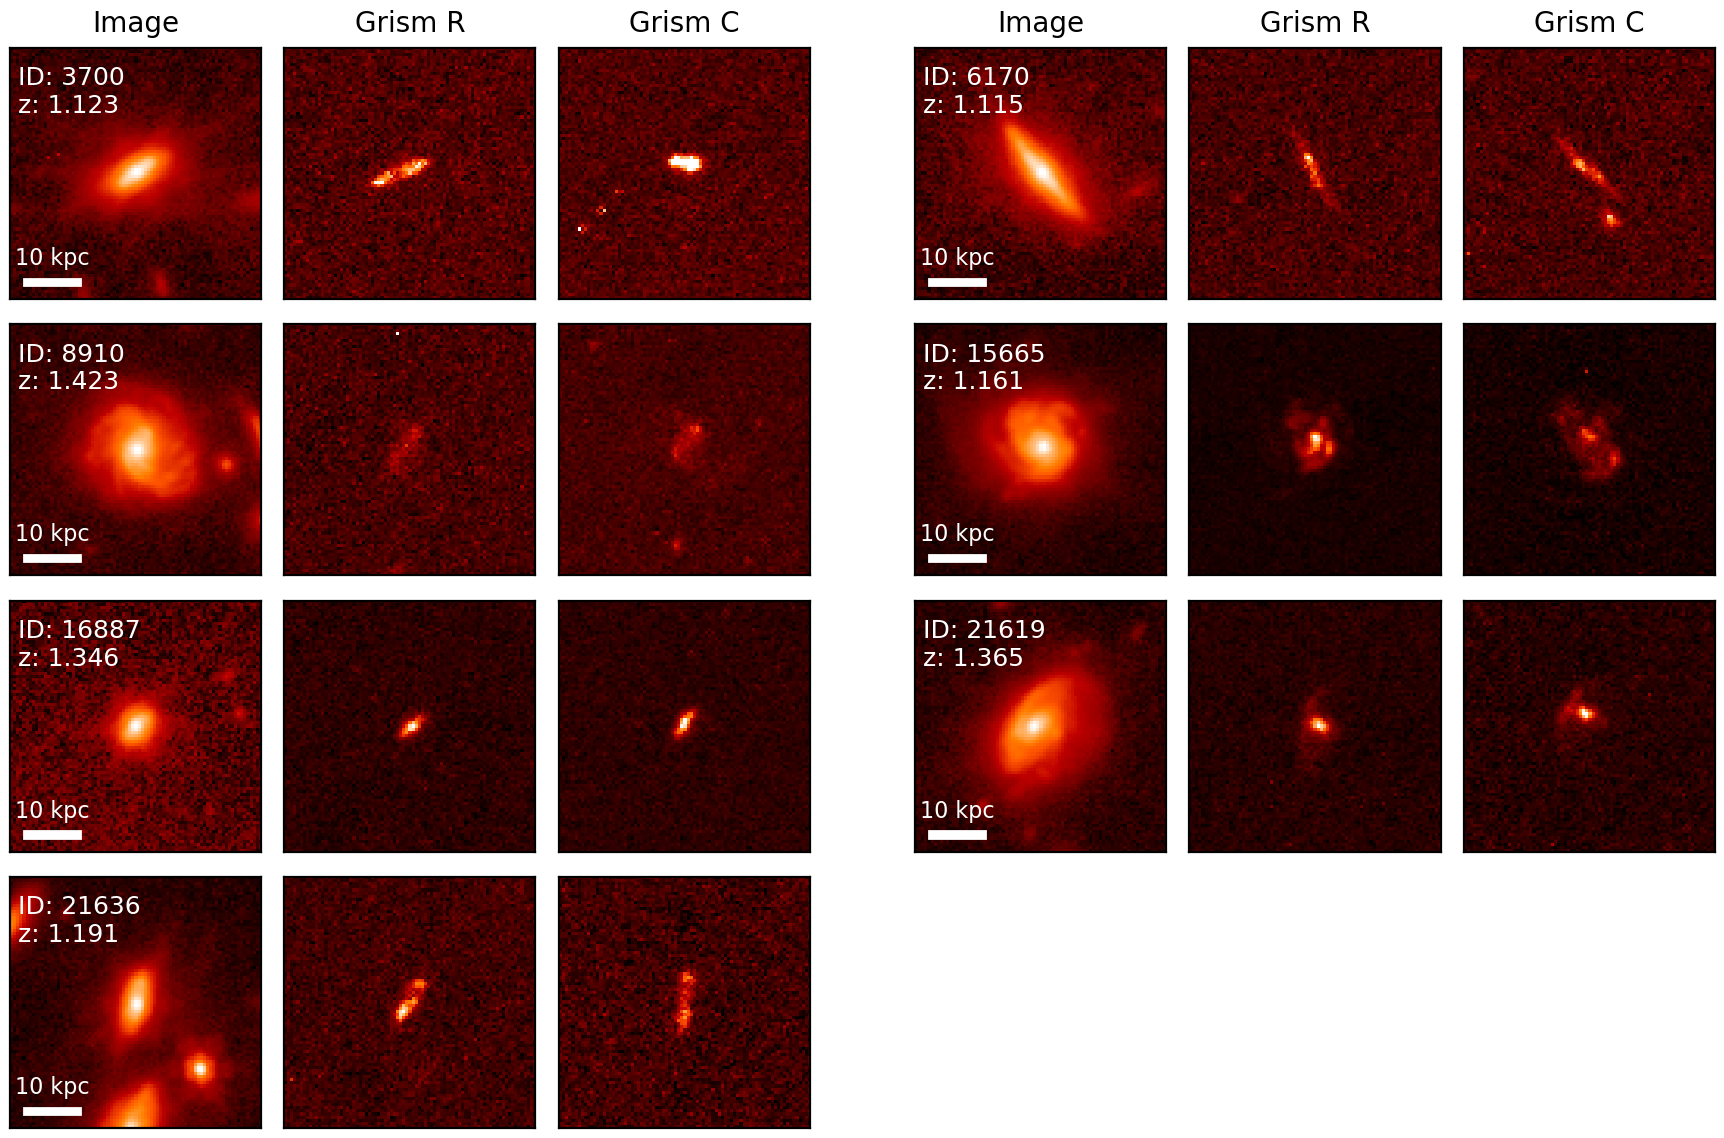

In [277]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import Planck15 as cosmo
import matplotlib.patches as patches
from astropy.stats import sigma_clipped_stats
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

def asinhstretch(im):
    return np.arcsinh(im / sigma_clipped_stats(im)[2])

def plot_cutout_grid(paA_table_filtered, direct_cutouts_list, grismR_cutouts_list, grismC_cutouts_list, ncols=2):
    nrows = int(np.ceil(len(paA_table_filtered) / ncols))
    print(ncols, nrows)
    fig = plt.figure(figsize=(4.5 * ncols, 1.5 * nrows))
    outer = GridSpec(nrows, ncols, wspace=0.1, hspace=0.1)  # less gap between sources

    for idx, row in enumerate(paA_table_filtered):
        r, c = divmod(idx, ncols)
        inner = GridSpecFromSubplotSpec(
            1, 3,
            subplot_spec=outer[r, c],
            wspace=0.0,
            width_ratios=[1, 1, 1]
        )

        ID, z = row['ID'], row['z']
        coadd_image = direct_cutouts_list[idx]
        coadd_R = grismR_cutouts_list[idx]
        coadd_C = grismC_cutouts_list[idx]
        cutouts = [asinhstretch(coadd_image), coadd_R, coadd_C]
        titles = ['Image', 'Grism R', 'Grism C']

        for j in range(3):
            ax = fig.add_subplot(inner[j])
            
            # unify colorbar
            if j==0:
                ax.imshow(cutouts[j], origin='lower', cmap='gist_heat')
            else:
                mean, median, std = sigma_clipped_stats(cutouts[1])
                vmin = mean - std*3
                # vmax = mean + std*10
                vmax = min(np.max(cutouts[0]), np.max(cutouts[1]))
                ax.imshow(cutouts[j], origin='lower', cmap='gist_heat', vmin=vmin, vmax=vmax)

            # Remove all axes and grids
            ax.set_xticks([])
            ax.set_yticks([])
            ax.grid(False)
            for spine in ax.spines.values():
                spine.set_edgecolor('black')
                spine.set_linewidth(0.8)

            # Titles only on first row
            if r == 0:
                ax.set_title(titles[j], fontsize=10)

            # Annotate only the direct image
            if j == 0:
                ax.text(0.03, 0.93, f'ID: {ID}\nz: {z:.3f}',
                        transform=ax.transAxes,
                        fontsize=9, ha='left', va='top', c='white')
                        # bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

                ang_diam_dist = cosmo.angular_diameter_distance(z).to('kpc')
                kpc_per_arcsec = ang_diam_dist.value / 206265
                pixel_scale = 0.063  # arcsec/pixel
                pixels_per_kpc = 1 / (kpc_per_arcsec * pixel_scale)
                bar_length_pix = int(10 * pixels_per_kpc)

                y_bar = coadd_image.shape[0] * 0.05
                x_bar_start = coadd_image.shape[1] * 0.05
                rect = patches.Rectangle((x_bar_start, y_bar), bar_length_pix, 2, color='white')
                ax.add_patch(rect)
                ax.text(x_bar_start + bar_length_pix / 2, y_bar + 5, '10 kpc',
                        color='white', ha='center', va='bottom', fontsize=8)

    # Fine-tune global figure padding (no tight_layout)
    plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.05)
    plt.savefig('fig/source_profile.pdf')
    plt.show()

plot_cutout_grid(paA_table_filtered, direct_cutouts_list, grismR_cutouts_list, grismC_cutouts_list, ncols=2)


In [278]:
for i in range(len(paA_table_filtered)):
    id = paA_table_filtered['ID'][i]
    this_dir = f'resolved/{FILTER}_ID{id}'
    print(this_dir)
    os.makedirs(this_dir, exist_ok=True)

    # 1. 写 image.fits（无 MODULE）
    fits.writeto(os.path.join(this_dir, 'image.fits'),
                 direct_cutouts_list[i], overwrite=True)

    # 2. 写 R.fits + MODULE header
    hR = fits.Header()
    hR['MODULE'] = grismR_module_list[i]
    fits.writeto(os.path.join(this_dir, 'R.fits'),
                 grismR_cutouts_list[i], header=hR, overwrite=True)

    # 3. 写 C.fits + MODULE header
    hC = fits.Header()
    hC['MODULE'] = grismC_module_list[i]
    fits.writeto(os.path.join(this_dir, 'C.fits'),
                 grismC_cutouts_list[i], header=hC, overwrite=True)


resolved/F444W_ID3700
resolved/F444W_ID6170
resolved/F444W_ID8910
resolved/F444W_ID15665
resolved/F444W_ID16887
resolved/F444W_ID21619
resolved/F444W_ID21636


## Fit Roataion Curve

In [279]:
ids = [3700, 6170, 8910, 15665, 16887, 21619, 21636]

23:01:28 - WARNING - dingo.fitting - The following override keys are not used: {'velocity.v_rot'}
23:01:28 - INFO - dingo.fitting - Starting fitting stage 1/1: method=Adam
23:01:28 - INFO - dingo.fitting - Stage 1, Step 1, loss=0.087258, lr=0.05000xy_iters=(16, 22)


Fitting ID 3700
[{'image.C.dx': FitParamConfig(name='image.C.dx', value=0.0, lr=0.2, fit=True, 'image.C.dy': FitParamConfig(name='image.C.dy', value=0.0, lr=0.2, fit=True, 'image.C.forward_model': FitParamConfig(name='image.C.forward_model', value=<function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f171eda7ec0>, lr=0, fit=False}]


23:01:30 - INFO - dingo.fitting - Stage 1, Step 100, loss=0.052489, lr=0.05000xy_iters=(3, 6)
23:01:31 - INFO - dingo.fitting - Stage 1, Step 200, loss=0.05247, lr=0.05000xy_iters=(4, 6)
23:01:32 - INFO - dingo.fitting - Stage 1, Step 300, loss=0.052454, lr=0.05000xy_iters=(6, 11)
23:01:34 - INFO - dingo.fitting - Stage 1, Step 400, loss=0.052456, lr=0.05000xy_iters=(5, 11)
23:01:36 - INFO - dingo.fitting - Stage 1, Step 500, loss=0.052431, lr=0.05000xy_iters=(5, 9)



[Velocity]
V_rot      = -310.76483154296875
R_v        = 2.0630686283111572
x0_v       = 40.958560943603516
y0_v       = 39.8217658996582
theta_v    = 0.46669915318489075
inc_v      = 0.8483580946922302

[Dispersion R]
dx         = 3.7711076736450195
dy         = -0.28513672947883606
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f17d85abf60>

[Dispersion C]
dx         = 0.3236863315105438
dy         = -1.6977614164352417
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f171eda7ec0>


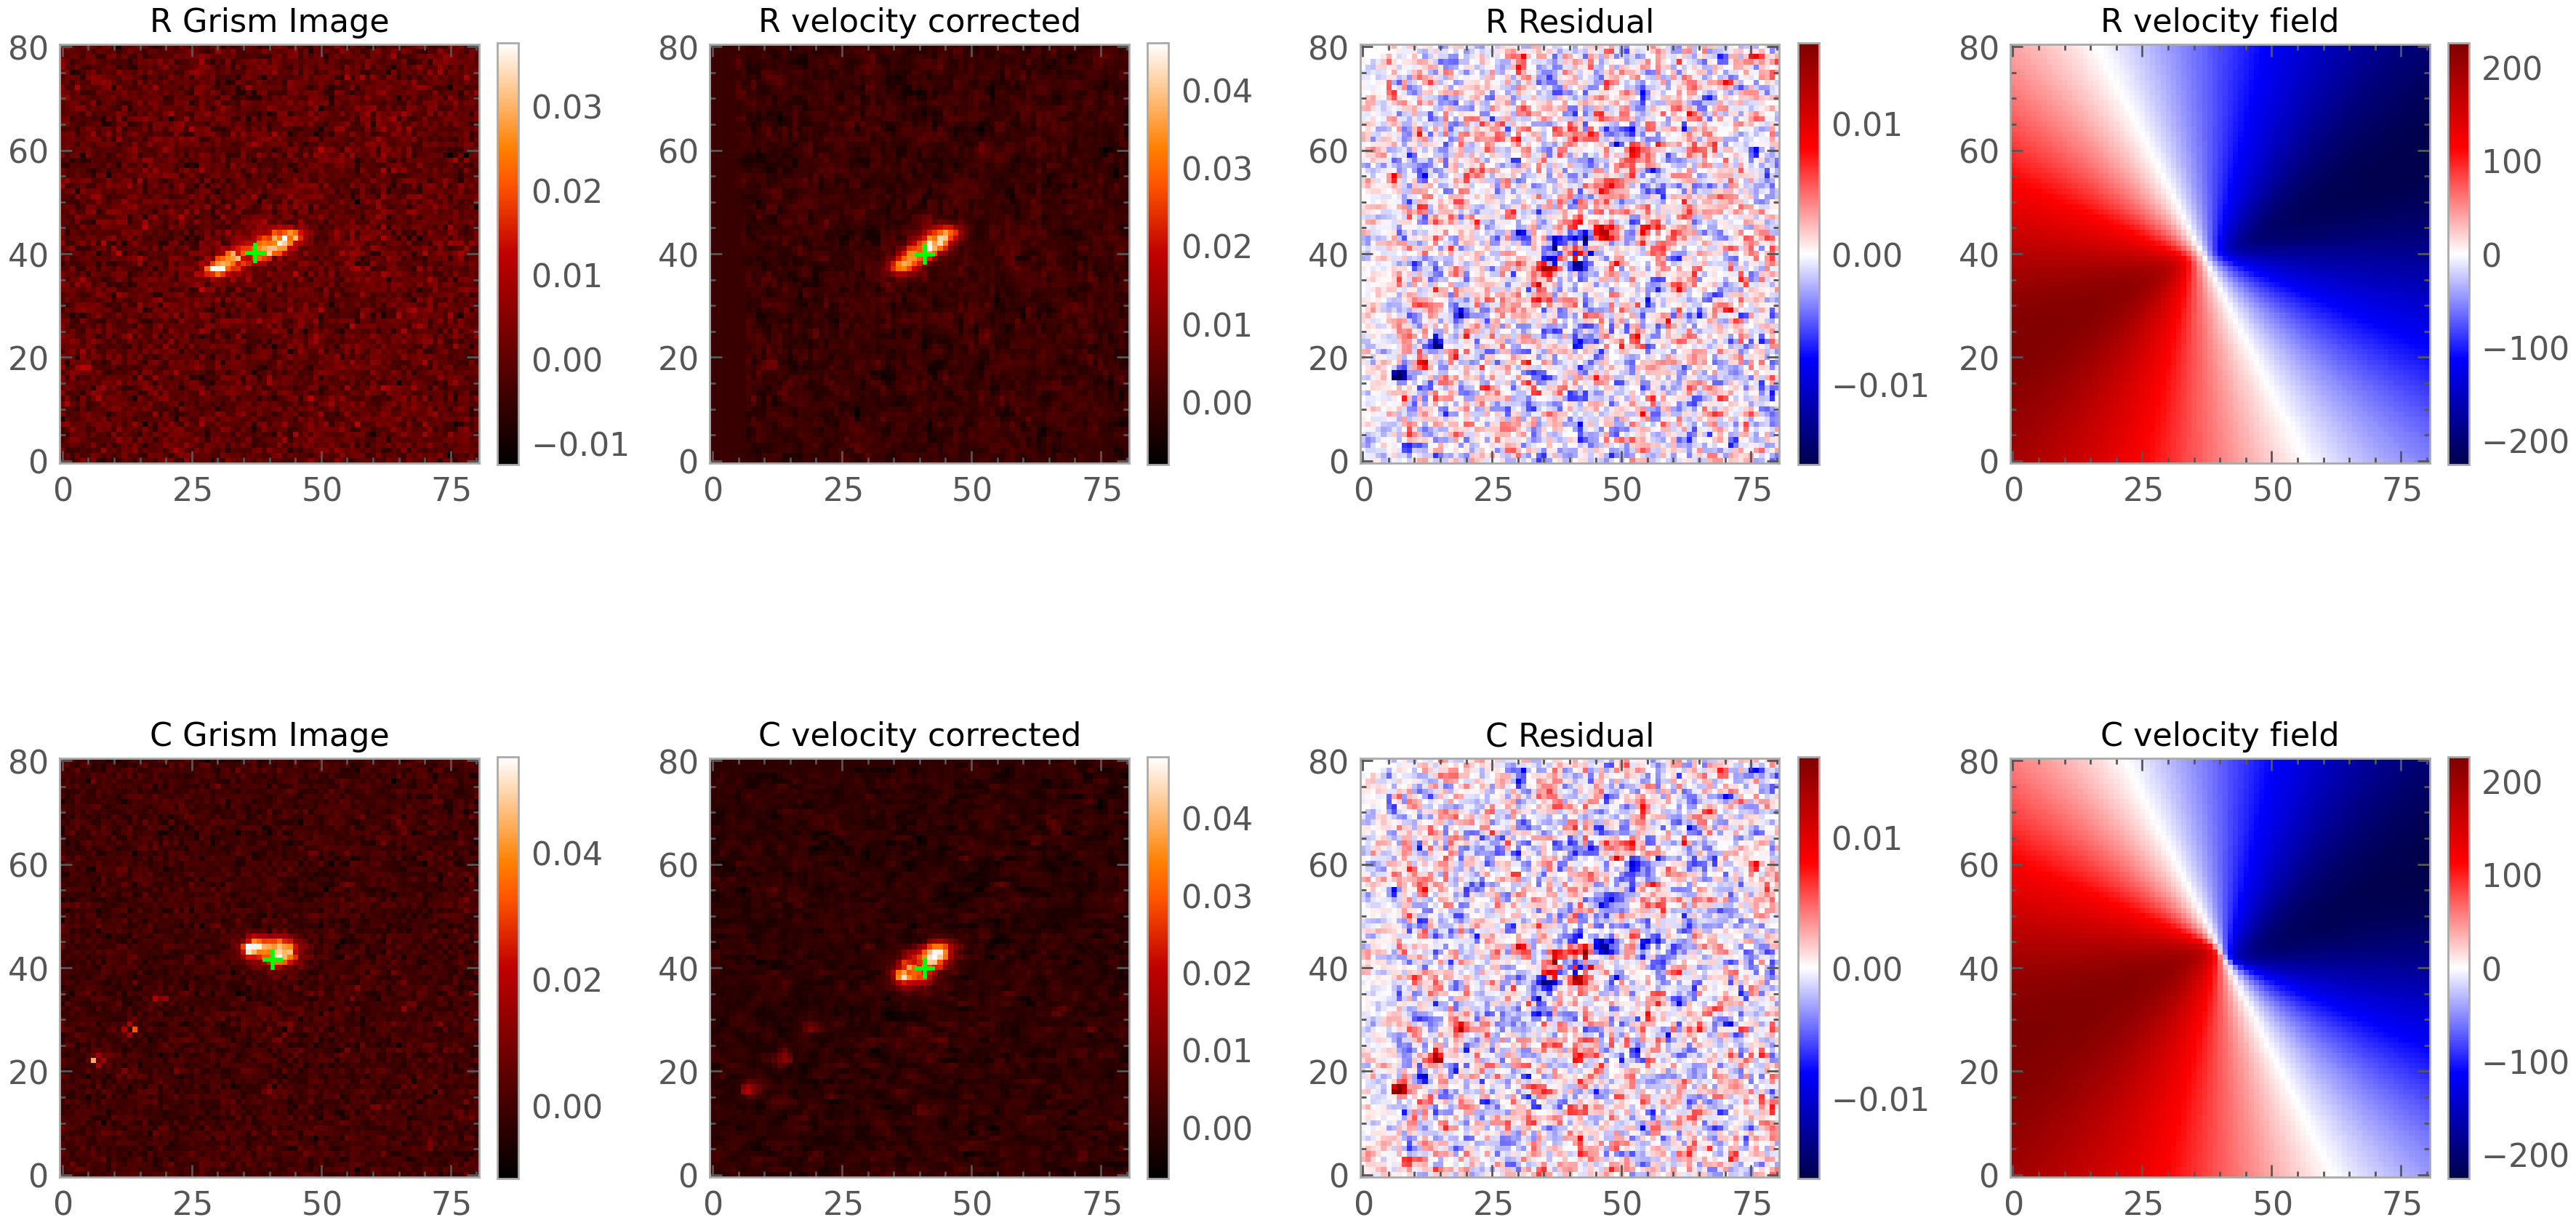

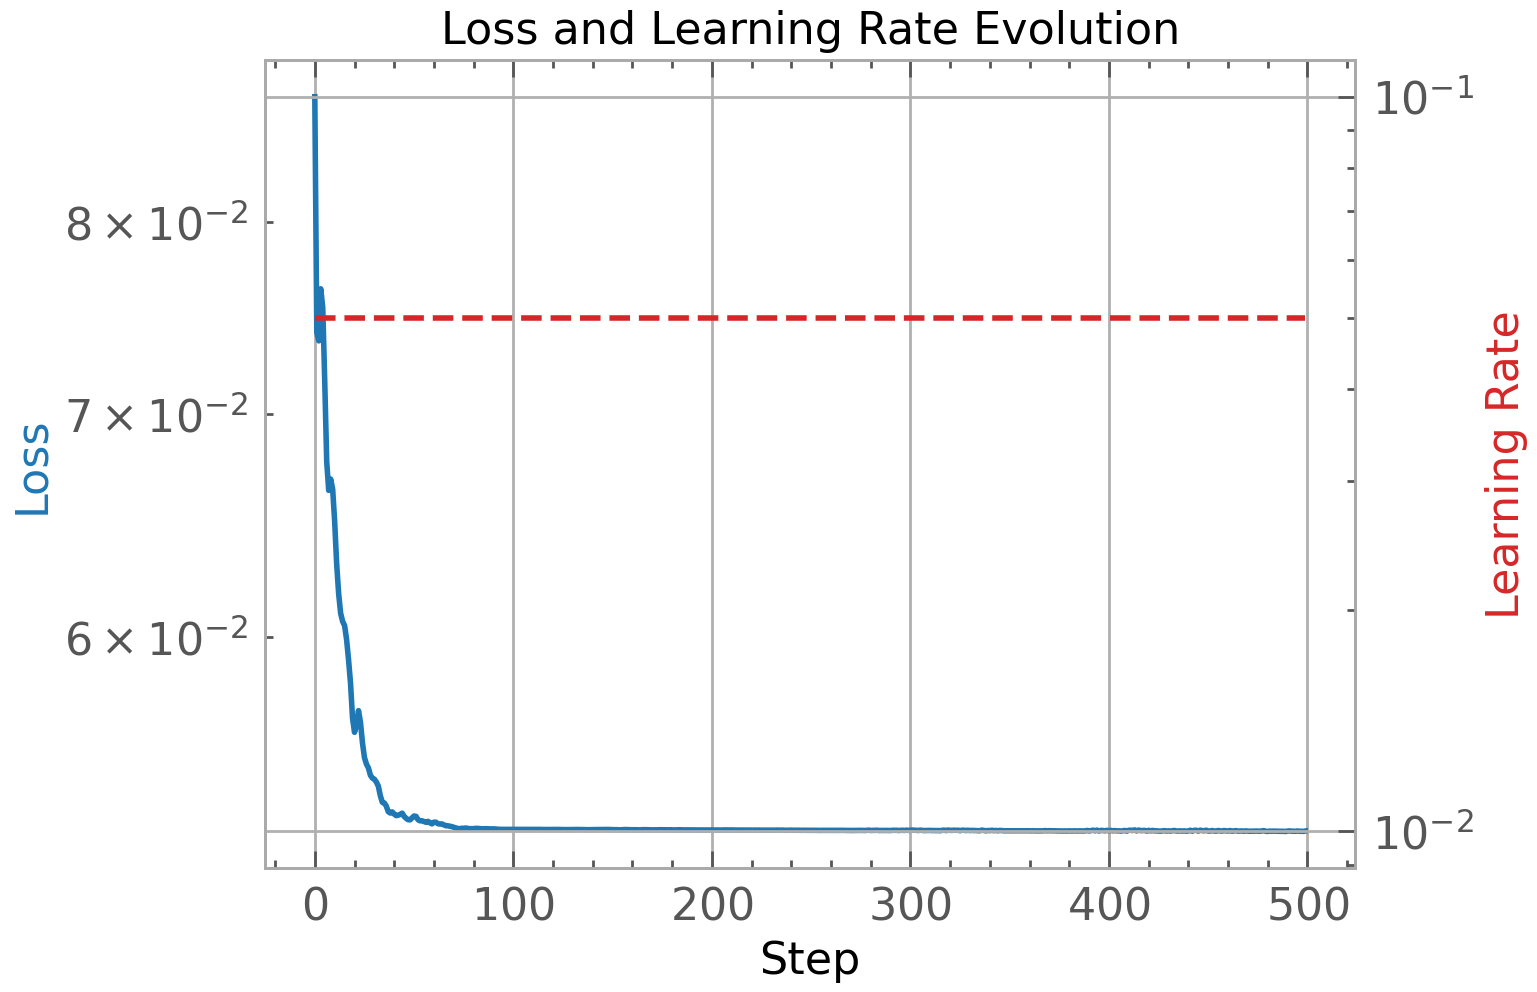

23:01:38 - WARNING - dingo.fitting - The following override keys are not used: {'velocity.v_rot'}
23:01:38 - INFO - dingo.fitting - Starting fitting stage 1/1: method=Adam
23:01:38 - INFO - dingo.fitting - Stage 1, Step 1, loss=0.11786, lr=0.05000xy_iters=(37, 34)


Fitting ID 6170
[{'image.C.dx': FitParamConfig(name='image.C.dx', value=0.0, lr=0.2, fit=True, 'image.C.dy': FitParamConfig(name='image.C.dy', value=0.0, lr=0.2, fit=True, 'image.C.forward_model': FitParamConfig(name='image.C.forward_model', value=<function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f171eda7380>, lr=0, fit=False}]


23:01:40 - INFO - dingo.fitting - Stage 1, Step 100, loss=0.073293, lr=0.05000xy_iters=(4, 4)
23:01:42 - INFO - dingo.fitting - Stage 1, Step 200, loss=0.073141, lr=0.05000xy_iters=(4, 3)
23:01:43 - INFO - dingo.fitting - Stage 1, Step 300, loss=0.073078, lr=0.05000xy_iters=(4, 8)
23:01:45 - INFO - dingo.fitting - Stage 1, Step 400, loss=0.073061, lr=0.05000xy_iters=(6, 7)
23:01:46 - INFO - dingo.fitting - Stage 1, Step 500, loss=0.073051, lr=0.05000xy_iters=(5, 3)



[Velocity]
V_rot      = 308.08697509765625
R_v        = 2.7911031246185303
x0_v       = 37.02389907836914
y0_v       = 38.32737731933594
theta_v    = -0.7224923968315125
inc_v      = 0.7347735166549683

[Dispersion R]
dx         = -0.32302236557006836
dy         = -0.2755032479763031
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f172c89d260>

[Dispersion C]
dx         = 0.35382184386253357
dy         = -0.16370397806167603
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f171eda7380>


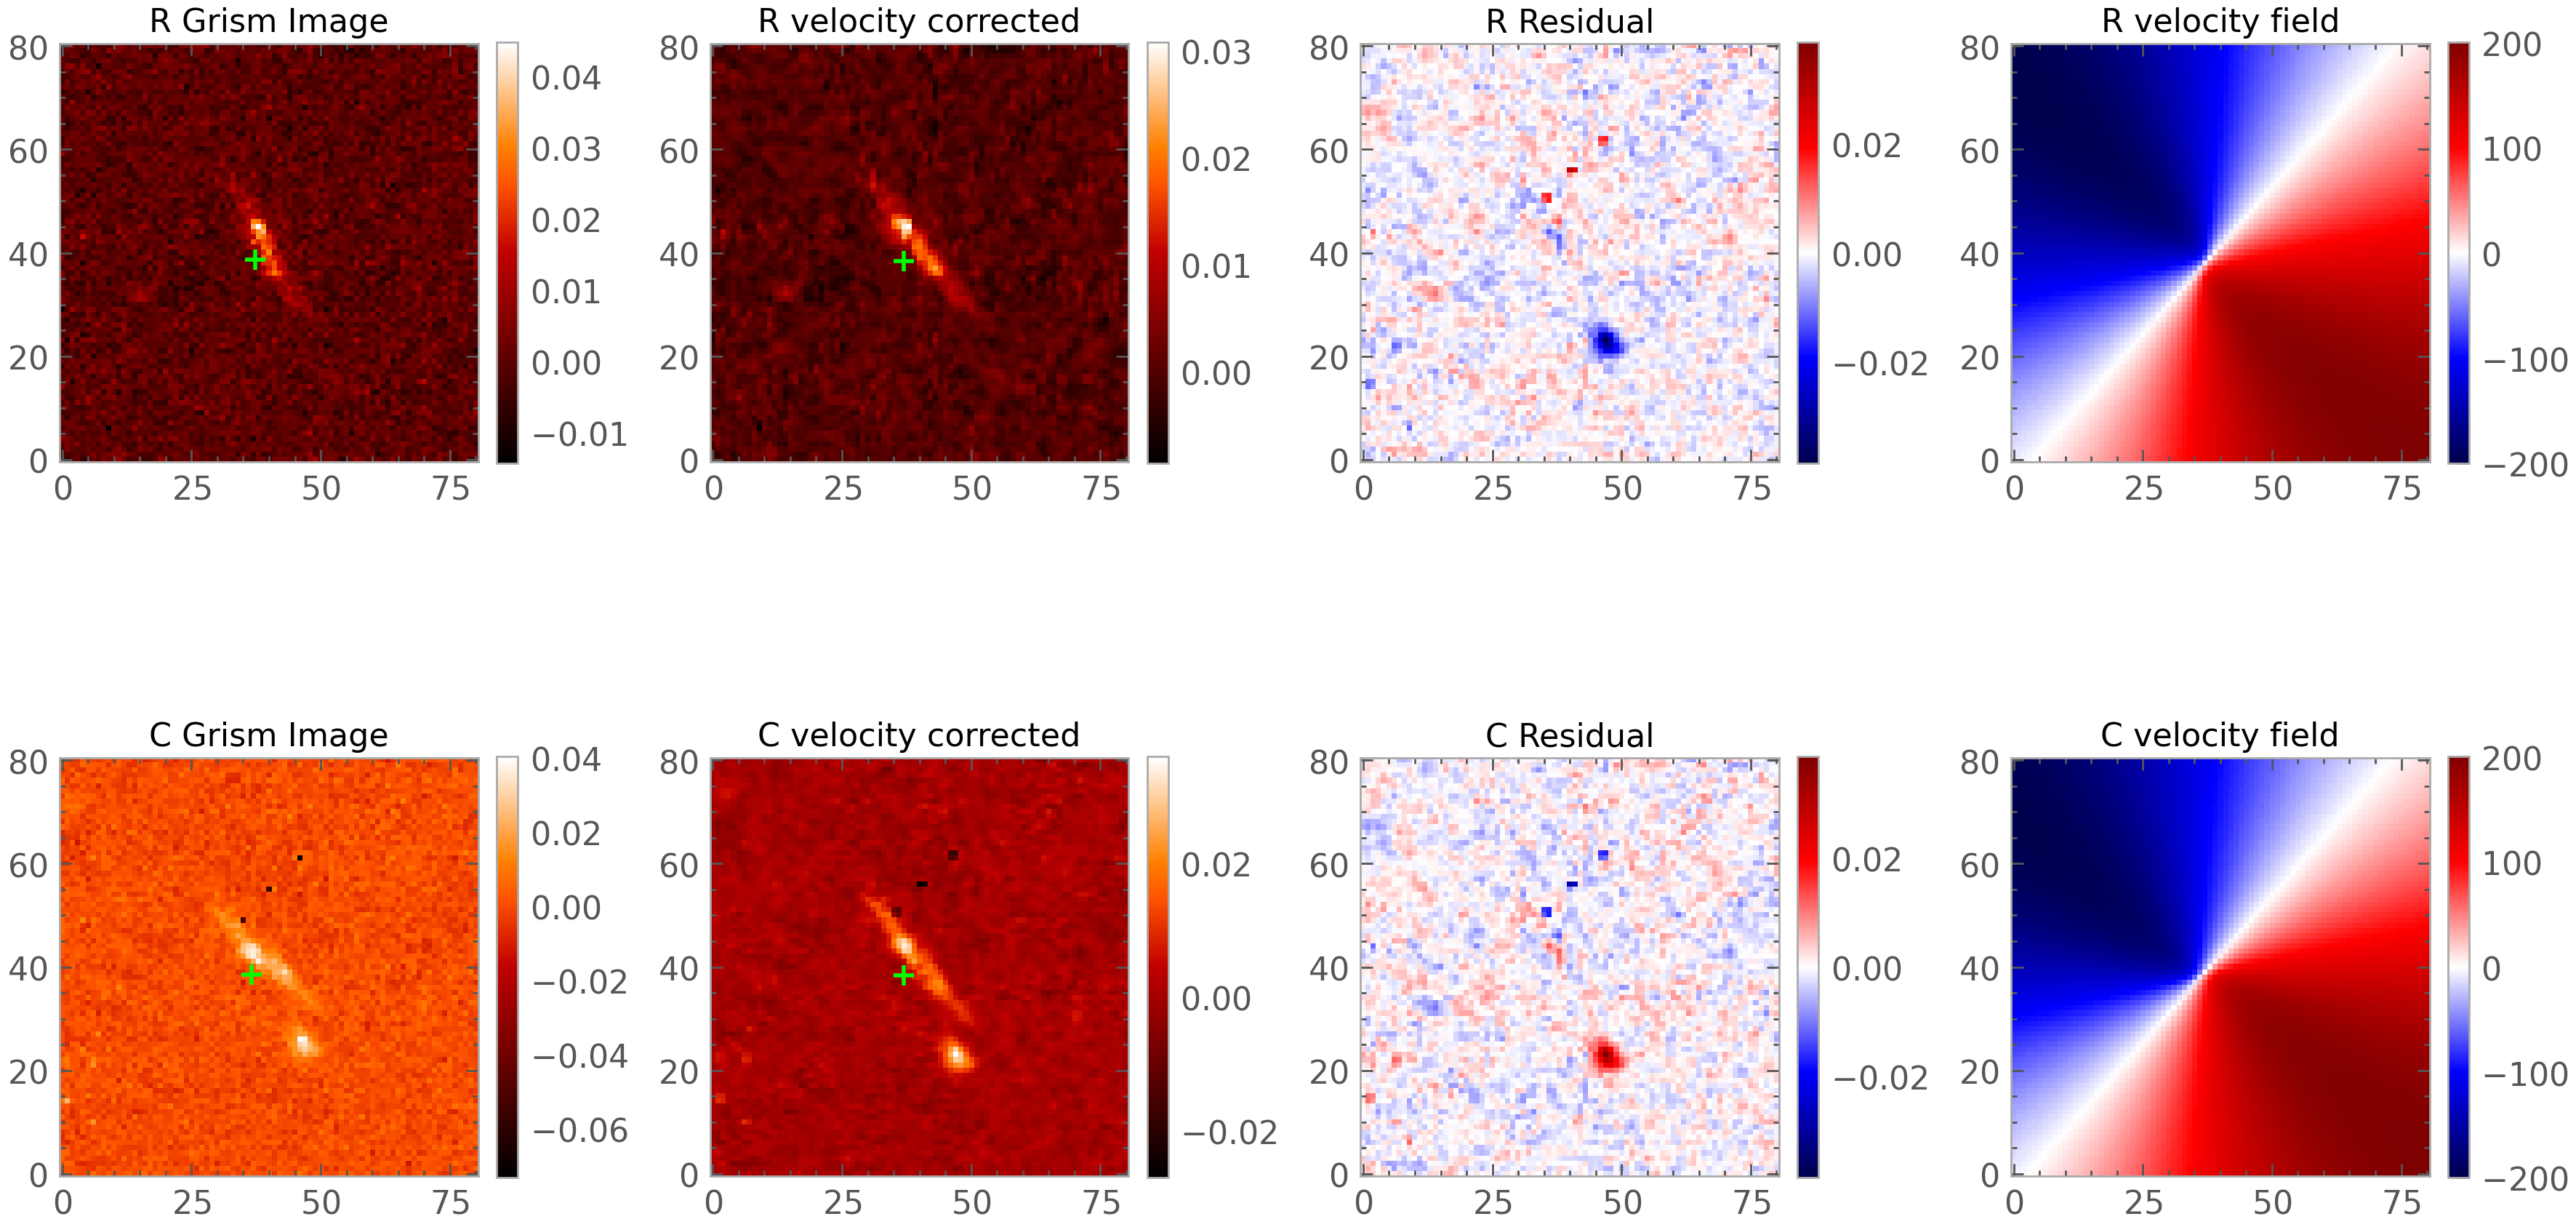

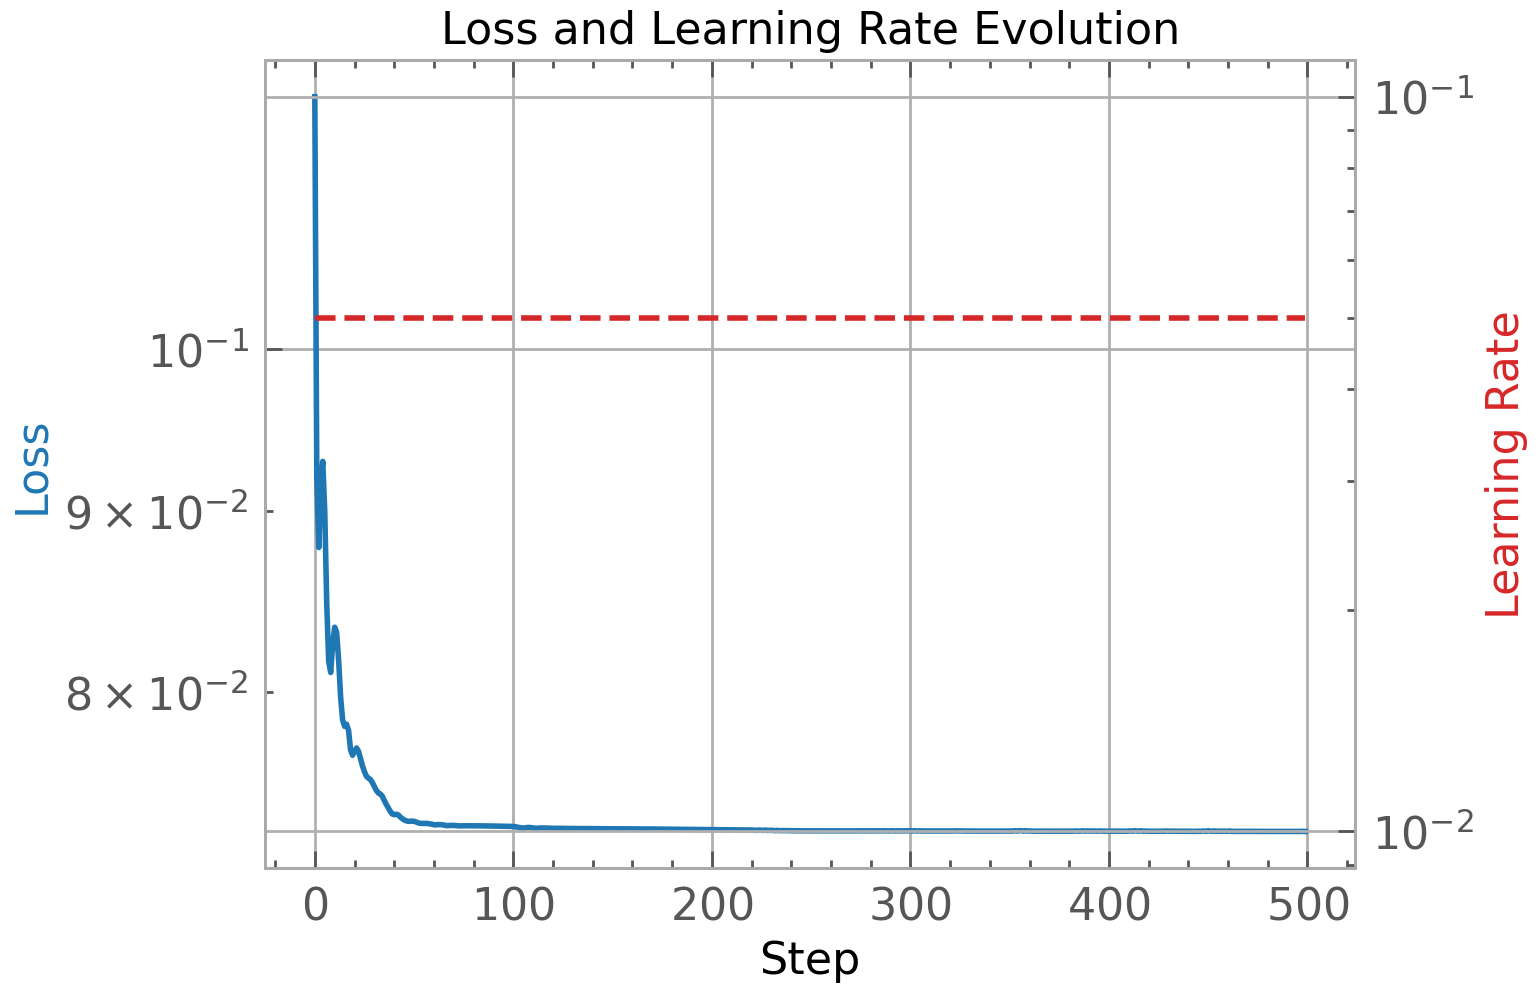

23:01:49 - WARNING - dingo.fitting - The following override keys are not used: {'velocity.v_rot'}
23:01:49 - INFO - dingo.fitting - Starting fitting stage 1/1: method=Adam
23:01:49 - INFO - dingo.fitting - Stage 1, Step 1, loss=0.26168, lr=0.05000xy_iters=(49, 39)


Fitting ID 8910
[{'image.C.dx': FitParamConfig(name='image.C.dx', value=0.0, lr=0.1, fit=True, 'image.C.dy': FitParamConfig(name='image.C.dy', value=0.0, lr=0.1, fit=True, 'image.C.forward_model': FitParamConfig(name='image.C.forward_model', value=<function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f17989b5800>, lr=0, fit=False}]


23:01:52 - INFO - dingo.fitting - Stage 1, Step 100, loss=0.1795, lr=0.05000xy_iters=(9, 8)
23:01:53 - INFO - dingo.fitting - Stage 1, Step 200, loss=0.17563, lr=0.05000xy_iters=(6, 7)
23:01:55 - INFO - dingo.fitting - Stage 1, Step 300, loss=0.17431, lr=0.05000xy_iters=(6, 7)
23:01:57 - INFO - dingo.fitting - Stage 1, Step 400, loss=0.17418, lr=0.05000xy_iters=(6, 7)
23:01:58 - INFO - dingo.fitting - Stage 1, Step 500, loss=0.17404, lr=0.05000xy_iters=(5, 5)



[Velocity]
V_rot      = 314.3204345703125
R_v        = 3.3336048126220703
x0_v       = 33.70013427734375
y0_v       = 37.7421760559082
theta_v    = -0.41449519991874695
inc_v      = 0.7822303175926208

[Dispersion R]
dx         = 0.5181827545166016
dy         = 0.30899766087532043
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f17989b4680>

[Dispersion C]
dx         = -0.016050314530730247
dy         = 1.229909062385559
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f17989b5800>


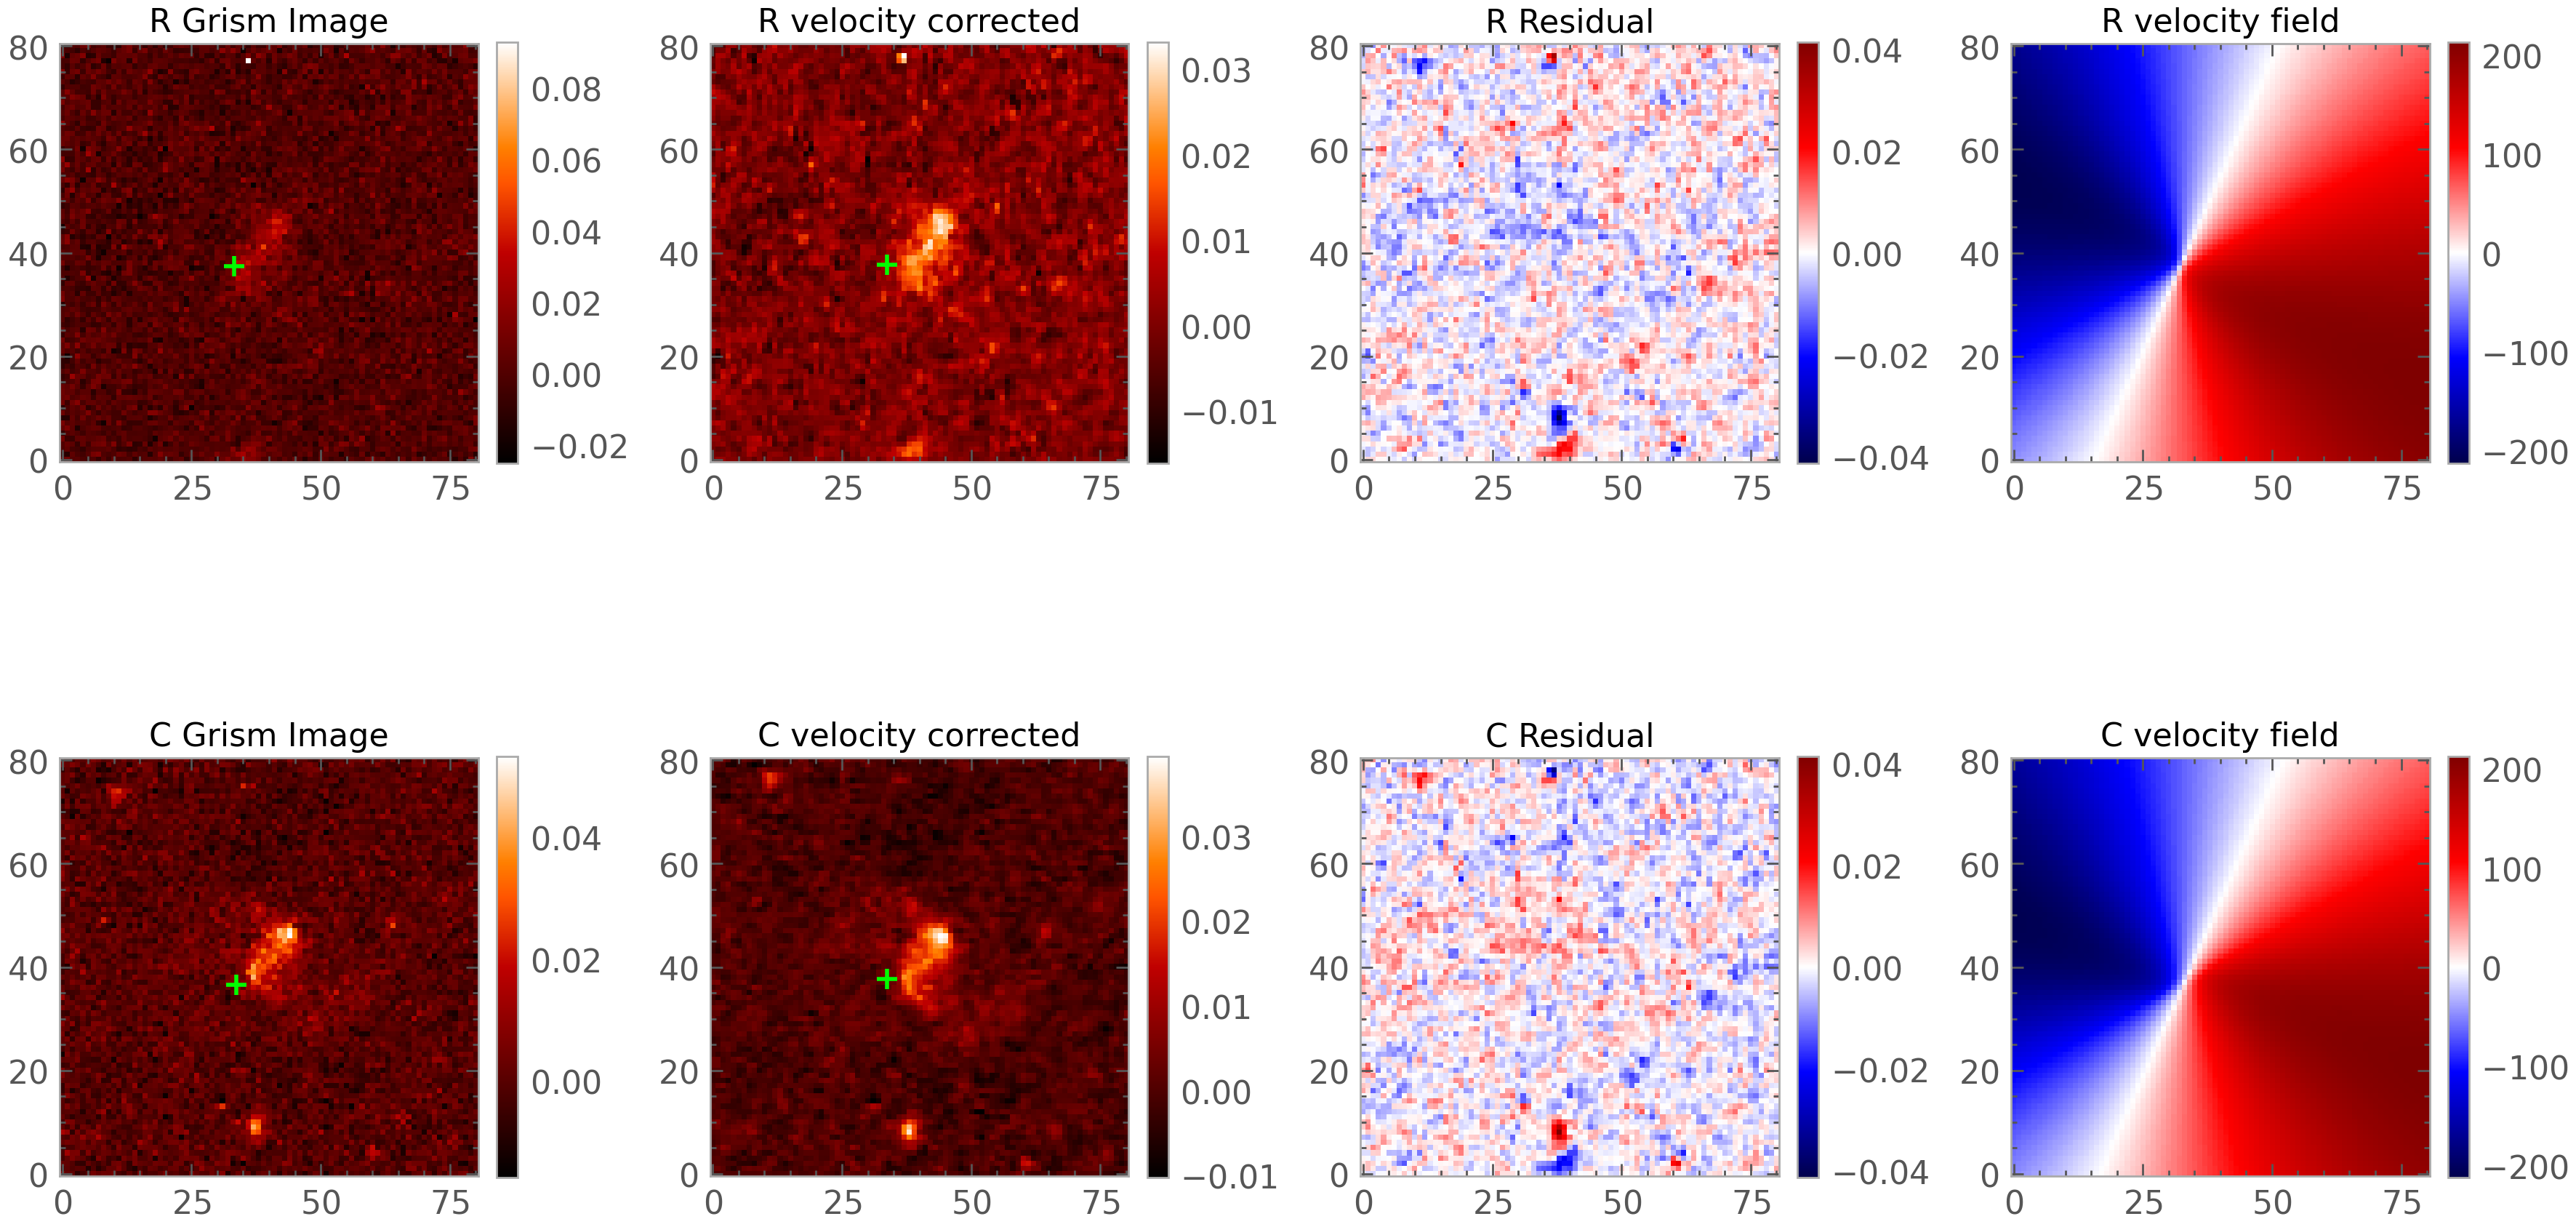

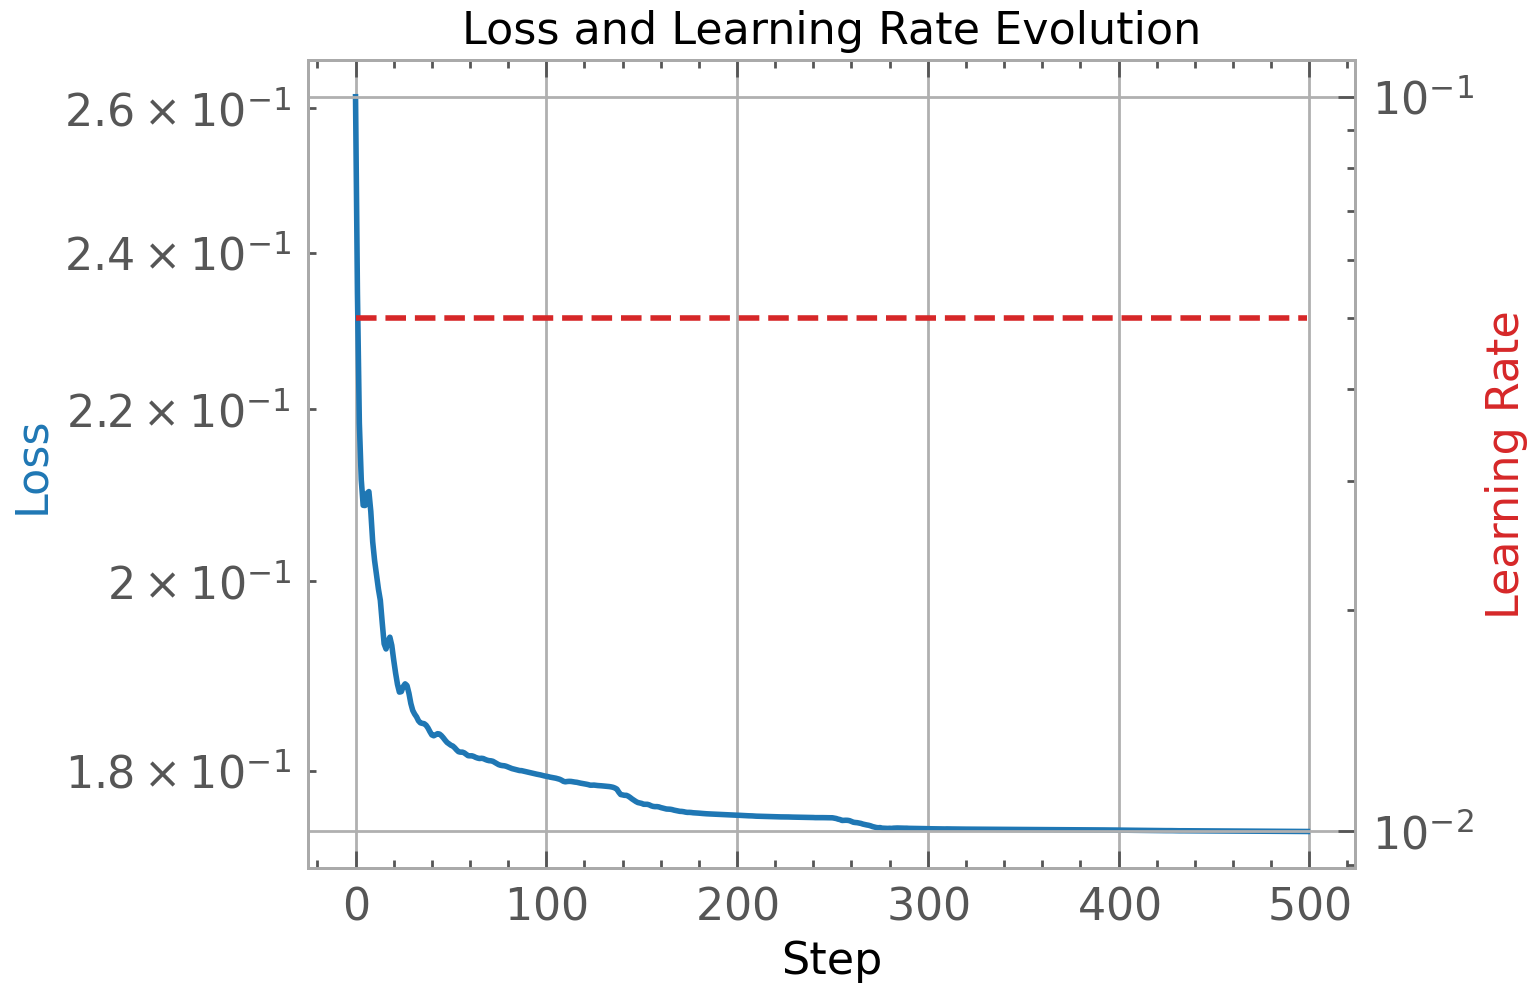

23:02:01 - WARNING - dingo.fitting - The following override keys are not used: {'velocity.v_rot'}
23:02:01 - INFO - dingo.fitting - Starting fitting stage 1/1: method=Adam
23:02:01 - INFO - dingo.fitting - Stage 1, Step 1, loss=0.28352, lr=0.05000xy_iters=(49, 33)


Fitting ID 15665
[{'image.C.dx': FitParamConfig(name='image.C.dx', value=0.0, lr=0.1, fit=True, 'image.C.dy': FitParamConfig(name='image.C.dy', value=0.0, lr=0.1, fit=True, 'image.C.forward_model': FitParamConfig(name='image.C.forward_model', value=<function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f1798379c60>, lr=0, fit=False}]


23:02:03 - INFO - dingo.fitting - Stage 1, Step 100, loss=0.16804, lr=0.05000xy_iters=(7, 4)
23:02:05 - INFO - dingo.fitting - Stage 1, Step 200, loss=0.13861, lr=0.05000xy_iters=(8, 6)
23:02:07 - INFO - dingo.fitting - Stage 1, Step 300, loss=0.13564, lr=0.05000xy_iters=(7, 3)
23:02:08 - INFO - dingo.fitting - Stage 1, Step 400, loss=0.13552, lr=0.05000xy_iters=(5, 2)
23:02:09 - INFO - dingo.fitting - Stage 1, Step 500, loss=0.13537, lr=0.05000xy_iters=(5, 5)



[Velocity]
V_rot      = -312.7334289550781
R_v        = 2.341222047805786
x0_v       = 42.295494079589844
y0_v       = 41.379669189453125
theta_v    = -0.7654838562011719
inc_v      = 0.6937834620475769

[Dispersion R]
dx         = 2.4372243881225586
dy         = 0.2525181174278259
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f17991459e0>

[Dispersion C]
dx         = -0.10941515117883682
dy         = 2.367525577545166
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f1798379c60>


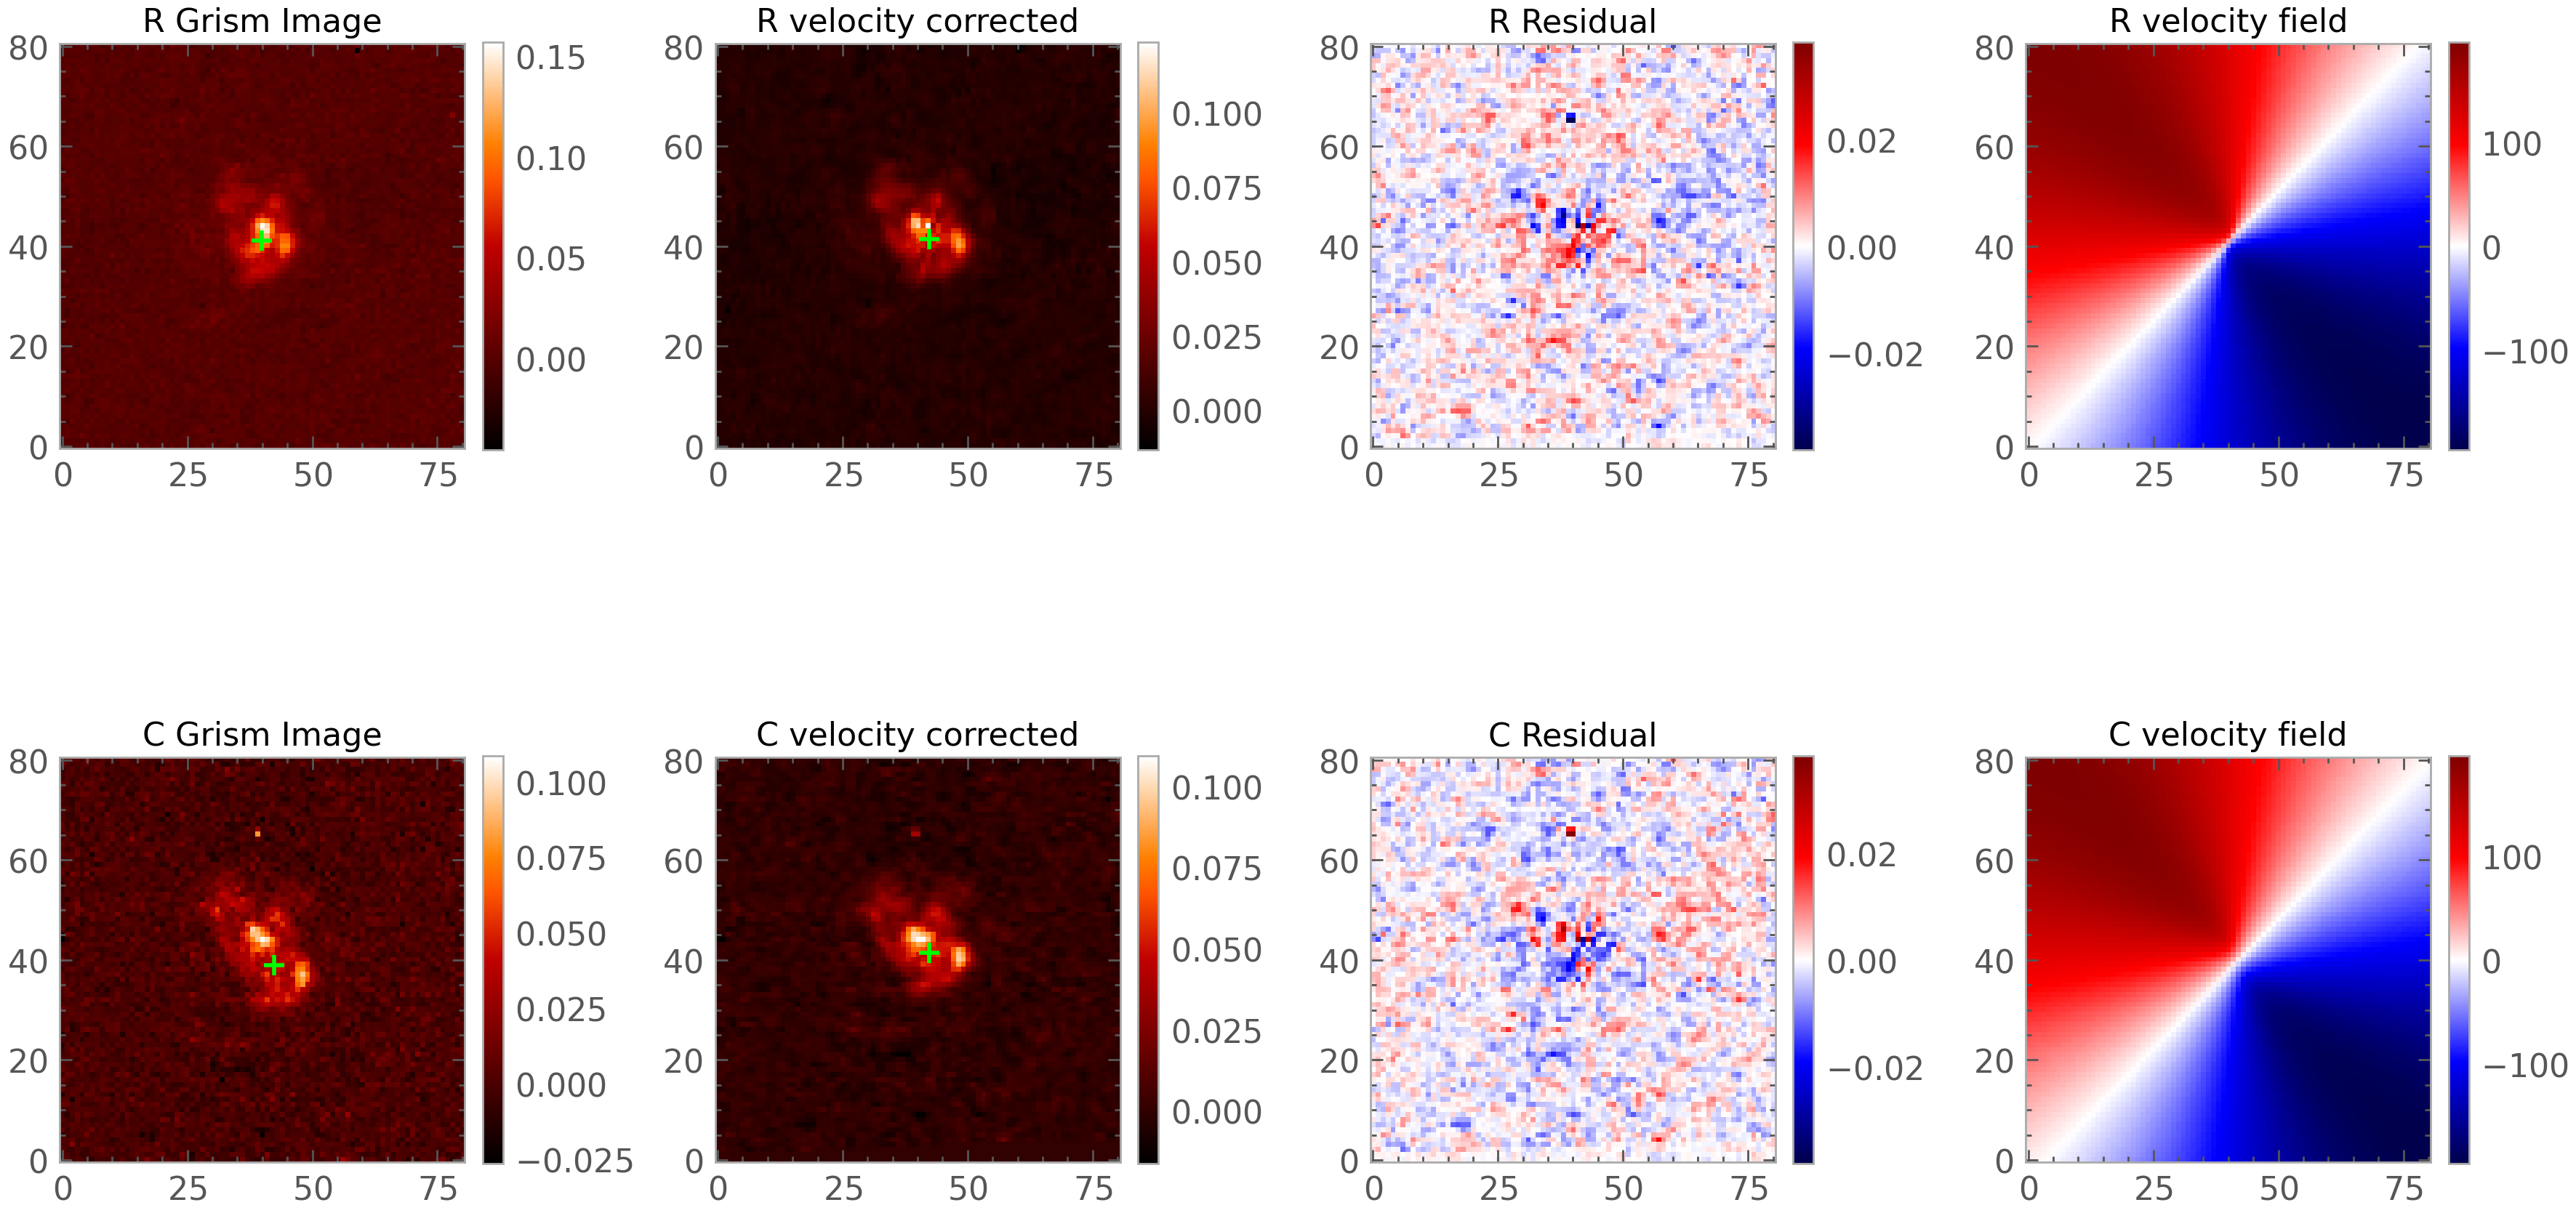

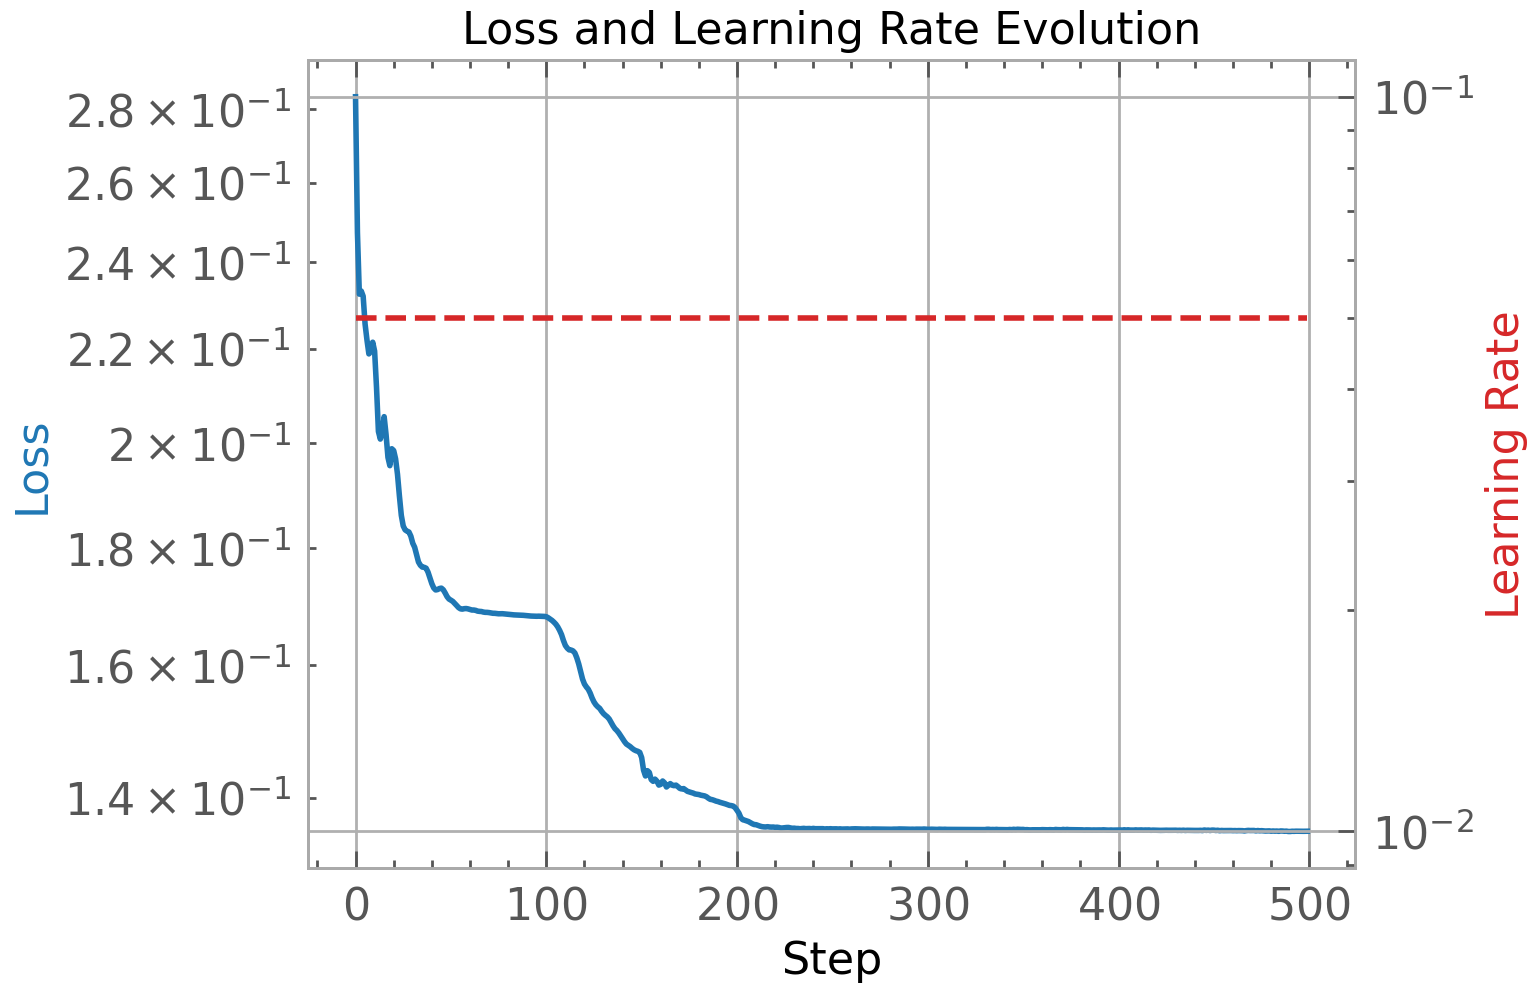

23:02:12 - WARNING - dingo.fitting - The following override keys are not used: {'velocity.v_rot'}
23:02:12 - INFO - dingo.fitting - Starting fitting stage 1/1: method=Adam
23:02:12 - INFO - dingo.fitting - Stage 1, Step 1, loss=0.18227, lr=0.05000xy_iters=(19, 40)


Fitting ID 16887
[{'image.C.dx': FitParamConfig(name='image.C.dx', value=0.0, lr=0.1, fit=True, 'image.C.dy': FitParamConfig(name='image.C.dy', value=0.0, lr=0.1, fit=True, 'image.C.forward_model': FitParamConfig(name='image.C.forward_model', value=<function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f17d8584a40>, lr=0, fit=False}]


23:02:14 - INFO - dingo.fitting - Stage 1, Step 100, loss=0.07424, lr=0.05000xy_iters=(4, 3)
23:02:14 - INFO - dingo.fitting - Stage 1, Step 200, loss=0.074023, lr=0.05000xy_iters=(2, 1)
23:02:15 - INFO - dingo.fitting - Stage 1, Step 300, loss=0.07393, lr=0.05000xy_iters=(2, 2)
23:02:16 - INFO - dingo.fitting - Stage 1, Step 400, loss=0.073922, lr=0.05000xy_iters=(1, 2)
23:02:17 - INFO - dingo.fitting - Stage 1, Step 500, loss=0.073919, lr=0.05000xy_iters=(1, 1)



[Velocity]
V_rot      = 299.1842041015625
R_v        = 2.0372092723846436
x0_v       = 41.395748138427734
y0_v       = 39.54587936401367
theta_v    = 0.6348943114280701
inc_v      = 0.26331958174705505

[Dispersion R]
dx         = 0.3622676730155945
dy         = 0.3741094470024109
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f17d8585c60>

[Dispersion C]
dx         = 0.44019049406051636
dy         = -0.2730136215686798
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f17d8584a40>


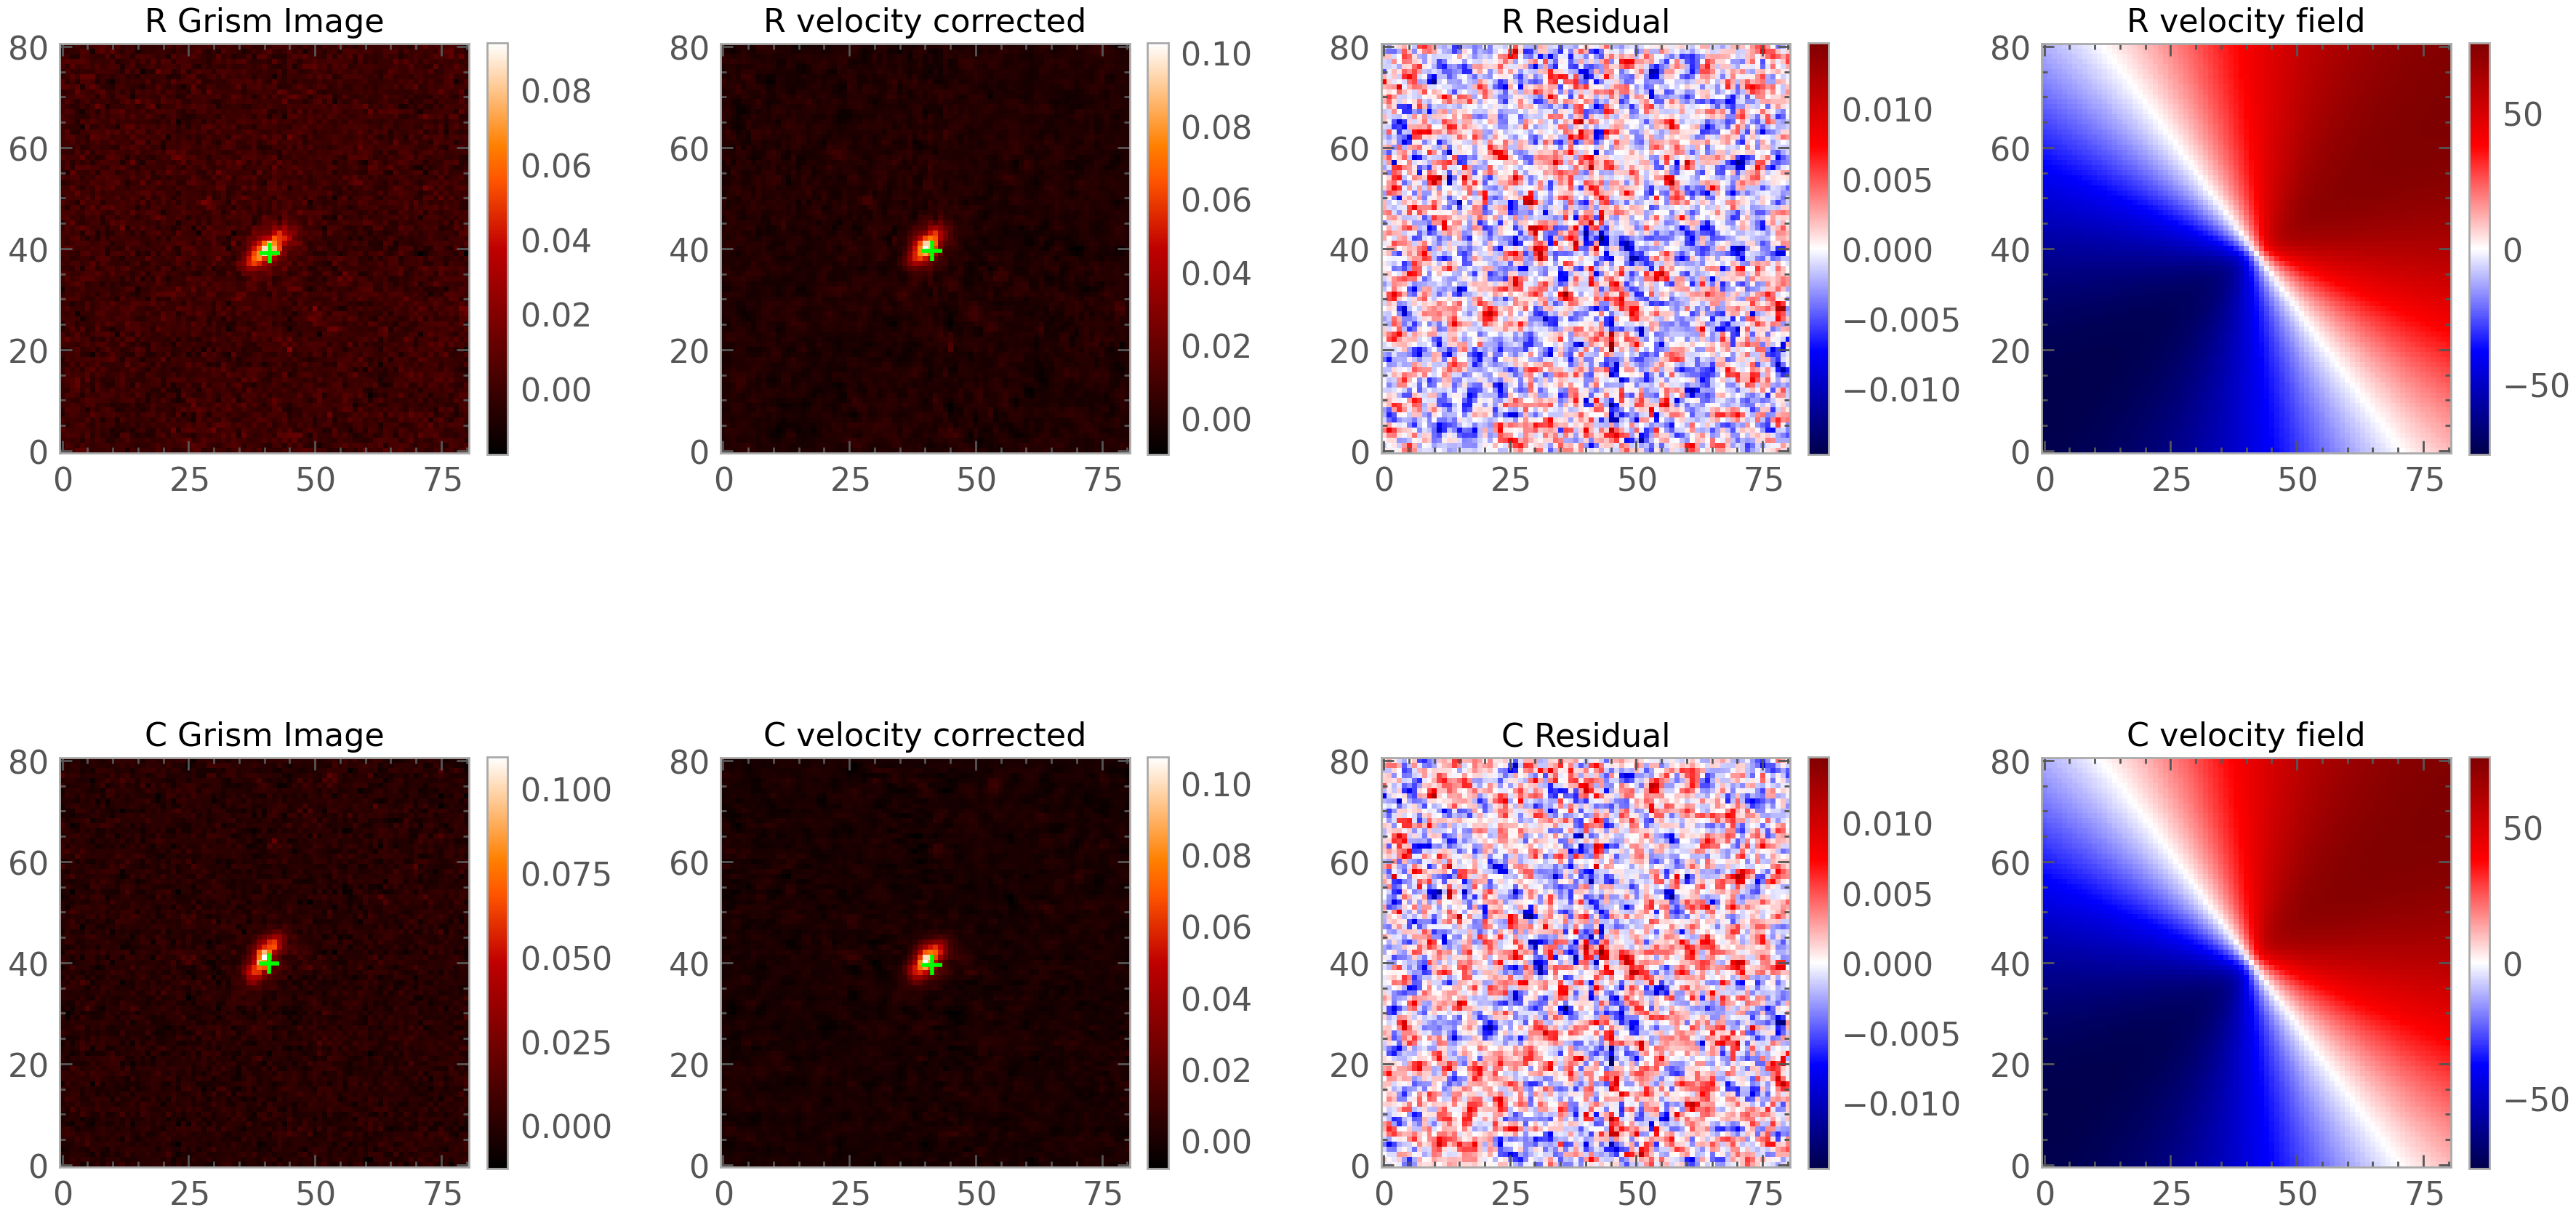

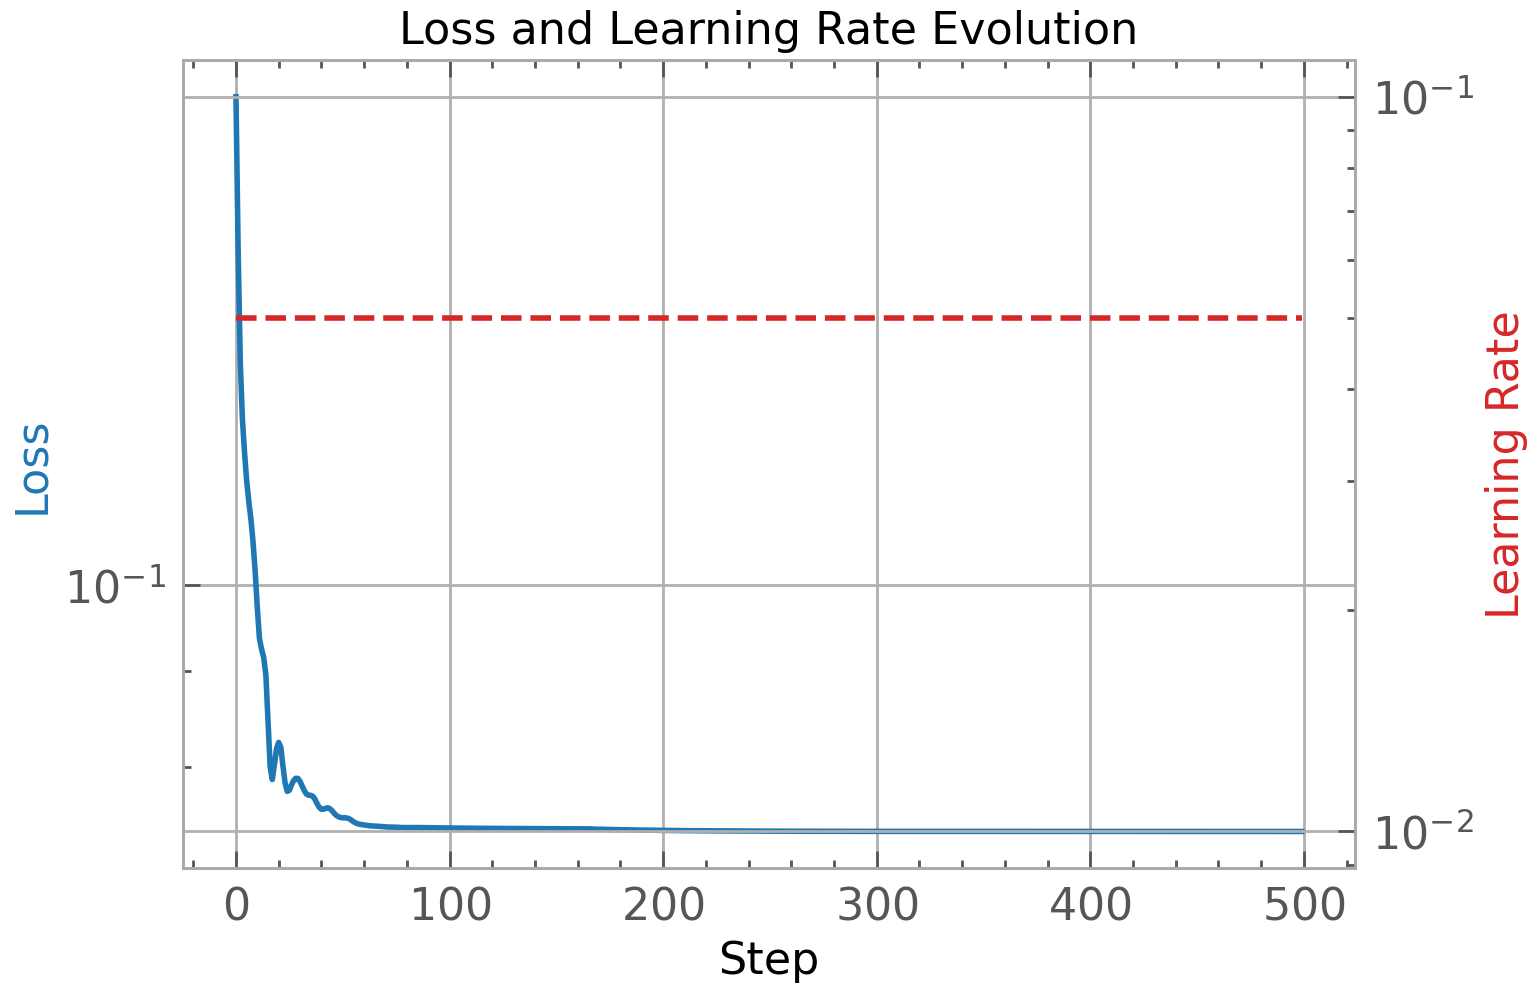

23:02:20 - WARNING - dingo.fitting - The following override keys are not used: {'velocity.v_rot'}
23:02:20 - INFO - dingo.fitting - Starting fitting stage 1/1: method=Adam
23:02:20 - INFO - dingo.fitting - Stage 1, Step 1, loss=0.24487, lr=0.05000xy_iters=(49, 49)


Fitting ID 21619
[{'image.C.dx': FitParamConfig(name='image.C.dx', value=0.0, lr=0.1, fit=True, 'image.C.dy': FitParamConfig(name='image.C.dy', value=0.0, lr=0.1, fit=True, 'image.C.forward_model': FitParamConfig(name='image.C.forward_model', value=<function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f171f98d3a0>, lr=0, fit=False}]


23:02:25 - INFO - dingo.fitting - Stage 1, Step 100, loss=0.1023, lr=0.05000xy_iters=(46, 6)
23:02:31 - INFO - dingo.fitting - Stage 1, Step 200, loss=0.10214, lr=0.05000xy_iters=(15, 49)
23:02:36 - INFO - dingo.fitting - Stage 1, Step 300, loss=0.10205, lr=0.05000xy_iters=(13, 49)
23:02:42 - INFO - dingo.fitting - Stage 1, Step 400, loss=0.10202, lr=0.05000xy_iters=(4, 49)
23:02:47 - INFO - dingo.fitting - Stage 1, Step 500, loss=0.102, lr=0.05000xy_iters=(11, 49)



[Velocity]
V_rot      = -290.59228515625
R_v        = 0.08624277263879776
x0_v       = 45.9703369140625
y0_v       = 30.0147705078125
theta_v    = -0.371384859085083
inc_v      = 0.9847410917282104

[Dispersion R]
dx         = 0.1268090456724167
dy         = 0.305337518453598
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f172cb0e8e0>

[Dispersion C]
dx         = -0.5107582211494446
dy         = -0.7101060748100281
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f171f98d3a0>


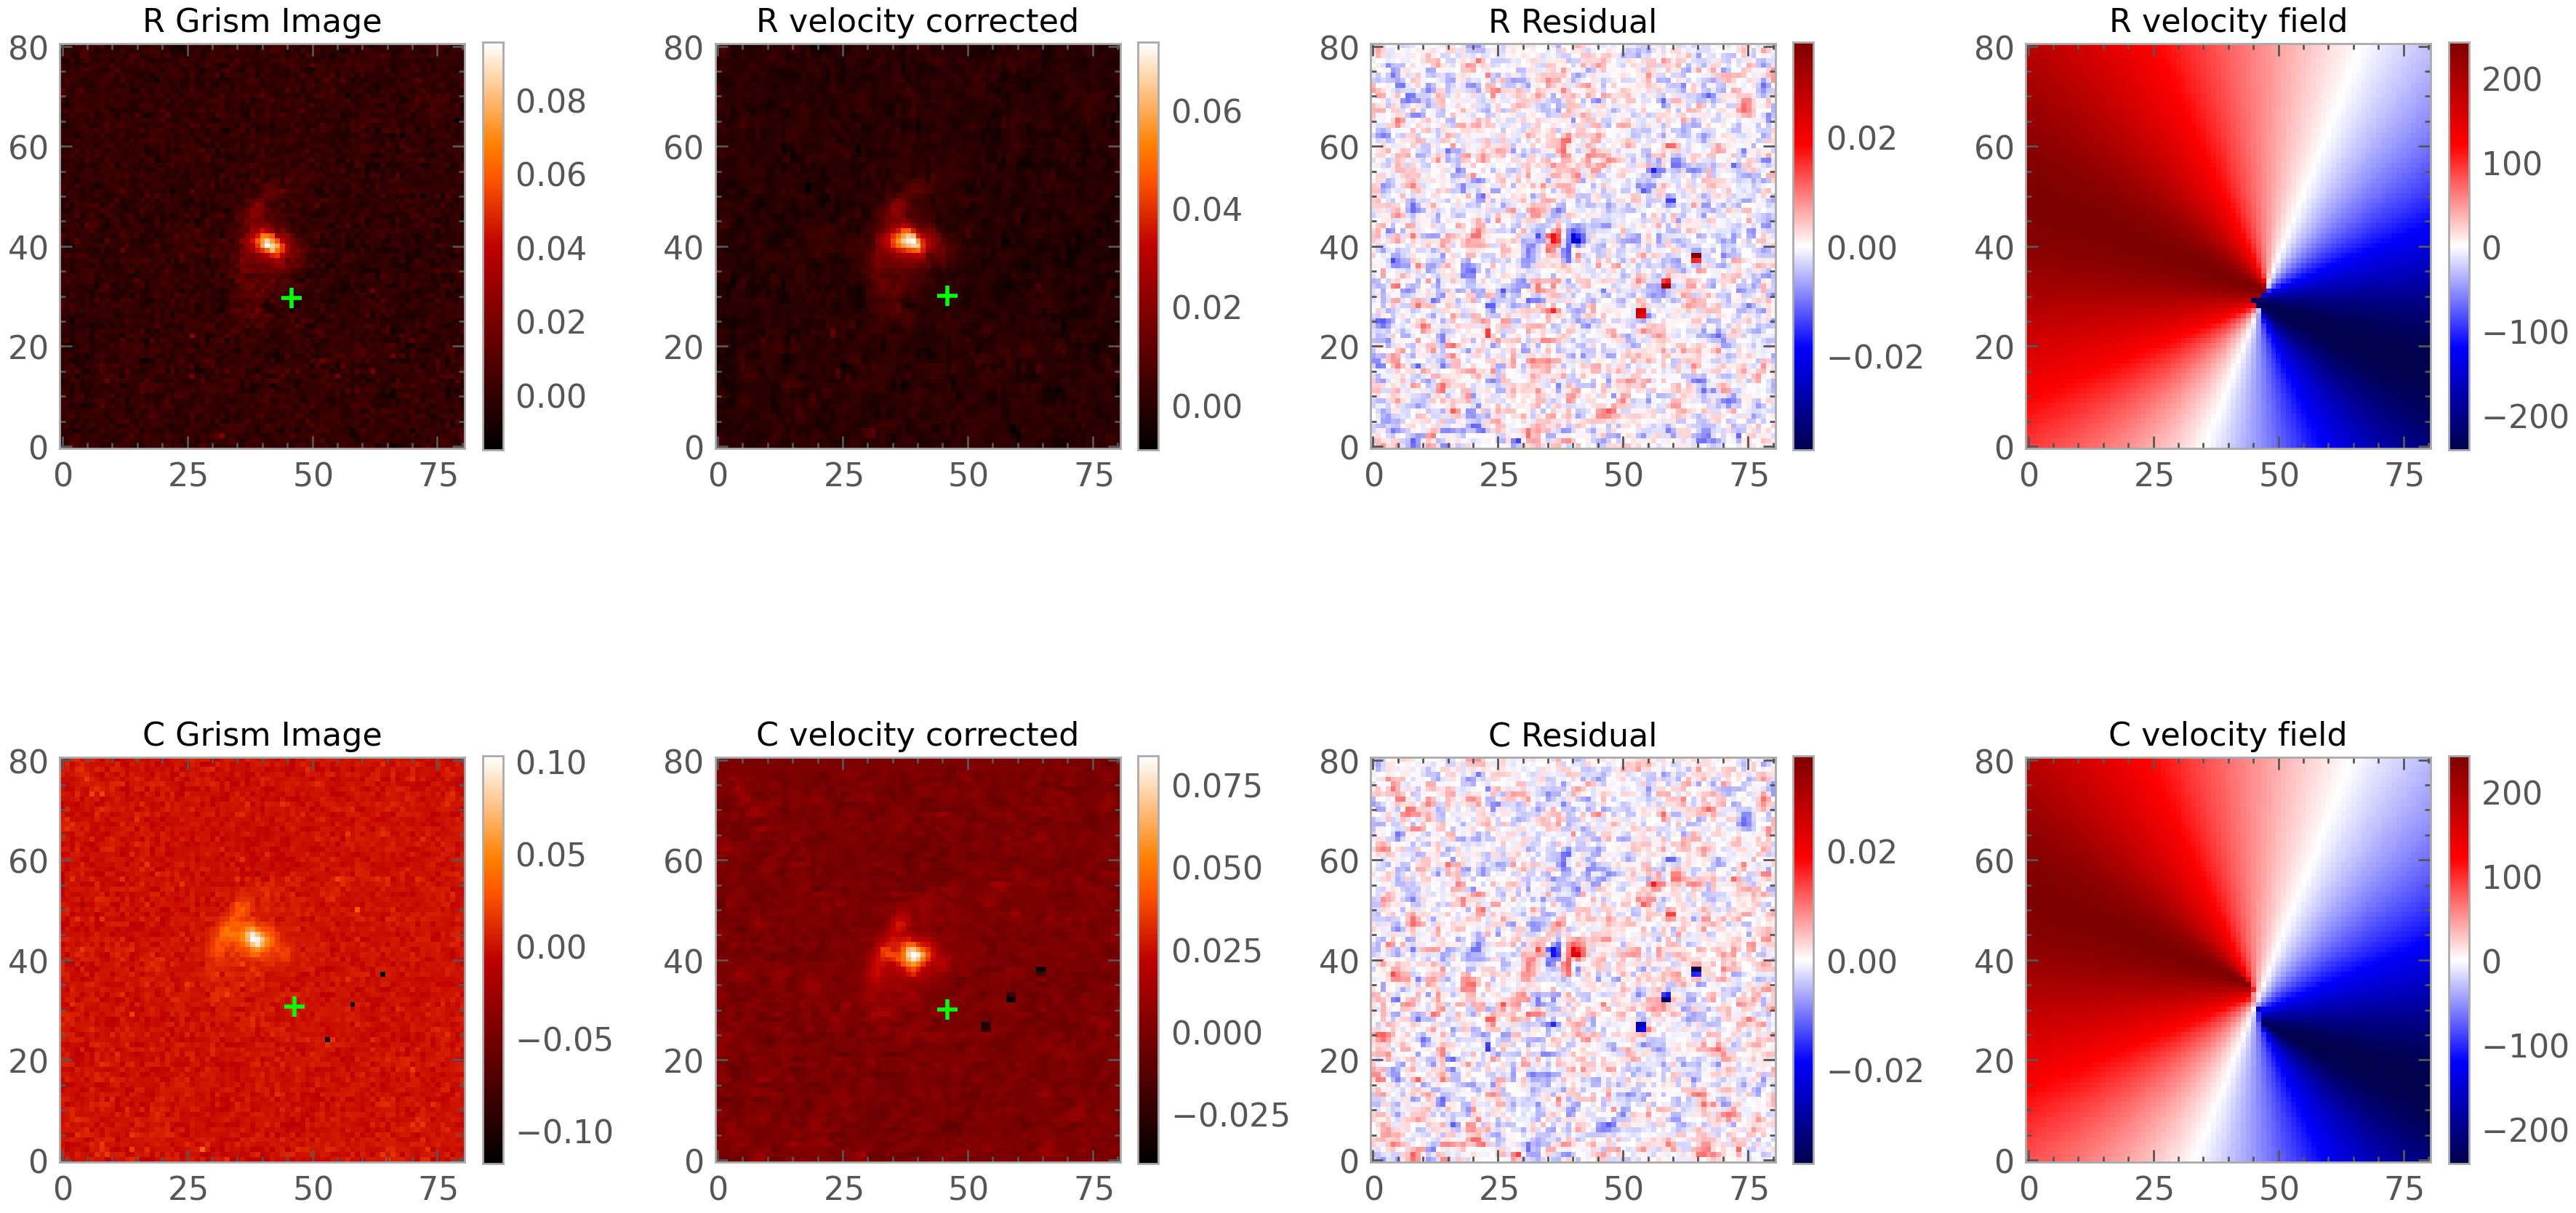

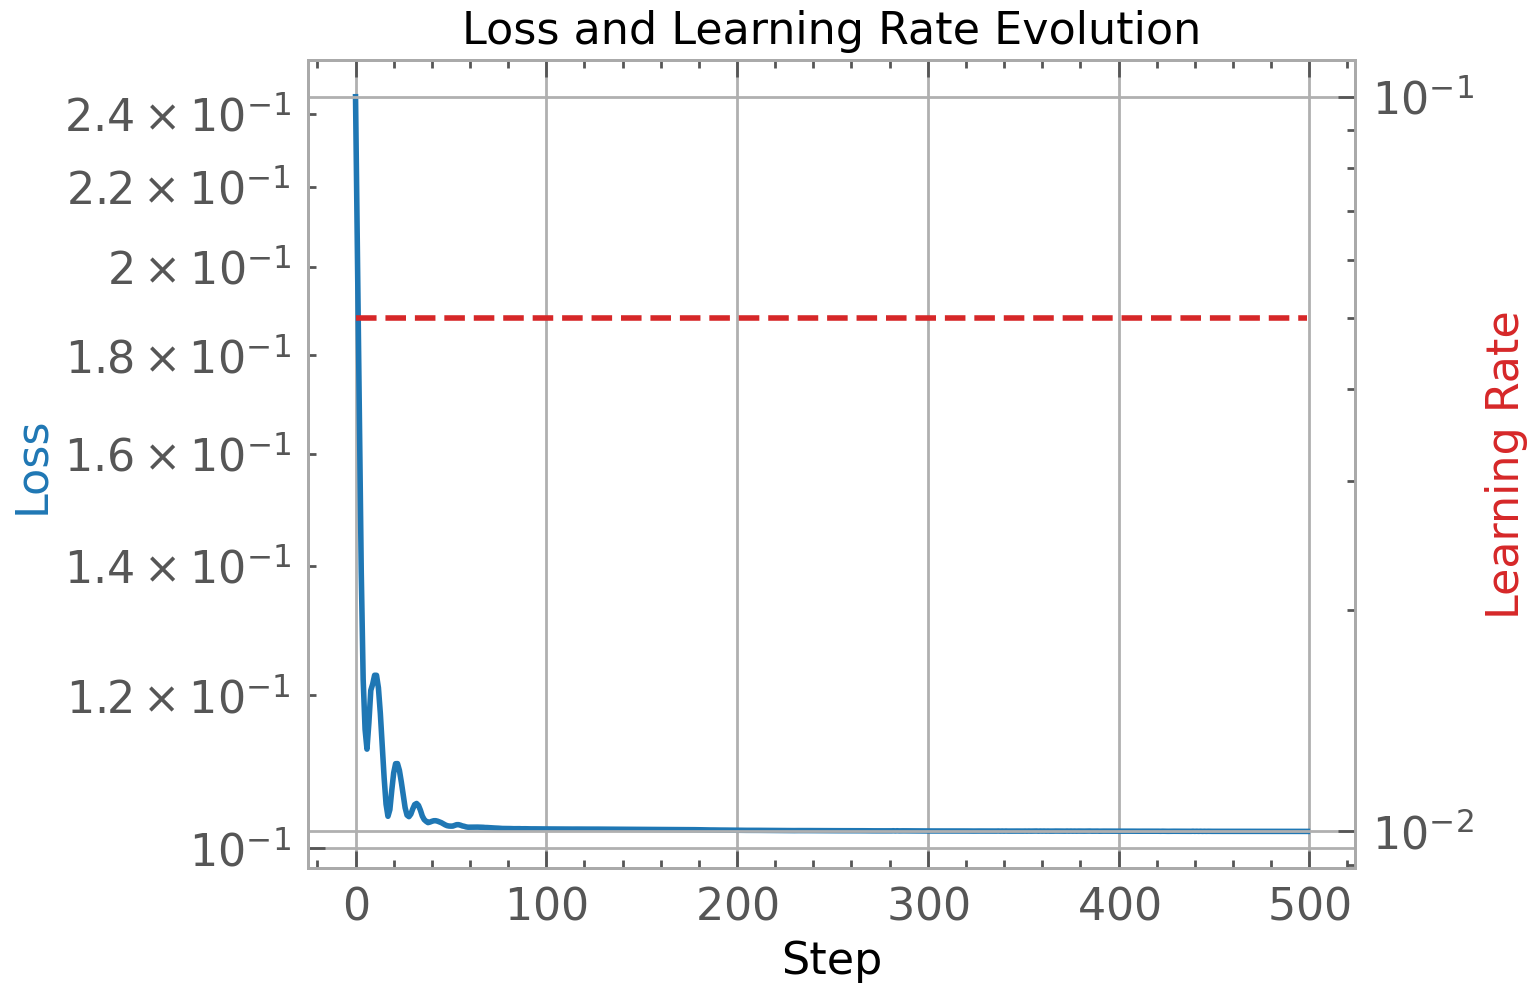

23:02:50 - WARNING - dingo.fitting - The following override keys are not used: {'velocity.v_rot'}
23:02:50 - INFO - dingo.fitting - Starting fitting stage 1/1: method=Adam
23:02:50 - INFO - dingo.fitting - Stage 1, Step 1, loss=0.12558, lr=0.05000xy_iters=(18, 35)


Fitting ID 21636
[{'image.C.dx': FitParamConfig(name='image.C.dx', value=0.0, lr=0.1, fit=True, 'image.C.dy': FitParamConfig(name='image.C.dy', value=0.0, lr=0.1, fit=True, 'image.C.forward_model': FitParamConfig(name='image.C.forward_model', value=<function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f17e01531a0>, lr=0, fit=False}]


23:02:52 - INFO - dingo.fitting - Stage 1, Step 100, loss=0.075969, lr=0.05000xy_iters=(5, 4)
23:02:53 - INFO - dingo.fitting - Stage 1, Step 200, loss=0.075872, lr=0.05000xy_iters=(3, 2)
23:02:54 - INFO - dingo.fitting - Stage 1, Step 300, loss=0.075806, lr=0.05000xy_iters=(3, 3)
23:02:55 - INFO - dingo.fitting - Stage 1, Step 400, loss=0.075739, lr=0.05000xy_iters=(5, 3)
23:02:56 - INFO - dingo.fitting - Stage 1, Step 500, loss=0.075666, lr=0.05000xy_iters=(4, 3)



[Velocity]
V_rot      = 316.1929016113281
R_v        = 3.0440733432769775
x0_v       = 41.55388259887695
y0_v       = 40.379215240478516
theta_v    = 1.4506416320800781
inc_v      = 0.8592135310173035

[Dispersion R]
dx         = 1.0043144226074219
dy         = 0.08294646441936493
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f17982e0e00>

[Dispersion C]
dx         = -0.02216077782213688
dy         = 1.188390851020813
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x7f17e01531a0>


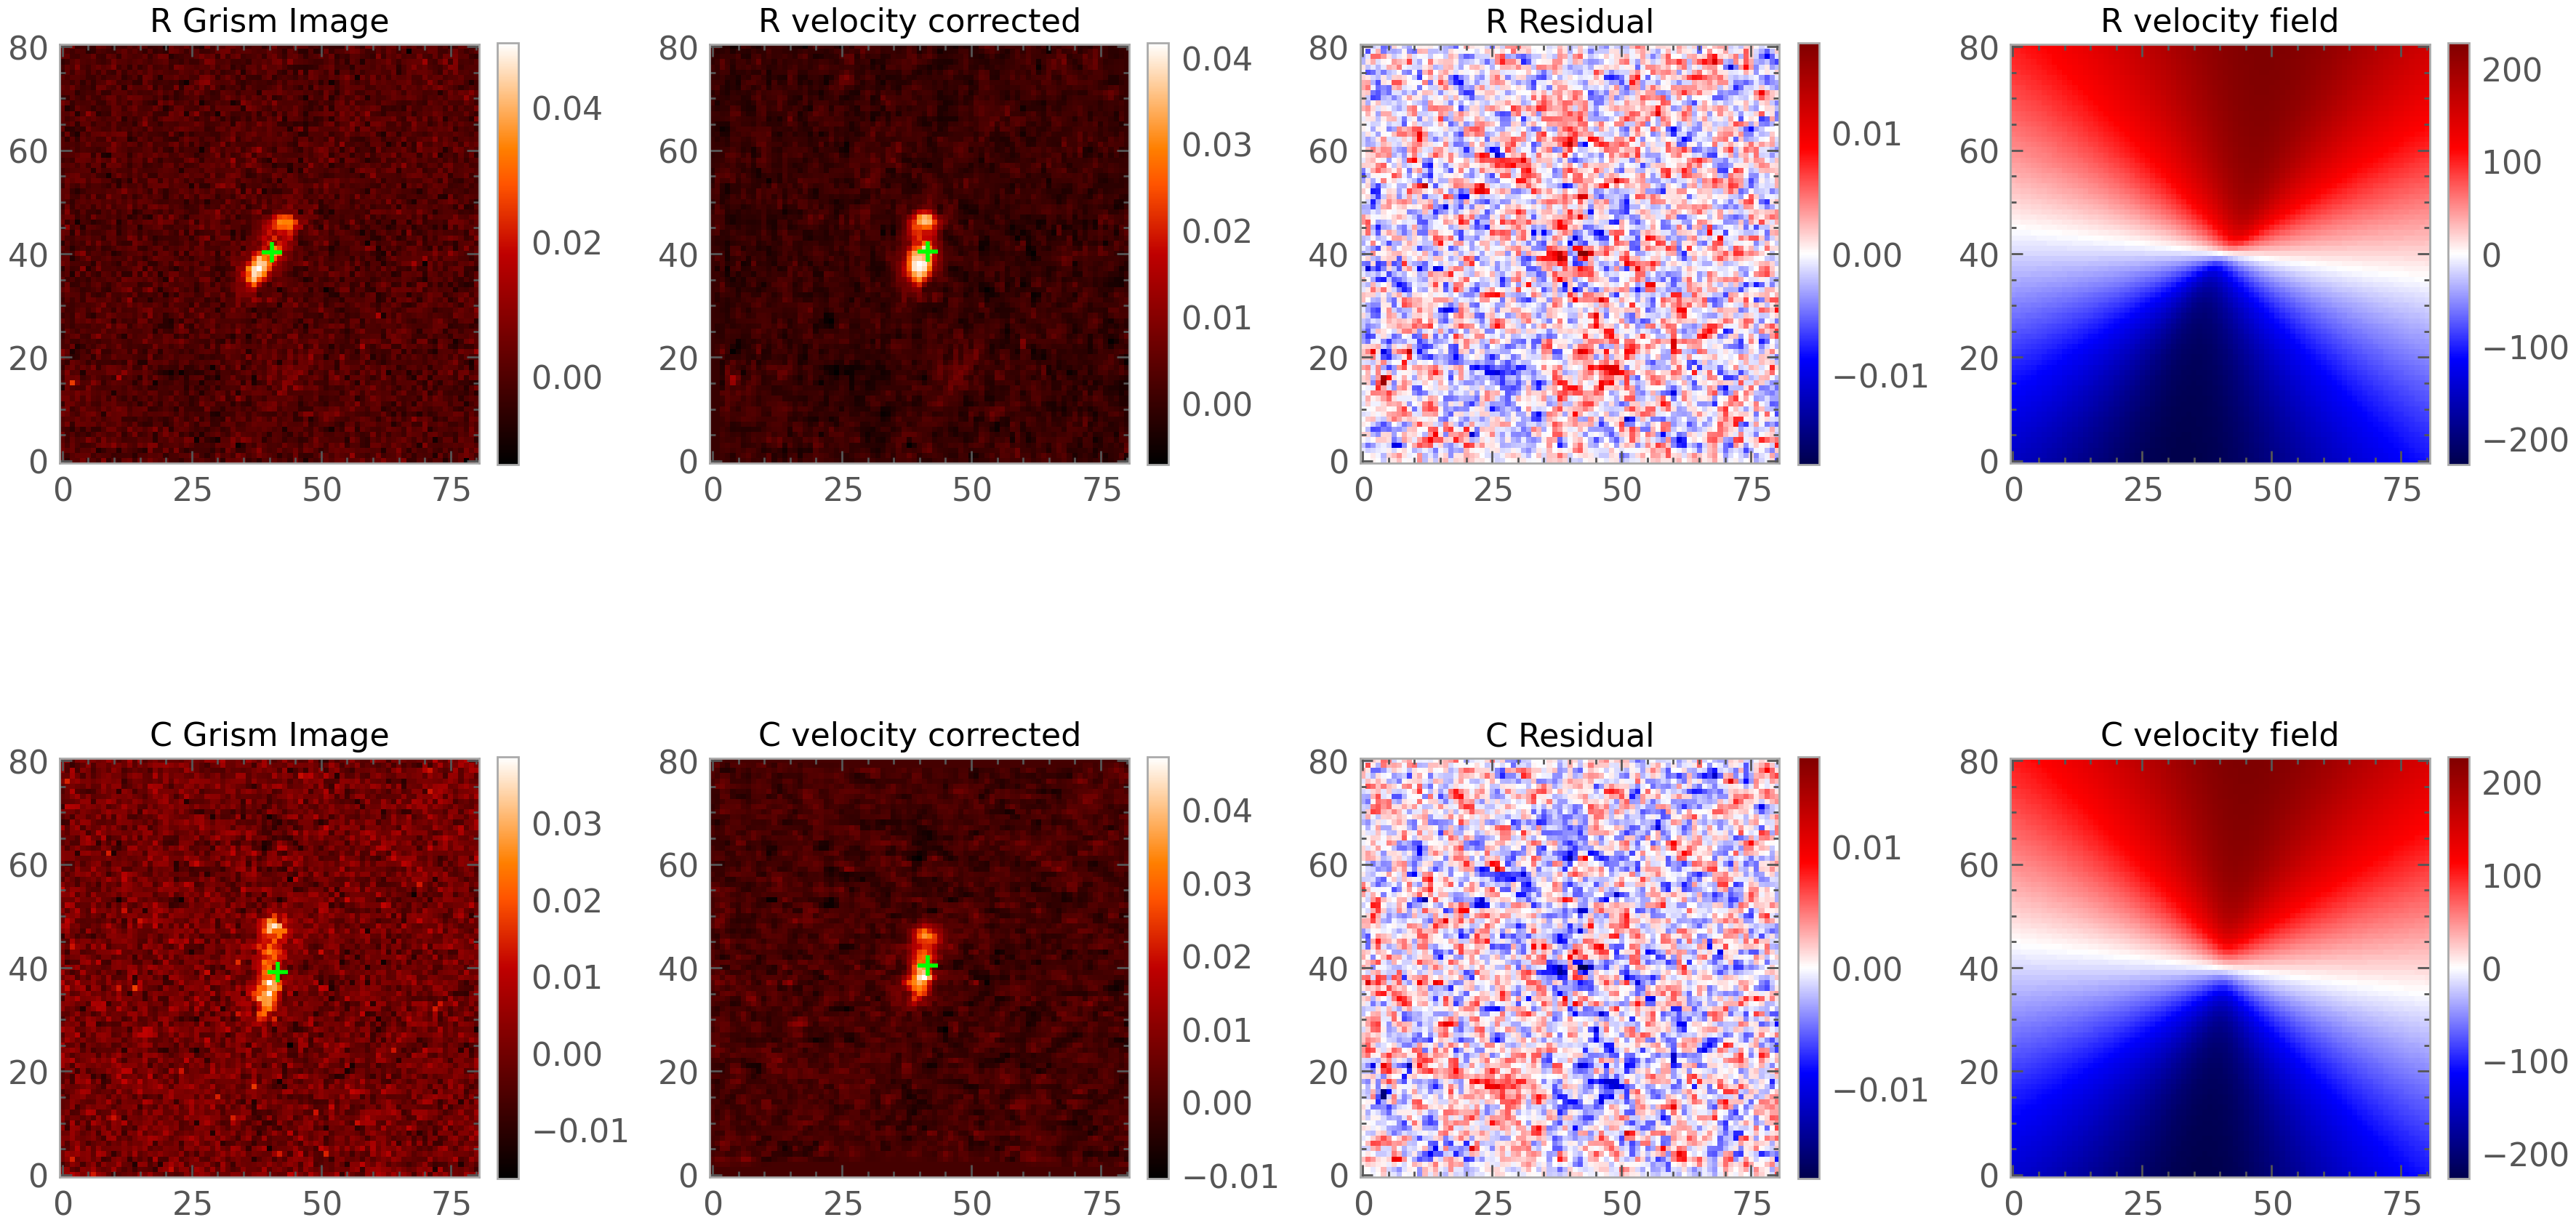

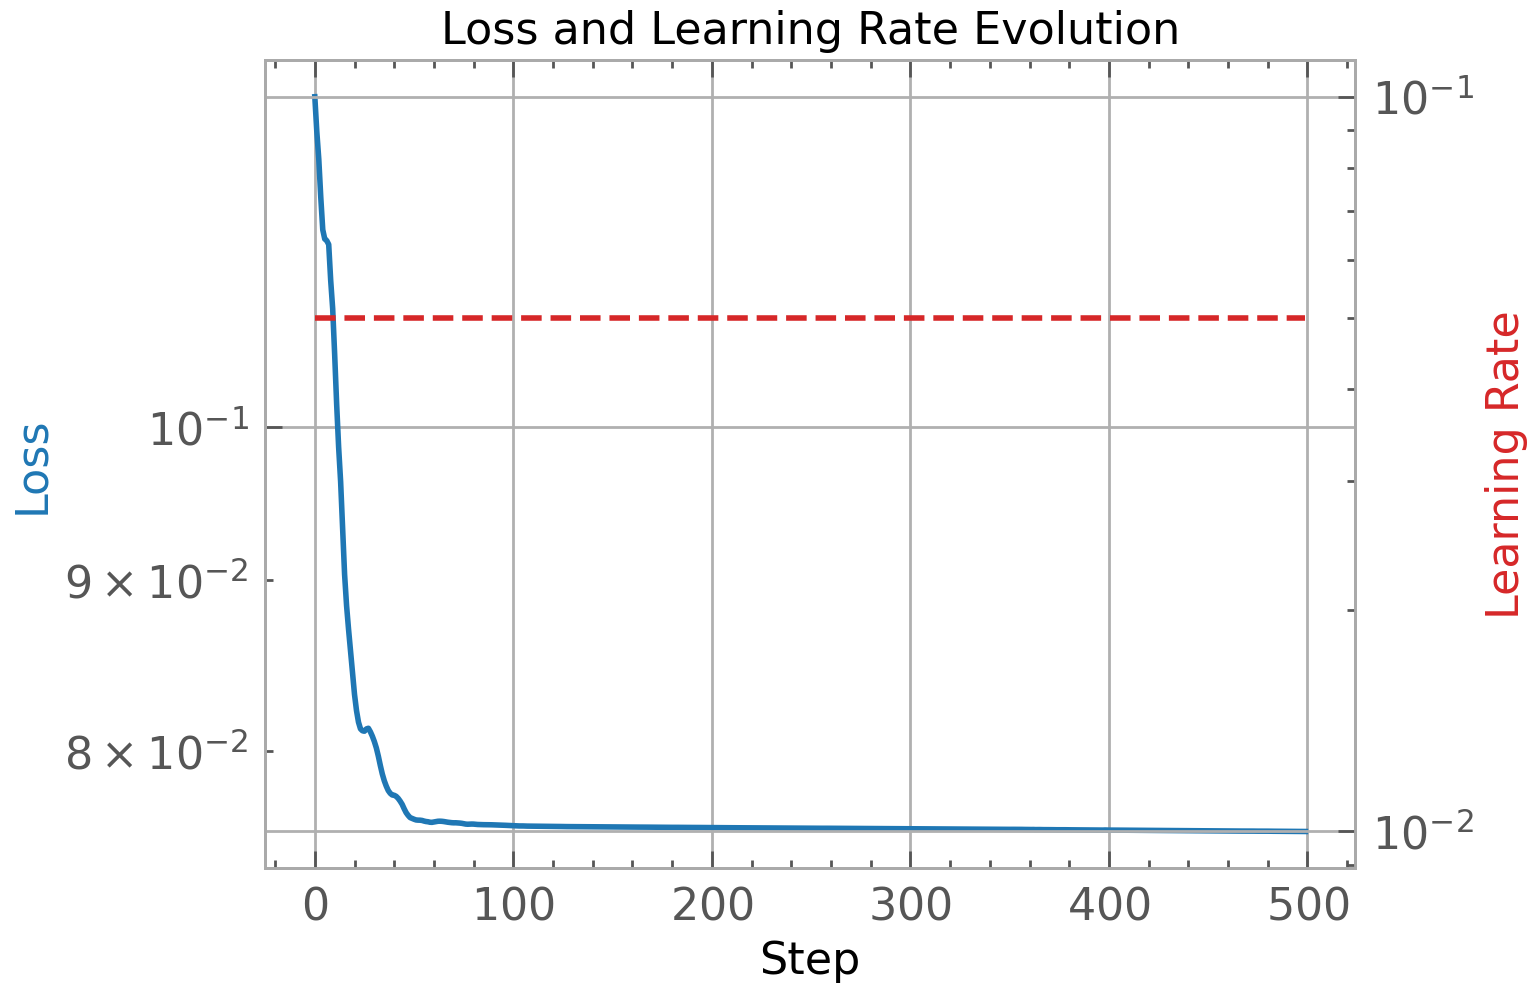

In [288]:
%autoreload 2
import yaml

# 要跑的 ID 列表
ids = [3700, 6170, 8910, 15665, 16887, 21619, 21636]

signs = {
    3700: -1,
    6170: 1,
    8910: 1,
    15665: -1,
    15977: -1,  # blacklist，不在这次循环里
    16887: 1,
    21619: -1,
    21636: 1,
}

# 用来存所有 ID 的结果
fit_results = {}


# ----------------
# 打印参数的小工具函数（保持你原来的写法）
# ----------------
def print_params(title, params):
    print(f'\n[{title}]')
    for name, param in params.items():
        if isinstance(param, (numbers.Number, np.number)):
            print(f'{name:10s} = {param:.4f}')
        else:
            print(f'{name:10s} = {param}')


# ----------------
# 循环拟合每个 ID
# ----------------
for ID in ids:
    print('='*60)
    print(f'Fitting ID {ID}')
    print('='*60)

    # ------------------ config file ------------------
    _, ra, dec, z, _ = paA_table_filtered[paA_table_filtered['ID']==ID][0]

    velocity_dict = {
        'model': 'arctan',
        'V_rot': 300.0*signs[ID],
        'R_v': 4 if ID==3700 else (1 if ID==21619 else 2),
        'x0_v': 44 if ID==21619 else 40,
        'y0_v': 30 if ID==21619 else 40,
        'theta_v': 0,
        'inc_v': 1.2
    }

    config = {
        'summary': {
            'name': f'ID{ID}',
            'ra': float(ra),
            'dec': float(dec),
            'z': float(z),
            'lambda_rest': 1.875,
            'filter': FILTER,
            'mode': 'kinematics',  # kinematics / image
            'r_fit': 40
        },

        'image': {
            'R': {
                'module': fits.getheader(f'resolved/F444W_ID{ID}/R.fits')['MODULE'],
                'path': [f'resolved/F444W_ID{ID}/R.fits', 0],
                'dx': 0,
                'dy': 0,
            },
            'C': {
                'module': fits.getheader(f'resolved/F444W_ID{ID}/C.fits')['MODULE'],
                'path': [f'resolved/F444W_ID{ID}/C.fits', 0],
                'dx': 0,
                'dy': 0,
            }
        },

        'velocity': velocity_dict,

        'fitting': [
            {
                # 'method': 'LBFGS',
                # 'maxiter': 100,
                'method': 'Adam',
                'maxiter': 500,
                'scheduler': 'StepLR',
                'default': {
                    'lr': 0.05,
                    # 'lr': 0.01,
                    'min': -1e10,
                    'max': 1e10,
                    'fit': True
                },
                'override': {
                    'image.R.dx, image.R.dy, image.C.dx, image.C.dy': {
                        # 'lr': 0.5,
                        'lr': 0.1 if ID not in [3700, 6170] else 0.2
                    },
                    'velocity.x0_v, velocity.y0_v': {
                        # 'lr': 0.5,
                        'lr': 0.1,
                    },
                    'velocity.R_v': {
                        'min': 0,
                    },
                    'velocity.theta_v': {
                        'fit': True,
                        # 'lr': 0.1
                    },
                    'velocity.inc_v': {
                        'min': 0,
                        'max': 1.57
                    },
                    'velocity.v_rot': {
                        'lr': 1
                    }
                }
            }
        ]
    }

    # 每个 ID 可以共用同一个文件名，也可以改成 f'config_{ID}.yaml'
    with open('config.yaml', 'w') as f:
        yaml.safe_dump(config, f, sort_keys=False)

    # ------------------ Fit ------------------
    kinematics_fitter = fitting.KinematicsFitter(config_path='config.yaml')
    all_losses, all_lrs = kinematics_fitter.fit_all()

    # ------------------ Evaluate fitted model ------------------
    image_R, image_C, vz_R, vz_C = kinematics_fitter.get_fitting_results()
    velocity_params, dispersion_params_R, dispersion_params_C = kinematics_fitter.get_params()
    true_grism_R, true_grism_C = kinematics_fitter.get_true_images()

    # 打印参数
    print_params('Velocity', velocity_params)
    print_params('Dispersion R', dispersion_params_R)
    print_params('Dispersion C', dispersion_params_C)

    # ------------------ Visualization ------------------
    fig, axs = plt.subplots(2, 4, figsize=(18, 10))

    plot.plot_kinematics_fitting_result(
        true_grism_R, image_R, vz_R, image_C, 'R', axs[0],
        velocity_params, dispersion_params_R
    )
    plot.plot_kinematics_fitting_result(
        true_grism_C, image_C, vz_C, image_R, 'C', axs[1],
        velocity_params, dispersion_params_C
    )

    plt.tight_layout()
    plt.savefig(f'fig/id{ID}_fit_summary.pdf')
    plt.show()

    # loss & lr 曲线（不强制保存，保持你原来的习惯）
    plot.plot_loss_and_lr(all_losses[0], all_lrs[0])

    # ------------------ 把结果存进总字典 ------------------
    fit_results[ID] = {
        'velocity_params': velocity_params,
        'dispersion_params_R': dispersion_params_R,
        'dispersion_params_C': dispersion_params_C,
        'all_losses': all_losses,
        'all_lrs': all_lrs,
        'true_grism_R': true_grism_R,
        'true_grism_C': true_grism_C,
        'image_R': image_R,
        'image_C': image_C,
        'vz_R': vz_R,
        'vz_C': vz_C,
    }

# 跑完以后，所有 ID 的变量都在 fit_results 这个大字典里：
# fit_results[3700]['velocity_params'] 这样的方式访问即可


In [17]:
# TODO: post-loss normalization

In [18]:
# TODO: velocity dispersion
# TODO: update interpolation method (jacobian? not point-wise stretch?)

# TODO: select arctangent model
# TODO: select fitter mode 

### single image plot

plot rotation curve

/home/yichenliu/anaconda3/envs/py312/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


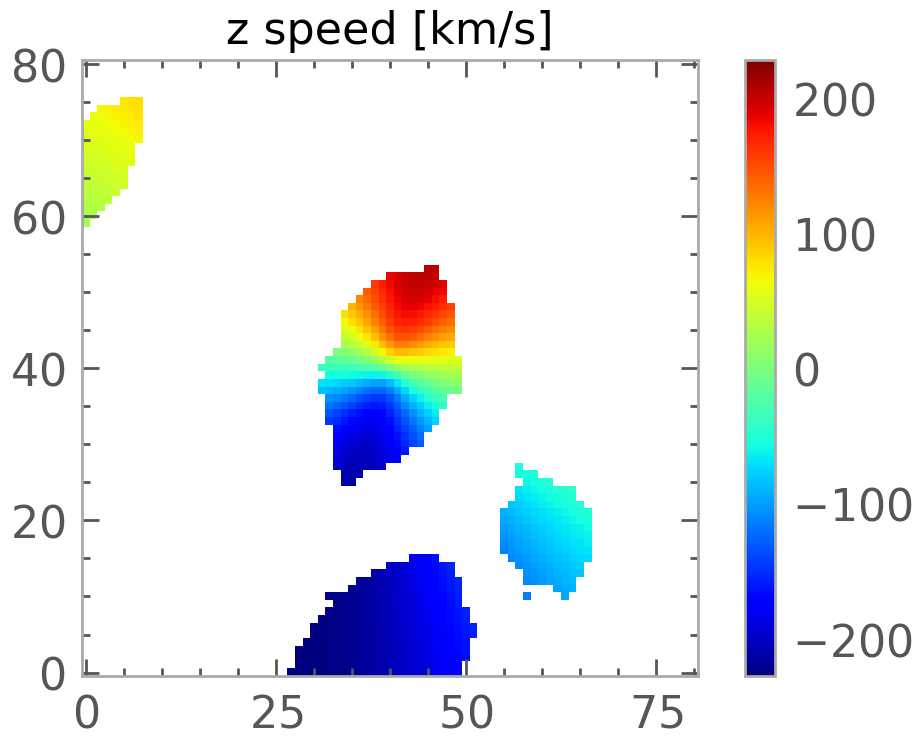

In [19]:
_, _, std = sigma_clipped_stats(coadd_image)
mask = coadd_image>std*5
nx, ny = coadd_image.shape

oversample = 1
y, x = torch.meshgrid(torch.arange(nx), torch.arange(ny))
V_rot = velocity_params['V_rot']
R_v = velocity_params['R_v']
# x0_v = velocity_params['x0_v']*oversample
# y0_v = velocity_params['y0_v']*oversample
# x_pix, y_pix = cutout_wcs.world_to_pixel(coord_gal)
x_pix, y_pix = 40, 40
x0_v = torch.tensor(x_pix, device=device)
y0_v = torch.tensor(y_pix, device=device)
theta_v = torch.tensor(velocity_params['theta_v'], device=device)
inc_v = torch.tensor(velocity_params['inc_v'], device=device)

vz = kinematics.arctangent_disk_velocity_model(x, y, V_rot, R_v, x0_v, y0_v, theta_v, inc_v)
vz_np = vz.detach().cpu().numpy()
vz_np[~mask] = np.nan
vmax = np.nanmax(np.abs(vz_np))

plt.imshow(vz_np, cmap='jet', vmin=-vmax, vmax=vmax)
plt.grid(None)
plt.colorbar()
plt.title('z speed [km/s]')
plt.savefig('fig/zspeed.pdf')
plt.show()

plot enclosed mass

In [20]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z = 1.123

# Angular diameter distance in Mpc
DA = cosmo.angular_diameter_distance(z)  # returns Quantity in Mpc

# Convert arcsec/pixel to kpc/pixel
arcsec_per_pixel = 0.063
kpc_per_arcsec = (DA.to(u.kpc) / u.rad).value * (1 / 206265)  # arcsec to rad
kpc_per_pixel = arcsec_per_pixel * kpc_per_arcsec

print(f'{kpc_per_pixel:.3f} kpc/pixel')


0.517 kpc/pixel


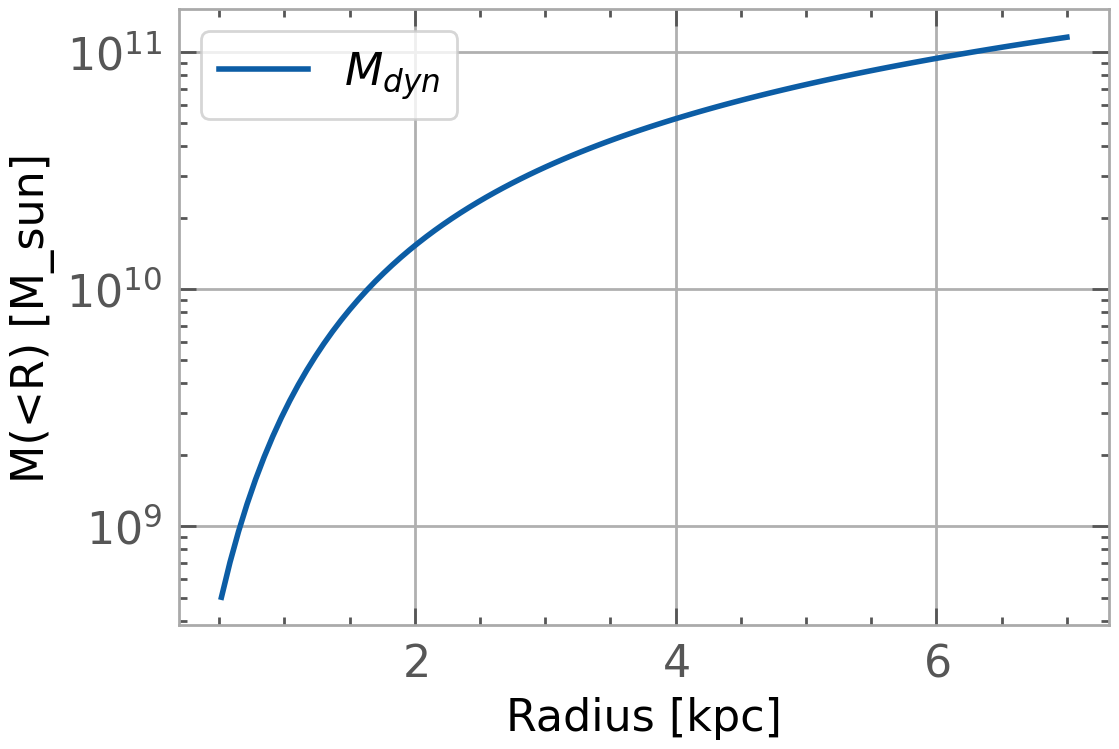

V_rot: 308.204895km/s
R_v: 1.512427kpc


In [21]:
def arctangent_dynamical_mass(r_kpc, V_rot=200., R_v=2., **kwargs):
    """
    Compute the dynamical mass M(<R) at radius R using the arctangent rotation curve.
    
    Parameters
    ----------
    r_kpc : torch.Tensor
        1D tensor of radius values in kpc.
    V_rot : float or torch.Tensor
        Maximum rotational velocity (km/s).
    R_v : float or torch.Tensor
        Turnover radius (kpc).
    
    Returns
    -------
    M_dyn : torch.Tensor
        Dynamical mass within radius R in units of solar masses (M_sun).
    """
    # Physical constant: G in units of d[kpc * (km/s)^2 / M_sun]
    G = 4.302e-6  # kpc * (km/s)^2 / M_sun

    # Arctangent rotation curve
    V = (2 / torch.pi) * V_rot * torch.atan(r_kpc / R_v)

    # M_dyn = V^2 * R / G
    M_dyn = (V**2 * r_kpc) / G

    return M_dyn

r_array = torch.linspace(kpc_per_pixel, 7, 100)  # 100 radii from 0.1 to 20 kpc
mass_profile = arctangent_dynamical_mass(
    r_array,
    V_rot=V_rot,
    R_v=R_v*kpc_per_pixel
)

# Plotting (optional)
plt.plot(r_array.detach().cpu().numpy(), mass_profile.detach().cpu().numpy(), label=r'$M_{dyn}$')
plt.xlabel('Radius [kpc]')
plt.ylabel('M(<R) [M_sun]')
plt.yscale('log')
plt.legend(frameon=True)
plt.grid(True)
plt.savefig('fig/dynamic_mass.pdf')
plt.show()

print(f'V_rot: {V_rot:5f}km/s')
print(f'R_v: {R_v*kpc_per_pixel:5f}kpc')


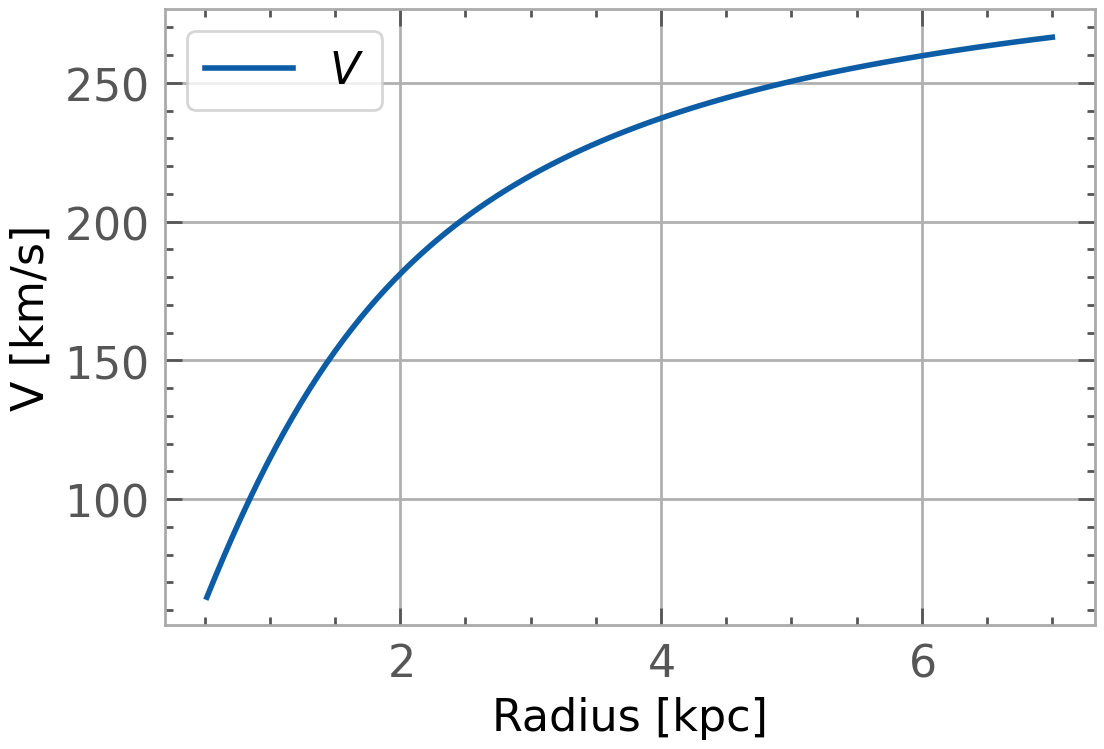

V_rot: 308.204895km/s
R_v: 1.512427kpc


In [22]:
def arctangent_dynamical_mass(r_kpc, V_rot=200., R_v=2., **kwargs):
    """
    Compute the dynamical mass M(<R) at radius R using the arctangent rotation curve.
    
    Parameters
    ----------
    r_kpc : torch.Tensor
        1D tensor of radius values in kpc.
    V_rot : float or torch.Tensor
        Maximum rotational velocity (km/s).
    R_v : float or torch.Tensor
        Turnover radius (kpc).
    
    Returns
    -------
    M_dyn : torch.Tensor
        Dynamical mass within radius R in units of solar masses (M_sun).
    """
    # Physical constant: G in units of d[kpc * (km/s)^2 / M_sun]
    G = 4.302e-6  # kpc * (km/s)^2 / M_sun

    # Arctangent rotation curve
    V = (2 / torch.pi) * V_rot * torch.atan(r_kpc / R_v)

    # M_dyn = V^2 * R / G
    # M_dyn = (V**2 * r_kpc) / G

    return V

r_array = torch.linspace(kpc_per_pixel, 7, 100)  # 100 radii from 0.1 to 20 kpc
mass_profile = arctangent_dynamical_mass(
    r_array,
    V_rot=V_rot,
    R_v=R_v*kpc_per_pixel
)

# Plotting (optional)
plt.plot(r_array.detach().cpu().numpy(), mass_profile.detach().cpu().numpy(), label=r'$V$')
plt.xlabel('Radius [kpc]')
plt.ylabel('V [km/s]')
# plt.yscale('log')
plt.legend(frameon=True)
plt.grid(True)
plt.savefig('fig/velociycurve.pdf')
plt.show()

print(f'V_rot: {V_rot:5f}km/s')
print(f'R_v: {R_v*kpc_per_pixel:5f}kpc')


overplot emission line map and velocity field

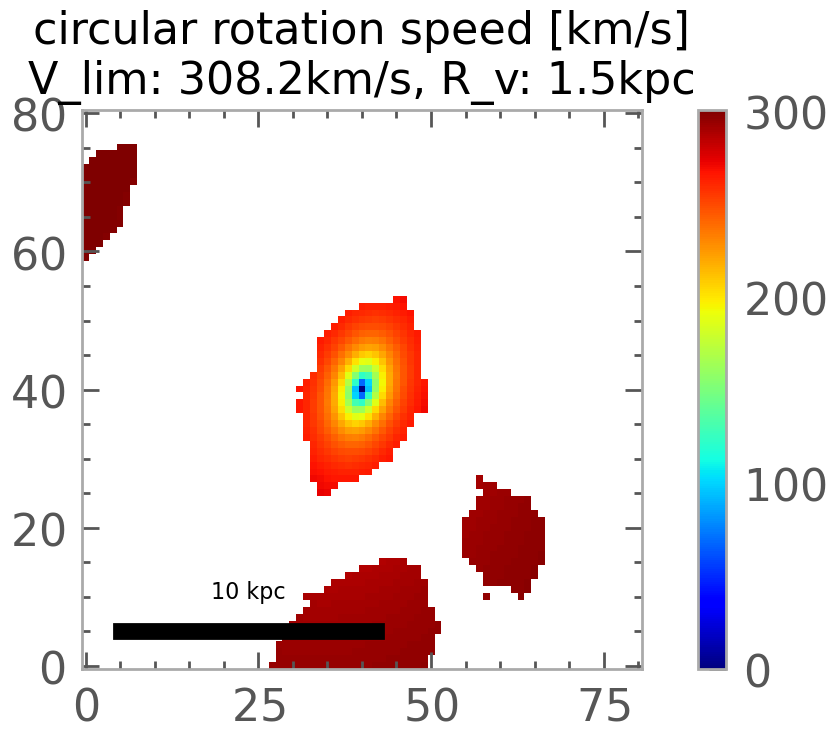

In [23]:
import numpy as np

def arctangent_disk_rotation_speed(x, y, V_rot=200., R_v=2., x0_v=0., y0_v=0., theta_v=0., inc_v=0., **kwargs):
    """
    Return the intrinsic circular velocity field (not LOS-projected).
    """
    # Shift to center
    dx = x - x0_v
    dy = y - y0_v

    # Rotate coordinates
    cos_t, sin_t = torch.cos(theta_v), torch.sin(theta_v)
    x_p = cos_t * dx + sin_t * dy
    y_p = -sin_t * dx + cos_t * dy

    # Deproject radius
    r = torch.sqrt(x_p**2 + (y_p / torch.cos(inc_v))**2 + 1e-8)

    # Arctangent rotation curve
    V_circ = (2 / torch.pi) * V_rot * torch.atan(r / R_v)

    return V_circ

_, _, std = sigma_clipped_stats(coadd_image)
mask = coadd_image>std*5
nx, ny = coadd_image.shape

oversample = 1
y, x = torch.meshgrid(torch.arange(nx), torch.arange(ny))
V_rot = velocity_params['V_rot']
R_v = velocity_params['R_v']
# x0_v = velocity_params['x0_v']*oversample
# y0_v = velocity_params['y0_v']*oversample
# x_pix, y_pix = cutout_wcs.world_to_pixel(coord_gal)
x_pix, y_pix = 40, 40
x0_v = torch.tensor(x_pix, device=device)
y0_v = torch.tensor(y_pix, device=device)
theta_v = torch.tensor(velocity_params['theta_v'], device=device)
inc_v = torch.tensor(velocity_params['inc_v'], device=device)

vcirc = arctangent_disk_rotation_speed(x, y, V_rot, R_v, x0_v, y0_v, theta_v, inc_v)
vcirc_np = vcirc
vcirc_np[~mask] = np.nan
vmax = np.nanmax(np.abs(vcirc_np))

# annotate

ang_diam_dist = cosmo.angular_diameter_distance(z).to('kpc')
kpc_per_arcsec = ang_diam_dist.value / 206265
pixel_scale = 0.031  # arcsec/pixel
pixels_per_kpc = 1 / (kpc_per_arcsec * pixel_scale)
bar_length_pix = int(10 * pixels_per_kpc)

y_bar = coadd_image.shape[0] * 0.05
x_bar_start = coadd_image.shape[1] * 0.05
rect = patches.Rectangle((x_bar_start, y_bar), bar_length_pix, 2, color='black')
plt.gca().add_patch(rect)
plt.text(x_bar_start + bar_length_pix / 2, y_bar + 5, '10 kpc',
		color='black', ha='center', va='bottom', fontsize=8)

plt.imshow(vcirc_np, cmap='jet', vmin=0, vmax=vmax)
plt.grid(None)
plt.colorbar()
plt.title(f'circular rotation speed [km/s]\nV_lim: {V_rot:.1f}km/s, R_v: {R_v*kpc_per_pixel:.1f}kpc')
plt.tight_layout()
plt.savefig('fig/circspeed.pdf')
plt.show()



### multiple image plot

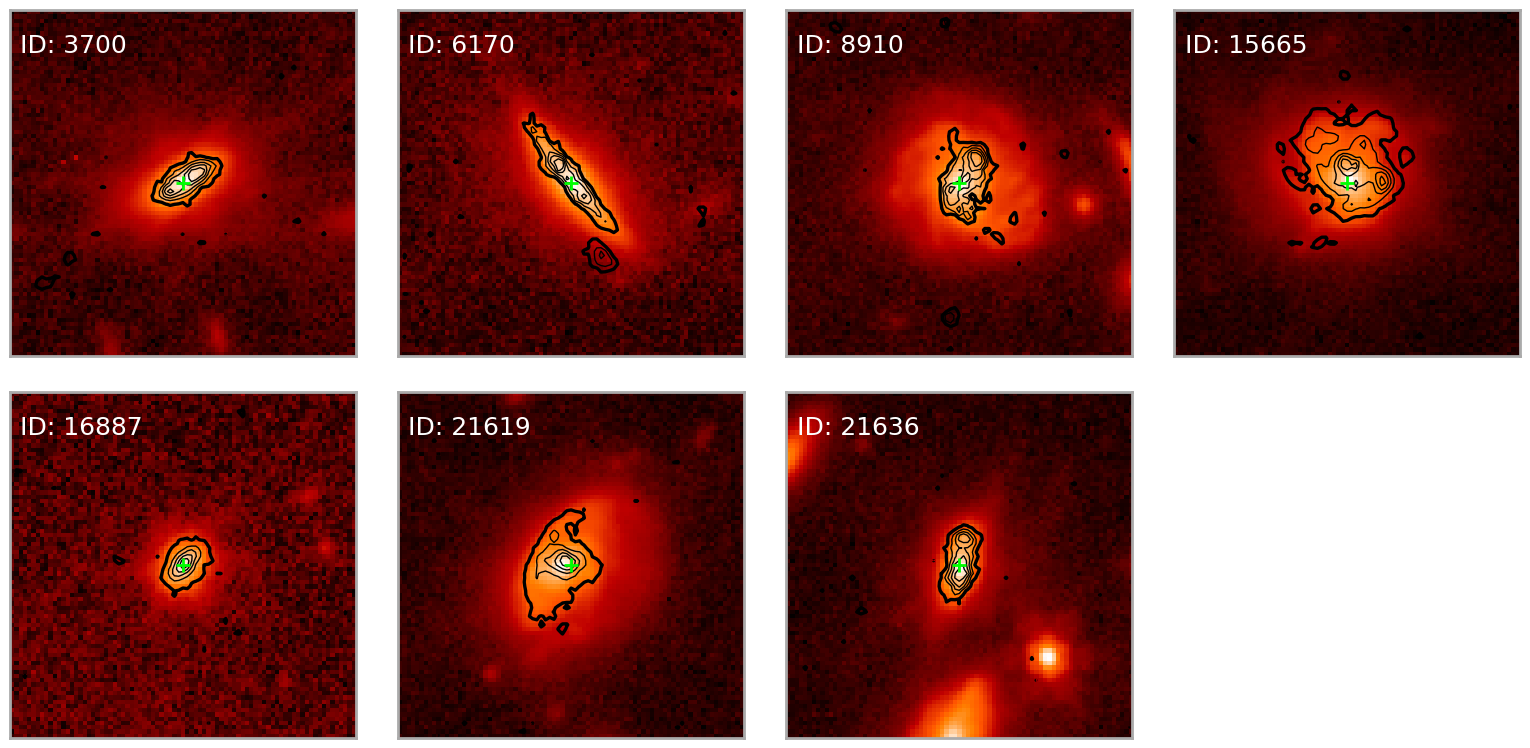

In [289]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage
from matplotlib.lines import Line2D


def plot_emline_map_ax(result,
                       direct_image,
                       ax,
                       ID=None,
                       center_emission=None,
                       center_direct=None,
                       contour_color='black',
                       emline_boost=1.0,
                       mask=None,
                       smoothing_sigma=0.0,
                       ncontour=9):
    """
    在给定 ax 上画 direct_image + emission contours，
    并支持在左上角标注 ID。
    """

    velocity_params = result['velocity_params']
    image_R = result['image_R']
    image_C = result['image_C']

    # 发射图像：R 和 C 的平均
    emission_image = np.average([image_R, image_C], axis=0)

    # 发射中心：给定为 [40,40] 或传入
    if center_emission is None:
        center_emission = [40, 40]

    # direct 图中心
    if center_direct is None:
        center_direct = center_emission

    # --- shift direct image 马上对齐 ---
    shift_y = center_emission[1] - center_direct[1]
    shift_x = center_emission[0] - center_direct[0]

    direct_image_shifted = scipy.ndimage.shift(
        direct_image,
        shift=(shift_y, shift_x),
        order=1,
        mode='nearest'
    )

    # --- 准备发射图 ---
    if mask is not None:
        emission_image_masked = np.where(mask, emission_image, np.nan)
    else:
        emission_image_masked = emission_image

    emission_image_boosted = emission_image_masked * emline_boost
    emission_image_smooth = scipy.ndimage.gaussian_filter(
        emission_image_boosted, sigma=smoothing_sigma
    )

    # # contour levels
    # em_max = np.nanmax(emission_image_smooth)
    # em_levels = np.linspace(0.1*em_max, em_max, ncontour)

    # --- 绘制背景 direct 图像 ---
    im = asinhstretch(direct_image_shifted)
    ax.imshow(im, cmap='gist_heat', origin='lower')

    # --- 等高线 ---
    # 计算 sigma
    sigma_val = sigma_clipped_stats(emission_image_smooth)[2]

    # 3σ
    level_3sigma = 3.0 * sigma_val

    # 最大值
    em_max = np.nanmax(emission_image_smooth)

    # 防止 3σ > max
    if level_3sigma >= em_max:
        # 若图太弱，仅画一条 max contour
        em_levels = [em_max]
    else:
        # 生成 ncontour 条，从 3σ 到 max 的线性等高线
        em_levels = np.linspace(level_3sigma, em_max, ncontour)

    # --- 多条等高线 ---
    ax.contour(
        emission_image_smooth,
        levels=em_levels,
        colors=contour_color,
        linewidths=0.5
    )

    # --- 最外层 (max) 加粗 ---
    ax.contour(
        emission_image_smooth,
        levels=[level_3sigma],
        colors=contour_color,
        linewidths=1.2
    )
    
    # --- 发射中心标记 ---
    ax.plot(
        center_emission[0], center_emission[1],
        marker='+', color='lime', markersize=5, markeredgewidth=1
    )

    # --- 不显示坐标轴标签和刻度 ---
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])

    # --- 隐藏 legend ---
    #（不建立 legend，不添加 proxy）

    # --- 左上角标注 ID ---
    if ID is not None:
        ax.text(0.03, 0.93, f'ID: {ID}',
                transform=ax.transAxes,
                fontsize=9, ha='left', va='top', c='white')

    # 保持等比例
    ax.set_aspect('equal')

# ------
ncols = 4
nrows = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows))
axes = axes.ravel()

for i, ID in enumerate(ids):
    ax = axes[i]

    direct_image = fits.getdata(f'resolved/F444W_ID{ID}/image.fits')

    plot_emline_map_ax(
        fit_results[ID],
        direct_image=direct_image,
        ax=ax,
        ID=ID,                 # 左上角标注 ID
        center_emission=[40,40],
        ncontour=6
    )

# 删除多余 subplot（第 8 个）
for j in range(len(ids), nrows*ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('fig/emline_map_grid.pdf')
plt.show()


/tmp/ipykernel_550825/359652068.py:268: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


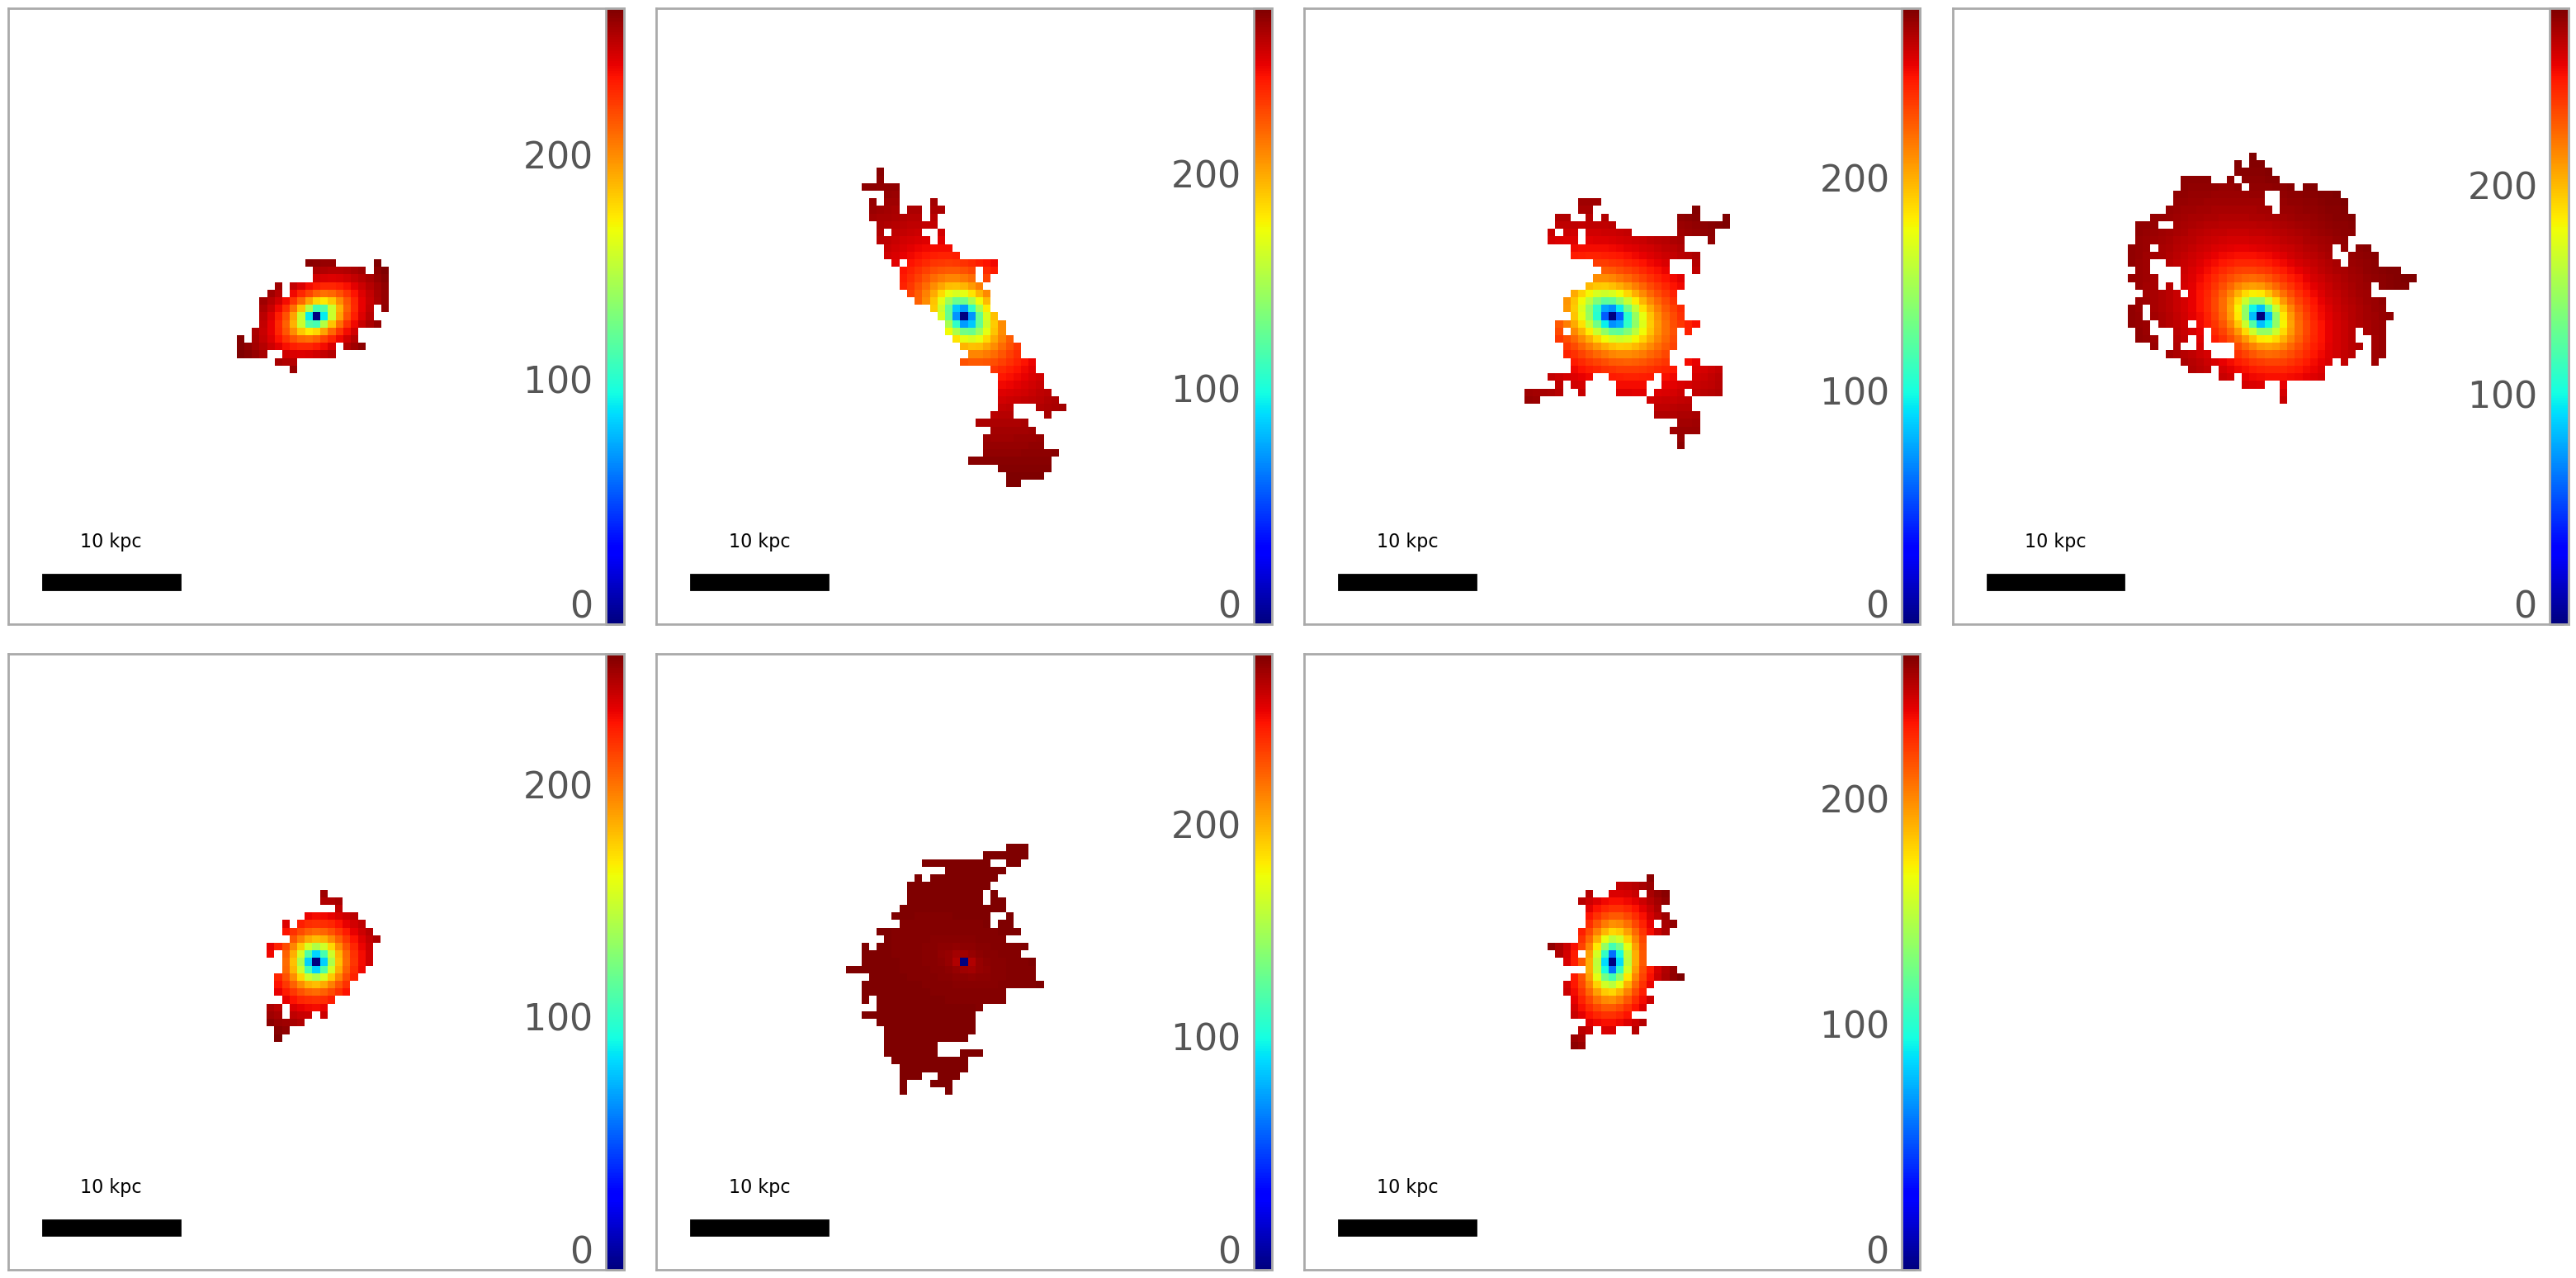

In [290]:
import torch
import matplotlib.pyplot as plt
from matplotlib import patches
from astropy.stats import sigma_clipped_stats
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import numpy as np
import scipy.ndimage as ndi


def connected_mask_from_center(mask, center_xy):
    """
    只保留和给定中心像素连通的那一块 mask。

    Parameters
    ----------
    mask : 2D bool array
        原始掩膜。
    center_xy : (x, y) tuple
        中心坐标（注意是 x, y 像素坐标）。

    Returns
    -------
    new_mask : 2D bool array
        只保留中心连通区域后的掩膜。
    """
    if mask.dtype != bool:
        mask = mask.astype(bool)

    labeled, ncomp = ndi.label(mask)
    if ncomp == 0:
        return mask

    cx, cy = center_xy
    cx = int(round(cx))
    cy = int(round(cy))

    ny, nx = mask.shape
    if cy < 0 or cy >= ny or cx < 0 or cx >= nx:
        # 中心出界：退化为选最大连通区域
        sizes = ndi.sum(mask, labeled, index=np.arange(1, ncomp+1))
        label_keep = np.argmax(sizes) + 1
    else:
        label_at_center = labeled[cy, cx]
        if label_at_center == 0:
            # 中心不在任何连通块上，退化为选最大连通区域
            sizes = ndi.sum(mask, labeled, index=np.arange(1, ncomp+1))
            label_keep = np.argmax(sizes) + 1
        else:
            label_keep = label_at_center

    new_mask = (labeled == label_keep)
    return new_mask


def plot_circular_speed_ax(result,
                           coadd_image,
                           z,
                           cosmo,
                           ax,
                           pixel_scale=0.031,
                           center_pix=(40, 40),
                           oversample=1,
                           cmap='jet',
                           device=None,
                           ID=None):
    """
    使用 fit_results[ID] 中的速度参数，在给定 ax 上绘制 intrinsic circular speed map。
    不创建 figure，不保存，不 show。

    Parameters
    ----------
    result : dict
        fit_results[ID] 对应字典，需要包含 'velocity_params'。
    coadd_image : 2D array
        用于计算 mask 的直射图像。
    z : float
        目标红移，用于换算 kpc per arcsec。
    cosmo : astropy.cosmology instance
        宇宙学对象，用于算角径距。
    ax : matplotlib.axes.Axes
        要绘图的坐标轴。
    pixel_scale : float
        角尺度 [arcsec / pixel]。
    center_pix : (x, y)
        圆盘中心在像素坐标中的位置，用于：
        - 速度场中心
        - mask 连通区域中心。
    oversample : float
        目前未使用，预留接口。
    cmap : str
        imshow 的 colormap。
    device : torch.device or None
        若为 None，则使用 'cpu'。
    ID : int or None
        若不为 None，在左上角写 "ID: xxx".
    """

    if device is None:
        device = torch.device('cpu')

    velocity_params = result['velocity_params']
    V_rot = velocity_params['V_rot']
    R_v = velocity_params['R_v']
    theta_v = velocity_params['theta_v']
    inc_v = velocity_params['inc_v']

    # ----------------- mask（带连续性修正） -----------------
    _, _, std = sigma_clipped_stats(coadd_image)
    raw_mask = coadd_image > std*1

    # 只保留和中心像素连通的区域
    mask = connected_mask_from_center(raw_mask, center_pix)
    # mask = raw_mask

    ny, nx = coadd_image.shape

    # ----------------- 构建网格 & 速度场 -----------------
    # 注意：torch.meshgrid 使用 indexing='ij'
    y, x = torch.meshgrid(
        torch.arange(ny, device=device),
        torch.arange(nx, device=device),
        indexing='ij'
    )

    x_pix, y_pix = center_pix
    x0_v = torch.tensor(x_pix, device=device, dtype=torch.float32)
    y0_v = torch.tensor(y_pix, device=device, dtype=torch.float32)
    theta_v_t = torch.tensor(theta_v, device=device, dtype=torch.float32)
    inc_v_t = torch.tensor(inc_v, device=device, dtype=torch.float32)

    V_rot_t = torch.tensor(V_rot, device=device, dtype=torch.float32)
    R_v_t = torch.tensor(R_v, device=device, dtype=torch.float32)

    vcirc = arctangent_disk_rotation_speed(
        x, y,
        V_rot=np.abs(V_rot_t),
        R_v=R_v_t,
        x0_v=x0_v,
        y0_v=y0_v,
        theta_v=theta_v_t,
        inc_v=inc_v_t
    )

    # 转成 numpy
    vcirc_np = vcirc.detach().cpu().numpy()
    vcirc_np[~mask] = np.nan
    vmax = np.nanmax(np.abs(vcirc_np))

    # ----------------- 物理标尺：10 kpc 标尺 -----------------
    ang_diam_dist = cosmo.angular_diameter_distance(z).to('kpc')
    kpc_per_arcsec = ang_diam_dist.value / 206265.0
    pixels_per_kpc = 1.0 / (kpc_per_arcsec * pixel_scale)
    kpc_per_pixel = 1.0 / pixels_per_kpc
    bar_length_pix = int(10.0 * pixels_per_kpc)

    # ----------------- 在 ax 上画图 -----------------
    im = ax.imshow(vcirc_np, cmap=cmap, vmin=0, vmax=vmax, origin='lower')
    ax.grid(False)

    # 10 kpc 标尺条
    y_bar = ny * 0.05
    x_bar_start = nx * 0.05
    rect = patches.Rectangle((x_bar_start, y_bar), bar_length_pix, 2,
                             color='black')
    ax.add_patch(rect)
    ax.text(x_bar_start + bar_length_pix/2, y_bar + 5, '10 kpc',
            color='black', ha='center', va='bottom', fontsize=8)

    # 隐藏坐标轴刻度 & label（和 plot_emline_map_ax 一致风格）
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])

    # 左上角标 ID
    if ID is not None:
        ax.text(0.03, 0.93, f'ID: {ID}',
                transform=ax.transAxes,
                fontsize=9, ha='left', va='top', c='white')

    ax.set_aspect('equal')
    
    # 返回 im / vcirc_np / mask 方便之后用 colorbar 或分析
    return im, vcirc_np, mask

ids = [3700, 6170, 8910, 15665, 16887, 21619, 21636]

ncols = 4
nrows = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
axes = axes.ravel()

v_circ_list = []

for i, ID in enumerate(ids):
    ax = axes[i]

    result = fit_results[ID]
    # 从表里取红移（按你刚才的写法）：
    z = paA_table_filtered[paA_table_filtered['ID']==ID]['z'][0]

    # 这里假设所有 ID 共用同一张 coadd_image，
    # 如果每个 ID 有自己对应的 direct/coadd 图，可以类似 F444W 路径读取
    coadd_image = fits.getdata(f'resolved/F444W_ID{ID}/image.fits')
    # 目前按你上面的代码，coadd_image 是全局的：
    coadd_img = coadd_image
    
    # 发射图像：R 和 C 的平均
    image_R = result['image_R']
    image_C = result['image_C']
    emission_image = np.average([image_R, image_C], axis=0)

    im, vcirc_np, mask = plot_circular_speed_ax(
        result,
        coadd_image=emission_image,
        z=z,
        cosmo=cosmo,
        ax=ax,
        pixel_scale=0.063,
        center_pix=(40, 40),
        device=device,
        ID=ID
    )
    v_circ_list.append(vcirc_np)
    
    # ====== 在这里给当前 ax 加 colorbar ======
    cax = inset_axes(ax,
                    width="3%",
                    height="100%",
                    loc='lower left',
                    bbox_to_anchor=(0.97, 0., 1, 1),
                    bbox_transform=ax.transAxes,
                    borderpad=0)

    cb = plt.colorbar(im, cax=cax)

    # ---------------------------
    # 左侧刻度 + 左侧 label
    # ---------------------------
    cax.yaxis.set_ticks_position('left')
    cax.yaxis.set_label_position('left')

    # ---------------------------
    # 移除 >250 的刻度
    # ---------------------------
    ticks = cb.get_ticks()
    ticks = [t for t in ticks if t <= 250]   # 只保留 <=250
    cb.set_ticks(ticks)

    # ---------------------------
    # 下对齐所有刻度
    # ---------------------------
    for tick in cax.yaxis.get_major_ticks():
        tick.label1.set_verticalalignment('bottom')

    # 若有 colorbar label，也左侧 + 下对齐
    if cb.ax.yaxis.label is not None:
        cb.ax.yaxis.label.set_verticalalignment('bottom')
        cb.ax.yaxis.label.set_horizontalalignment('left')


# 删除多余 subplot（第 8 个）
for j in range(len(ids), nrows*ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('fig/circspeed_grid.pdf')
plt.show()


calculate Tully Fisher V

In [291]:
import numpy as np

def robust_tf_velocity(v_circ,
                       radius=None,
                       r_outer_percentile=70.0,
                       v_high_percentile=90.0,
                       clip_sigma=3.0,
                       min_points=10):
    """
    从一个 NaN-masked 的圆周速度场中，提取用于 Tully–Fisher 关系的代表性速度。

    Parameters
    ----------
    v_circ : 2D array
        圆周速度场，单位随你（km/s 等）。无效/不可信像素为 NaN。
        需要已经是 deprojected circular speed（已去倾角）。
    radius : 2D array, optional
        每个像素到星系中心的半径（像素、kpc 都可以，只要单调即可）。
        如果提供，则只在外盘 (r > r_outer_percentile 百分位) 上估计速度。
        默认 None：使用所有非 NaN 像素。
    r_outer_percentile : float, optional
        定义“外盘”的半径百分位，比如 70 表示只用半径大于 70% 百分位的像素。
    v_high_percentile : float, optional
        在选定像素上的速度分布中，取多少分位作为 Tully–Fisher 速度。
        例如 90 表示取 90% 分位；这样比取最大值稳健。
    clip_sigma : float, optional
        在速度分布上做一次基于 MAD 的 sigma clipping 的阈值。
    min_points : int, optional
        至少需要多少个像素用于估计；如果外盘像素太少，会回退到使用所有非 NaN 像素。

    Returns
    -------
    v_tf : float
        用于 Tully–Fisher 关系的代表性圆周速度。

    Notes
    -----
    1. 如果有 radius，推荐传入：radius = sqrt((x-x0)^2+(y-y0)^2) 之类。
    2. 在高红移或视场有限的情况下，这个 v_tf 更像是“外盘最高稳定速度”，
       大致对应文献里的 V_flat / V_max 的观测估计。
    """
    v_circ = np.asarray(v_circ, dtype=float)

    if radius is not None:
        radius = np.asarray(radius, dtype=float)
        if radius.shape!=v_circ.shape:
            raise ValueError('radius 的形状必须和 v_circ 一致。')

    # 1. 取出有限值
    mask = np.isfinite(v_circ)
    if radius is not None:
        mask &= np.isfinite(radius)

    vals = v_circ[mask]
    if vals.size==0:
        raise ValueError('没有找到任何有限的速度值。')

    # 2. 如果有半径，选择外盘像素
    if radius is not None:
        rvals = radius[mask]
        r0 = np.nanpercentile(rvals, r_outer_percentile)
        outer_mask = rvals>=r0
        vals_outer = vals[outer_mask]

        # 如果外盘像素太少，就退回全部像素
        if vals_outer.size>=min_points:
            vals = vals_outer

    # 3. 基于 MAD 的鲁棒 sigma clipping
    med = np.nanmedian(vals)
    mad = np.nanmedian(np.abs(vals-med))

    if mad>0:
        # 标准偏差的鲁棒估计：sigma ≈ 1.4826 * MAD
        sigma = 1.4826*mad
        clip_mask = np.abs(vals-med)<=clip_sigma*sigma
        vals = vals[clip_mask]

    if vals.size==0:
        raise ValueError('sigma clipping 后没有剩余的像素，请调整 clip_sigma 或检查数据。')

    # 4. 用高分位数作为 Tully–Fisher 速度
    v_tf = float(np.nanpercentile(vals, v_high_percentile))
    return v_tf

tf_v_list = []
for v in v_circ_list:
    tf_v = robust_tf_velocity(v)
    print(tf_v, np.nanmax(v))
    tf_v_list.append(tf_v)

268.7784729003906 274.66458
283.1009094238281 286.67227
278.5790557861328 289.44647
289.8352386474609 294.3027
253.6133239746094 265.105
289.9491241455078 290.12183
262.1685485839844 273.32947


In [292]:
import numpy as np
from astropy.table import Table
from astropy.io import ascii

# ids = [3700, 6170, 8910, 15665, 16887, 21619, 21636]

# -------------------------------
# 从 paA_table_filtered 按 ids 取行
# -------------------------------
row_indices = [np.where(paA_table_filtered['ID'] == ID)[0][0] for ID in ids]
base = paA_table_filtered[row_indices]
new_table = base.copy()

# -------------------------------
# 从 fit_results 中加入 velocity_params
# -------------------------------
V_rot_list   = []
R_v_list     = []
x0_v_list    = []
y0_v_list    = []
theta_v_list = []
inc_v_list   = []

for ID in ids:
    vp = fit_results[ID]['velocity_params']
    V_rot_list.append(float(vp['V_rot']))
    R_v_list.append(float(vp['R_v']))
    x0_v_list.append(float(vp['x0_v']))
    y0_v_list.append(float(vp['y0_v']))
    theta_v_list.append(float(vp['theta_v']))
    inc_v_list.append(float(vp['inc_v']))

new_table['V_rot']   = V_rot_list
new_table['R_v']     = R_v_list
new_table['x0_v']    = x0_v_list
new_table['y0_v']    = y0_v_list
new_table['theta_v'] = theta_v_list
new_table['inc_v']   = inc_v_list

# -------------------------------
# 加入 tf_v 列（你给定的列表，已排序）
# -------------------------------
new_table['tf_v'] = tf_v_list

# -------------------------------
# 格式化输出（保留你前面的精度）
# -------------------------------
new_table['RA'].format      = '%.5f'
new_table['DEC'].format     = '%.5f'
new_table['z'].format       = '%.4f'
new_table['wave'].format    = '%.3f'
new_table['V_rot'].format   = '%.1f'
new_table['R_v'].format     = '%.3f'
new_table['x0_v'].format    = '%.3f'
new_table['y0_v'].format    = '%.3f'
new_table['theta_v'].format = '%.3f'
new_table['inc_v'].format   = '%.3f'
new_table['tf_v'].format    = '%.3f'

# -------------------------------
# 输出 LaTeX 表格
# -------------------------------
ascii.write(new_table, format='latex')

new_table

\begin{table}
\begin{tabular}{cccccccccccc}
ID & RA & DEC & z & wave & V_rot & R_v & x0_v & y0_v & theta_v & inc_v & tf_v \\
3700 & 63.94578 & -24.18057 & 1.1231 & 3.979 & -310.8 & 2.063 & 40.959 & 39.822 & 0.467 & 0.848 & 268.778 \\
6170 & 63.94276 & -24.17143 & 1.1147 & 3.966 & 308.1 & 2.791 & 37.024 & 38.327 & -0.722 & 0.735 & 283.101 \\
8910 & 63.94015 & -24.16551 & 1.4233 & 4.543 & 314.3 & 3.334 & 33.700 & 37.742 & -0.414 & 0.782 & 278.579 \\
15665 & 64.00784 & -24.14891 & 1.1613 & 4.053 & -312.7 & 2.341 & 42.295 & 41.380 & -0.765 & 0.694 & 289.835 \\
16887 & 64.00262 & -24.14865 & 1.3456 & 4.399 & 299.2 & 2.037 & 41.396 & 39.546 & 0.635 & 0.263 & 253.613 \\
21619 & 64.00251 & -24.13402 & 1.3645 & 4.433 & -290.6 & 0.086 & 45.970 & 30.015 & -0.371 & 0.985 & 289.949 \\
21636 & 63.99707 & -24.13483 & 1.1906 & 4.109 & 316.2 & 3.044 & 41.554 & 40.379 & 1.451 & 0.859 & 262.169 \\
\end{tabular}
\end{table}


ID,RA,DEC,z,wave,V_rot,R_v,x0_v,y0_v,theta_v,inc_v,tf_v
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
3700,63.94578,-24.18057,1.1231,3.979,-310.8,2.063,40.959,39.822,0.467,0.848,268.778
6170,63.94276,-24.17143,1.1147,3.966,308.1,2.791,37.024,38.327,-0.722,0.735,283.101
8910,63.94015,-24.16551,1.4233,4.543,314.3,3.334,33.700,37.742,-0.414,0.782,278.579
15665,64.00784,-24.14891,1.1613,4.053,-312.7,2.341,42.295,41.380,-0.765,0.694,289.835
16887,64.00262,-24.14865,1.3456,4.399,299.2,2.037,41.396,39.546,0.635,0.263,253.613
21619,64.00251,-24.13402,1.3645,4.433,-290.6,0.086,45.970,30.015,-0.371,0.985,289.949
21636,63.99707,-24.13483,1.1906,4.109,316.2,3.044,41.554,40.379,1.451,0.859,262.169


## fit sersic

In [33]:
ids

[3700, 6170, 8910, 15665, 16887, 21619, 21636]

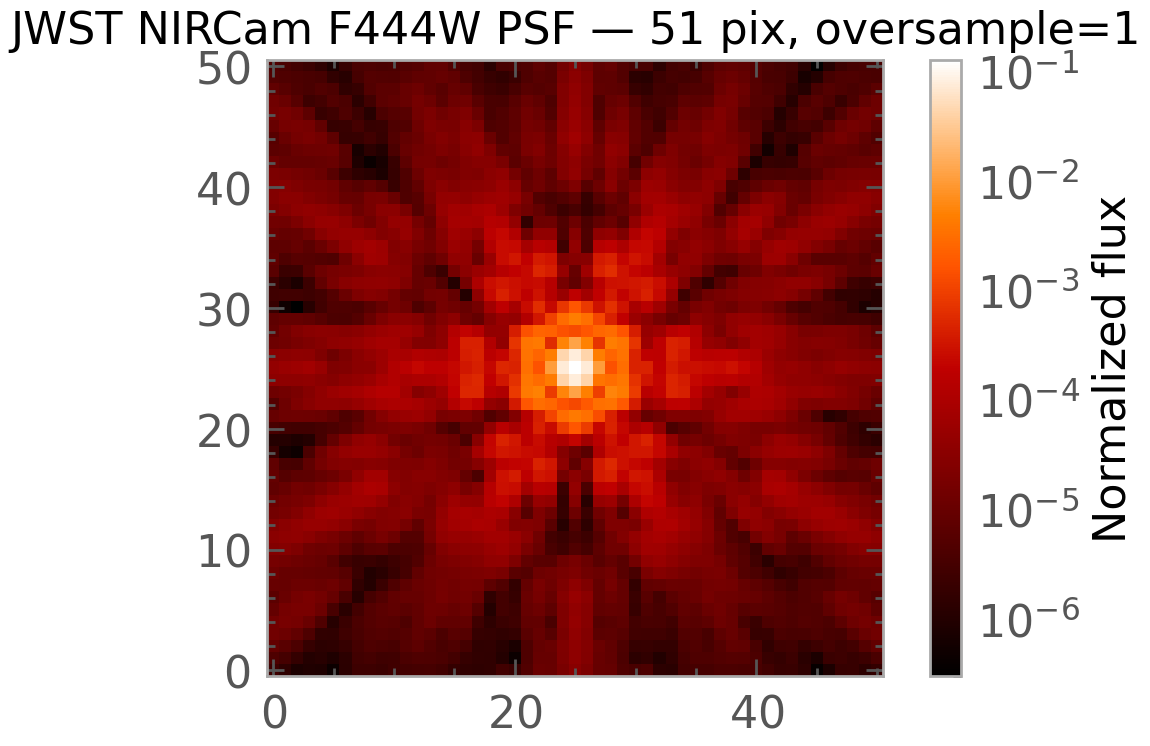

In [293]:
import stpsf
from astropy.io import fits

# 创建 NIRCam 实例 —— F444W 属于 NIRCam 的长波 (LW) 通道
nrc = stpsf.NIRCam()

# 设置 filter
nrc.filter = 'F444W'

# 设置输出 PSF 的像素大小：fov_pixels 指定输出图像的 “detector 采样像素数”。
# 如果你希望 PSF 总直径 ~ 51 pixels (detector scale)，可以直接设 fov_pixels=51。
# oversample=1 表示不要超采样 (即 native detector 像素尺度)。
psf = nrc.calc_psf(fov_pixels=51, oversample=1)

# psf 是一个 astropy.io.fits.HDUList，可以保存为 FITS
psf.writeto('JWST_NIRCam_F444W_PSF_51pix_os1.fits', overwrite=True)

# 可选：显示 PSF 核心
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.imshow(psf[0].data, norm=LogNorm(), origin='lower')
plt.colorbar(label='Normalized flux')
plt.title('JWST NIRCam F444W PSF — 51 pix, oversample=1')
plt.grid(None)
plt.show()


23:03:32 - WARNING - dingo.fitting - No err image for ['resolved/F444W_ID3700/image.fits', 0]
23:03:32 - WARNING - dingo.fitting - The following override keys are not used: set()
23:03:32 - INFO - dingo.fitting - Starting fitting stage 1/1: method=Adam
23:03:32 - INFO - dingo.fitting - Stage 1, Step 1, loss=312.66, lr=0.10000
23:03:32 - INFO - dingo.fitting - Stage 1, Step 100, loss=1.7617, lr=0.10000
23:03:33 - INFO - dingo.fitting - Stage 1, Step 200, loss=1.3598, lr=0.07070
23:03:33 - INFO - dingo.fitting - Stage 1, Step 300, loss=1.3333, lr=0.04998
23:03:34 - INFO - dingo.fitting - Stage 1, Step 400, loss=1.3059, lr=0.03534
23:03:34 - INFO - dingo.fitting - Stage 1, Step 500, loss=1.2502, lr=0.02498
23:03:35 - INFO - dingo.fitting - Stage 1, Step 600, loss=1.2027, lr=0.01766
23:03:35 - INFO - dingo.fitting - Stage 1, Step 700, loss=1.1875, lr=0.01249
23:03:36 - INFO - dingo.fitting - Stage 1, Step 800, loss=1.1813, lr=0.00883
23:03:36 - INFO - dingo.fitting - Stage 1, Step 900, los


[Sérsic - s0]
I_e          = 2.6810872554779053
R_e          = 4.689909934997559
n            = 0.6461296081542969
q            = 0.29774951934814453
theta        = 0.6045576333999634
x0           = 40.471500396728516
y0           = 40.48624801635742

[Sérsic - s1]
I_e          = 6.032519817352295
R_e          = 1.086013913154602
n            = 4.0
q            = 0.10000000149011612
theta        = 1.746060848236084
x0           = 40.15816879272461
y0           = 39.70976638793945


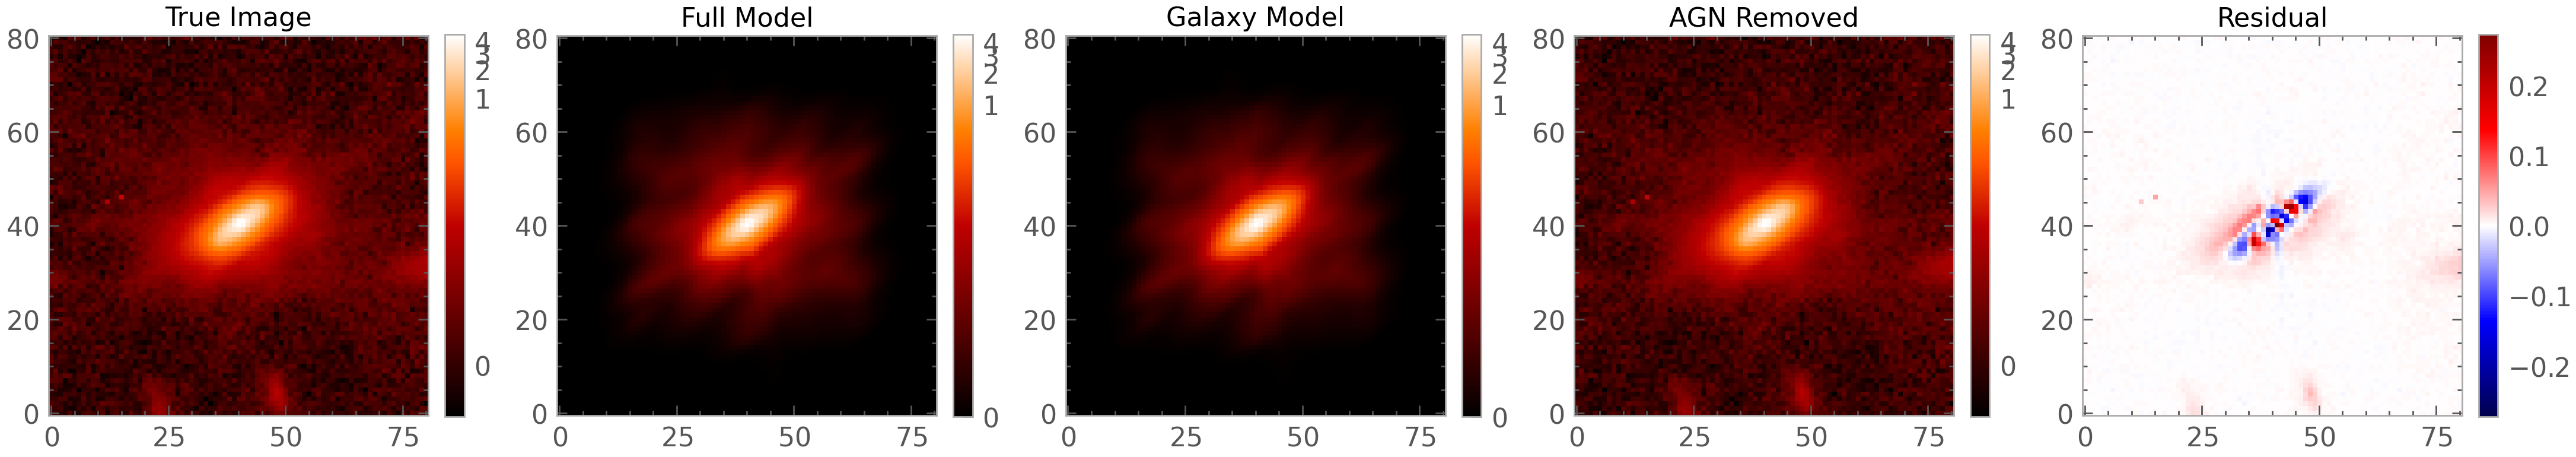

23:03:38 - WARNING - dingo.fitting - No err image for ['resolved/F444W_ID6170/image.fits', 0]
23:03:38 - WARNING - dingo.fitting - The following override keys are not used: set()
23:03:38 - INFO - dingo.fitting - Starting fitting stage 1/1: method=Adam
23:03:38 - INFO - dingo.fitting - Stage 1, Step 1, loss=73.033, lr=0.10000
23:03:39 - INFO - dingo.fitting - Stage 1, Step 100, loss=0.67128, lr=0.10000
23:03:39 - INFO - dingo.fitting - Stage 1, Step 200, loss=0.30807, lr=0.07070
23:03:40 - INFO - dingo.fitting - Stage 1, Step 300, loss=0.27317, lr=0.04998
23:03:40 - INFO - dingo.fitting - Stage 1, Step 400, loss=0.26955, lr=0.03534
23:03:41 - INFO - dingo.fitting - Stage 1, Step 500, loss=0.26856, lr=0.02498
23:03:41 - INFO - dingo.fitting - Stage 1, Step 600, loss=0.26798, lr=0.01766
23:03:42 - INFO - dingo.fitting - Stage 1, Step 700, loss=0.26757, lr=0.01249
23:03:42 - INFO - dingo.fitting - Stage 1, Step 800, loss=0.26727, lr=0.00883
23:03:43 - INFO - dingo.fitting - Stage 1, Step 


[Sérsic - s0]
I_e          = 0.8034164309501648
R_e          = 8.150870323181152
n            = 0.7282373309135437
q            = 0.18909616768360138
theta        = 2.2699062824249268
x0           = 40.18779754638672
y0           = 40.47389602661133

[Sérsic - s1]
I_e          = 5.794486999511719
R_e          = 0.5670368075370789
n            = 4.446096897125244
q            = 0.5057544112205505
theta        = 1.14988112449646
x0           = 40.51577377319336
y0           = 40.050785064697266


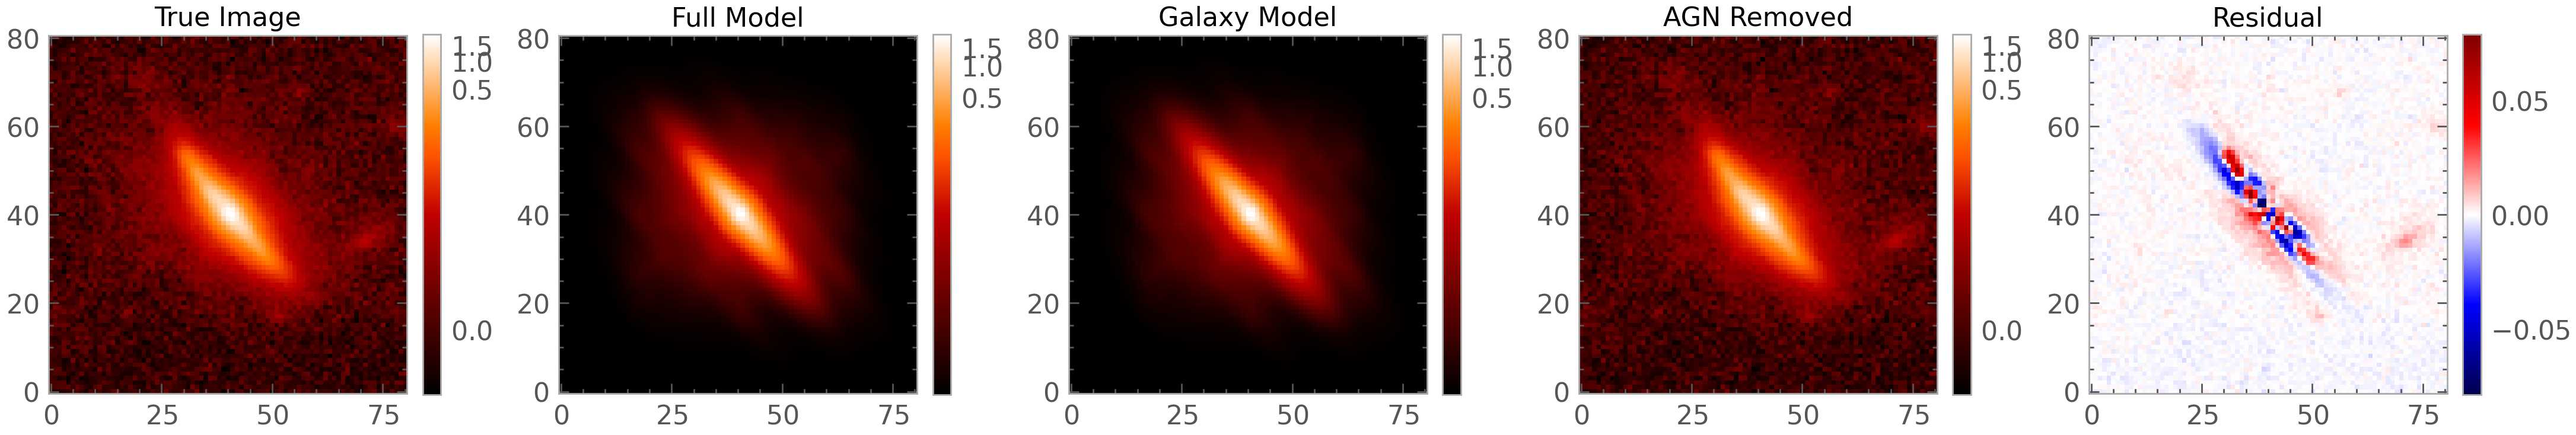

23:03:44 - WARNING - dingo.fitting - No err image for ['resolved/F444W_ID8910/image.fits', 0]
23:03:44 - WARNING - dingo.fitting - The following override keys are not used: set()
23:03:44 - INFO - dingo.fitting - Starting fitting stage 1/1: method=Adam
23:03:44 - INFO - dingo.fitting - Stage 1, Step 1, loss=129.35, lr=0.10000
23:03:45 - INFO - dingo.fitting - Stage 1, Step 100, loss=7.1494, lr=0.10000
23:03:45 - INFO - dingo.fitting - Stage 1, Step 200, loss=3.5458, lr=0.07070
23:03:46 - INFO - dingo.fitting - Stage 1, Step 300, loss=3.4932, lr=0.04998
23:03:46 - INFO - dingo.fitting - Stage 1, Step 400, loss=3.4802, lr=0.03534
23:03:47 - INFO - dingo.fitting - Stage 1, Step 500, loss=3.4758, lr=0.02498
23:03:47 - INFO - dingo.fitting - Stage 1, Step 600, loss=3.4741, lr=0.01766
23:03:48 - INFO - dingo.fitting - Stage 1, Step 700, loss=3.4732, lr=0.01249
23:03:49 - INFO - dingo.fitting - Stage 1, Step 800, loss=3.4728, lr=0.00883
23:03:49 - INFO - dingo.fitting - Stage 1, Step 900, los


[Sérsic - s0]
I_e          = 0.3843815326690674
R_e          = 7.236749649047852
n            = 1.7608271837234497
q            = 0.7696982026100159
theta        = 1.4263942241668701
x0           = 40.56941223144531
y0           = 39.8316764831543

[Sérsic - s1]
I_e          = 5.914144992828369
R_e          = 0.1528932750225067
n            = 4.0
q            = 0.10000000149011612
theta        = 1.5603080987930298
x0           = 40.670772552490234
y0           = 39.49293899536133


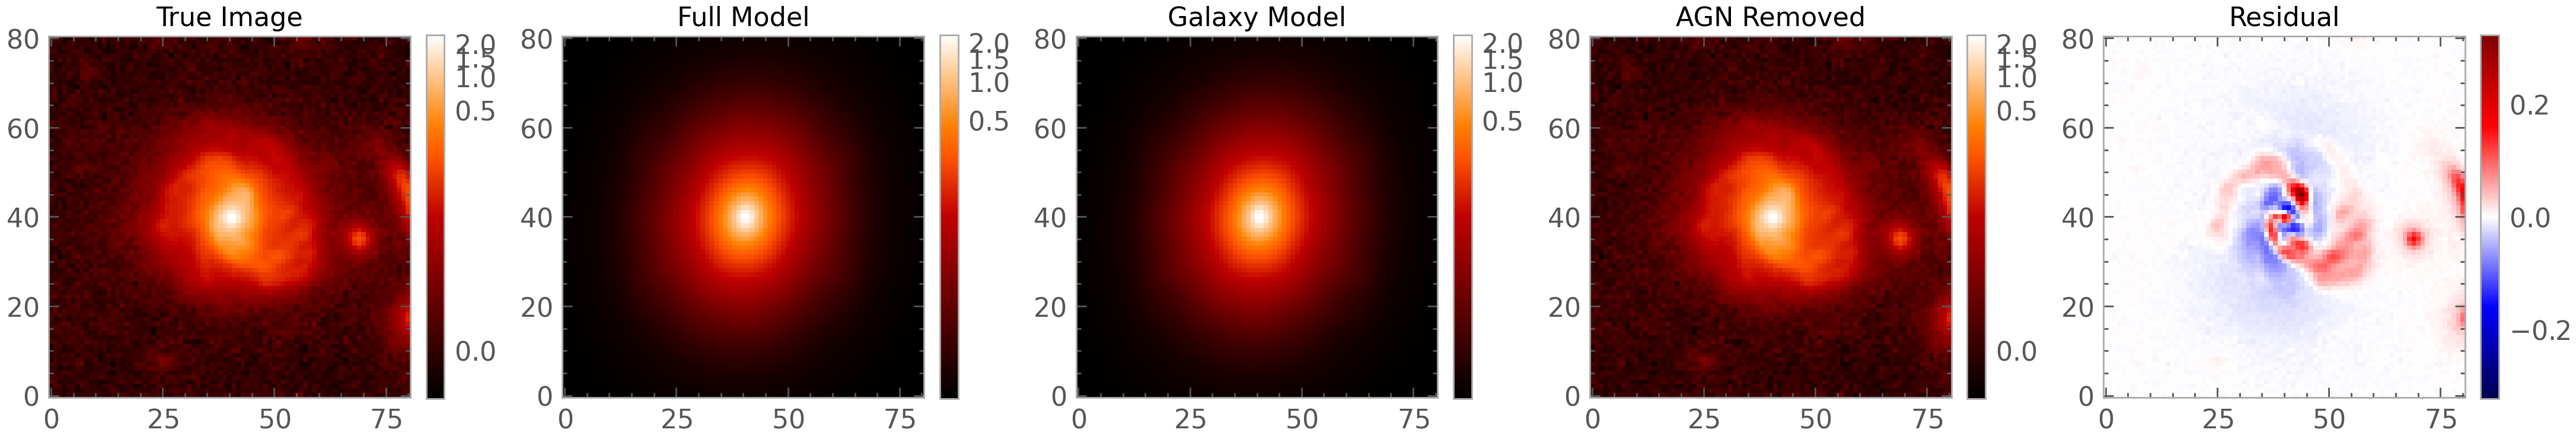

23:03:50 - WARNING - dingo.fitting - No err image for ['resolved/F444W_ID15665/image.fits', 0]
23:03:50 - WARNING - dingo.fitting - The following override keys are not used: set()
23:03:50 - INFO - dingo.fitting - Starting fitting stage 1/1: method=Adam
23:03:50 - INFO - dingo.fitting - Stage 1, Step 1, loss=631.75, lr=0.10000
23:03:51 - INFO - dingo.fitting - Stage 1, Step 100, loss=10.503, lr=0.10000
23:03:51 - INFO - dingo.fitting - Stage 1, Step 200, loss=9.5443, lr=0.07070
23:03:52 - INFO - dingo.fitting - Stage 1, Step 300, loss=9.2669, lr=0.04998
23:03:52 - INFO - dingo.fitting - Stage 1, Step 400, loss=8.771, lr=0.03534
23:03:53 - INFO - dingo.fitting - Stage 1, Step 500, loss=8.2967, lr=0.02498
23:03:53 - INFO - dingo.fitting - Stage 1, Step 600, loss=8.0967, lr=0.01766
23:03:54 - INFO - dingo.fitting - Stage 1, Step 700, loss=8.0199, lr=0.01249
23:03:54 - INFO - dingo.fitting - Stage 1, Step 800, loss=7.9845, lr=0.00883
23:03:55 - INFO - dingo.fitting - Stage 1, Step 900, los


[Sérsic - s0]
I_e          = 0.9055179357528687
R_e          = 6.493882179260254
n            = 1.3996840715408325
q            = 0.8157001733779907
theta        = 2.3856289386749268
x0           = 40.4987907409668
y0           = 40.69915008544922

[Sérsic - s1]
I_e          = 6.065237522125244
R_e          = 1.4435662031173706
n            = 4.018494129180908
q            = 0.10000000149011612
theta        = 1.4230750799179077
x0           = 40.87887191772461
y0           = 40.02854919433594


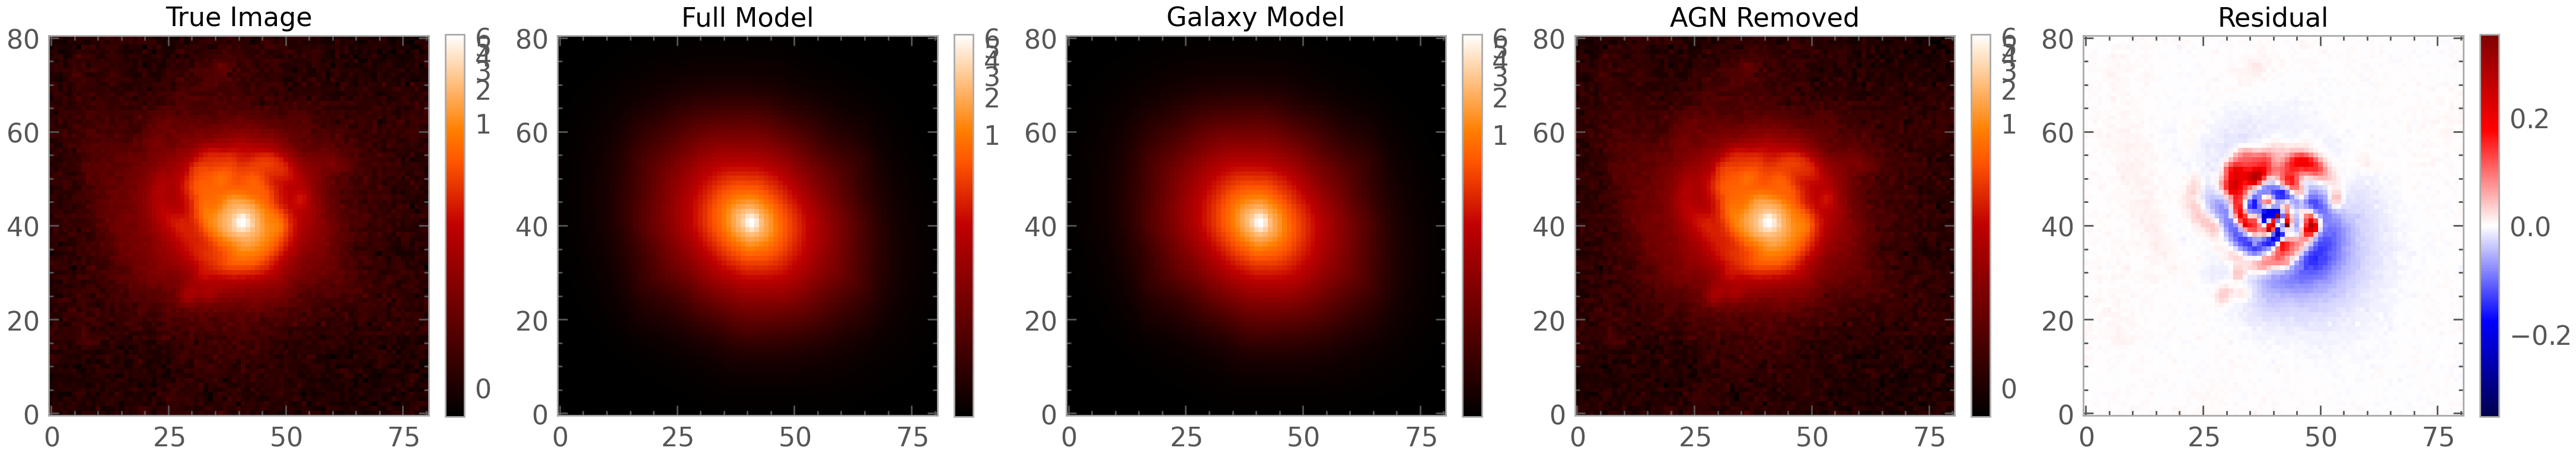

23:03:57 - WARNING - dingo.fitting - No err image for ['resolved/F444W_ID16887/image.fits', 0]
23:03:57 - WARNING - dingo.fitting - The following override keys are not used: set()
23:03:57 - INFO - dingo.fitting - Starting fitting stage 1/1: method=Adam
23:03:57 - INFO - dingo.fitting - Stage 1, Step 1, loss=12.312, lr=0.10000
23:03:57 - INFO - dingo.fitting - Stage 1, Step 100, loss=1.0981, lr=0.10000
23:03:58 - INFO - dingo.fitting - Stage 1, Step 200, loss=0.30171, lr=0.07070
23:03:58 - INFO - dingo.fitting - Stage 1, Step 300, loss=0.12905, lr=0.04998
23:03:59 - INFO - dingo.fitting - Stage 1, Step 400, loss=0.10858, lr=0.03534
23:03:59 - INFO - dingo.fitting - Stage 1, Step 500, loss=0.10345, lr=0.02498
23:04:00 - INFO - dingo.fitting - Stage 1, Step 600, loss=0.10144, lr=0.01766
23:04:00 - INFO - dingo.fitting - Stage 1, Step 700, loss=0.10052, lr=0.01249
23:04:01 - INFO - dingo.fitting - Stage 1, Step 800, loss=0.10004, lr=0.00883
23:04:01 - INFO - dingo.fitting - Stage 1, Step 


[Sérsic - s0]
I_e          = 0.4937487244606018
R_e          = 3.0178279876708984
n            = 1.2581995725631714
q            = 0.5428232550621033
theta        = 0.9409186840057373
x0           = 40.00143051147461
y0           = 40.02383804321289

[Sérsic - s1]
I_e          = 0.11983637511730194
R_e          = 0.5598253011703491
n            = 4.00005578994751
q            = 0.10128409415483475
theta        = 0.2765192985534668
x0           = 39.45274353027344
y0           = 40.57417678833008


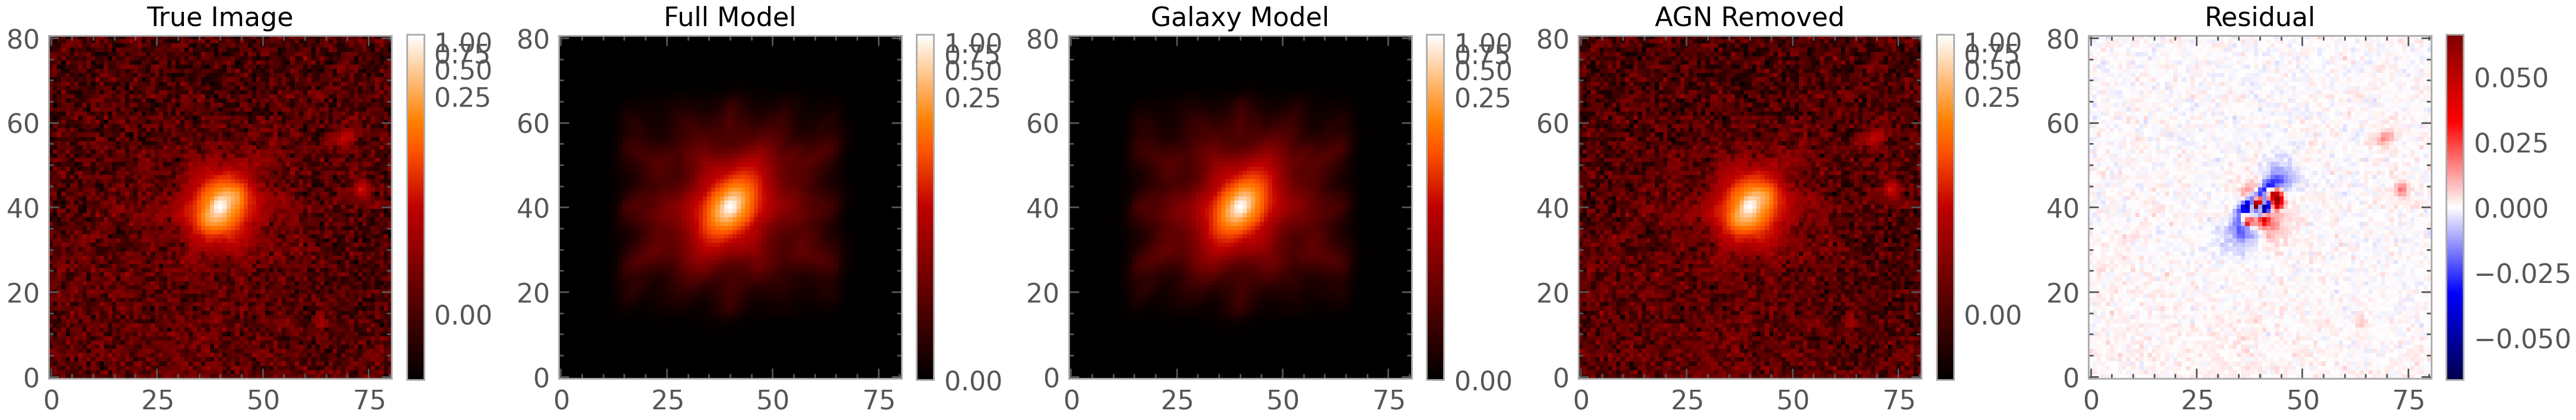

23:04:03 - WARNING - dingo.fitting - No err image for ['resolved/F444W_ID21619/image.fits', 0]
23:04:03 - WARNING - dingo.fitting - The following override keys are not used: set()
23:04:03 - INFO - dingo.fitting - Starting fitting stage 1/1: method=Adam
23:04:03 - INFO - dingo.fitting - Stage 1, Step 1, loss=128.13, lr=0.10000
23:04:03 - INFO - dingo.fitting - Stage 1, Step 100, loss=3.0799, lr=0.10000
23:04:04 - INFO - dingo.fitting - Stage 1, Step 200, loss=2.6997, lr=0.07070
23:04:04 - INFO - dingo.fitting - Stage 1, Step 300, loss=2.5383, lr=0.04998
23:04:05 - INFO - dingo.fitting - Stage 1, Step 400, loss=2.5063, lr=0.03534
23:04:05 - INFO - dingo.fitting - Stage 1, Step 500, loss=2.4933, lr=0.02498
23:04:06 - INFO - dingo.fitting - Stage 1, Step 600, loss=2.487, lr=0.01766
23:04:06 - INFO - dingo.fitting - Stage 1, Step 700, loss=2.4837, lr=0.01249
23:04:07 - INFO - dingo.fitting - Stage 1, Step 800, loss=2.4818, lr=0.00883
23:04:07 - INFO - dingo.fitting - Stage 1, Step 900, los


[Sérsic - s0]
I_e          = 0.3372724652290344
R_e          = 8.042341232299805
n            = 2.082549571990967
q            = 0.6254637241363525
theta        = 0.7266873717308044
x0           = 37.86582565307617
y0           = 39.92398452758789

[Sérsic - s1]
I_e          = 5.807112693786621
R_e          = 0.09725473821163177
n            = 4.0
q            = 0.10000000149011612
theta        = 0.14361020922660828
x0           = 40.47502899169922
y0           = 39.30704116821289


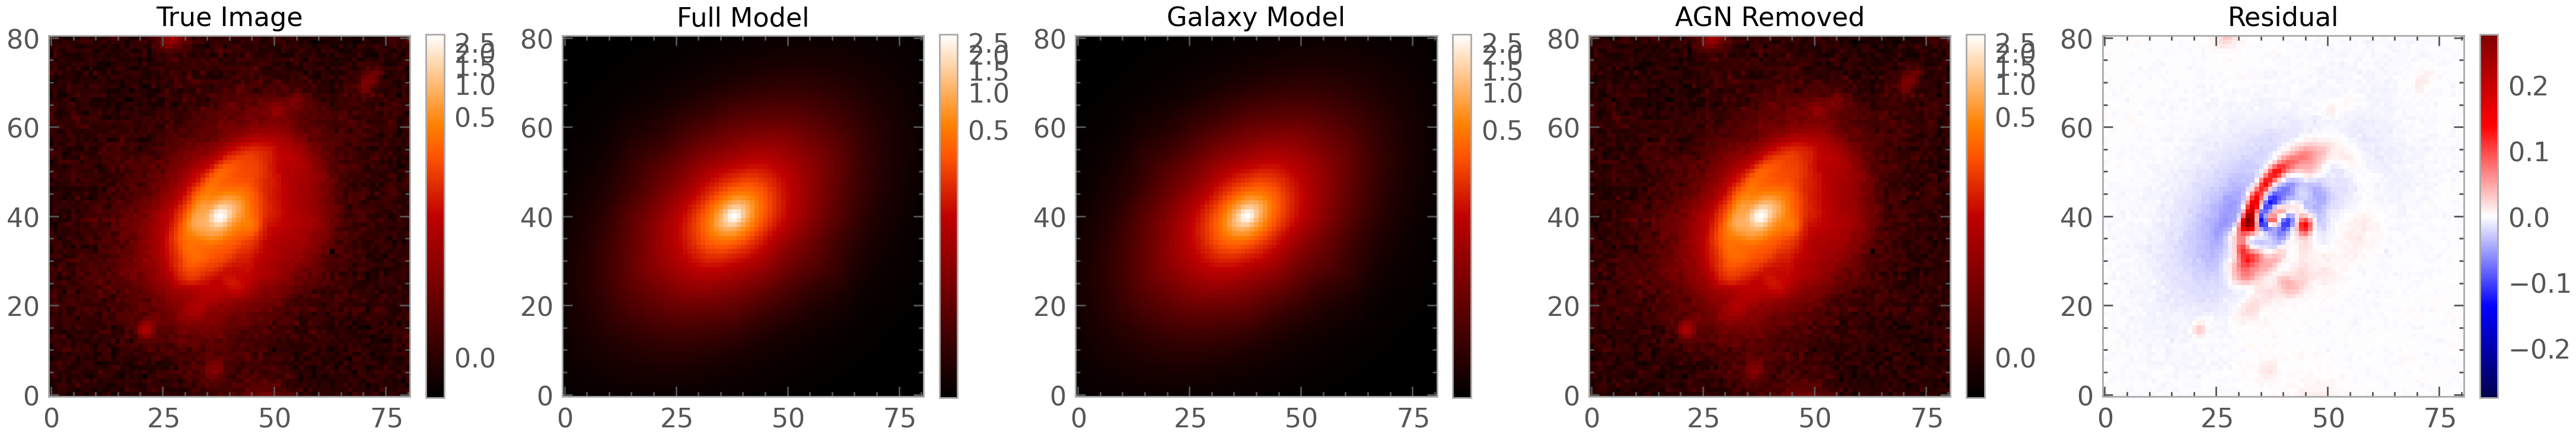

23:04:09 - WARNING - dingo.fitting - No err image for ['resolved/F444W_ID21636/image.fits', 0]
23:04:09 - WARNING - dingo.fitting - The following override keys are not used: set()
23:04:09 - INFO - dingo.fitting - Starting fitting stage 1/1: method=Adam
23:04:09 - INFO - dingo.fitting - Stage 1, Step 1, loss=175.01, lr=0.10000
23:04:09 - INFO - dingo.fitting - Stage 1, Step 100, loss=84.161, lr=0.10000
23:04:10 - INFO - dingo.fitting - Stage 1, Step 200, loss=83.18, lr=0.07070
23:04:10 - INFO - dingo.fitting - Stage 1, Step 300, loss=83.177, lr=0.04998
23:04:11 - INFO - dingo.fitting - Stage 1, Step 400, loss=83.176, lr=0.03534
23:04:11 - INFO - dingo.fitting - Stage 1, Step 500, loss=83.176, lr=0.02498
23:04:12 - INFO - dingo.fitting - Stage 1, Step 600, loss=83.176, lr=0.01766
23:04:12 - INFO - dingo.fitting - Stage 1, Step 700, loss=83.176, lr=0.01249
23:04:13 - INFO - dingo.fitting - Stage 1, Step 800, loss=83.176, lr=0.00883
23:04:13 - INFO - dingo.fitting - Stage 1, Step 900, los


[Sérsic - s0]
I_e          = 0.820061206817627
R_e          = 5.42814302444458
n            = 1.6546387672424316
q            = 0.3506617546081543
theta        = 1.3852226734161377
x0           = 40.240848541259766
y0           = 39.54347229003906

[Sérsic - s1]
I_e          = 5.825822830200195
R_e          = 0.20007649064064026
n            = 4.0
q            = 0.10000000149011612
theta        = 1.6009924411773682
x0           = 39.286197662353516
y0           = 39.39805221557617


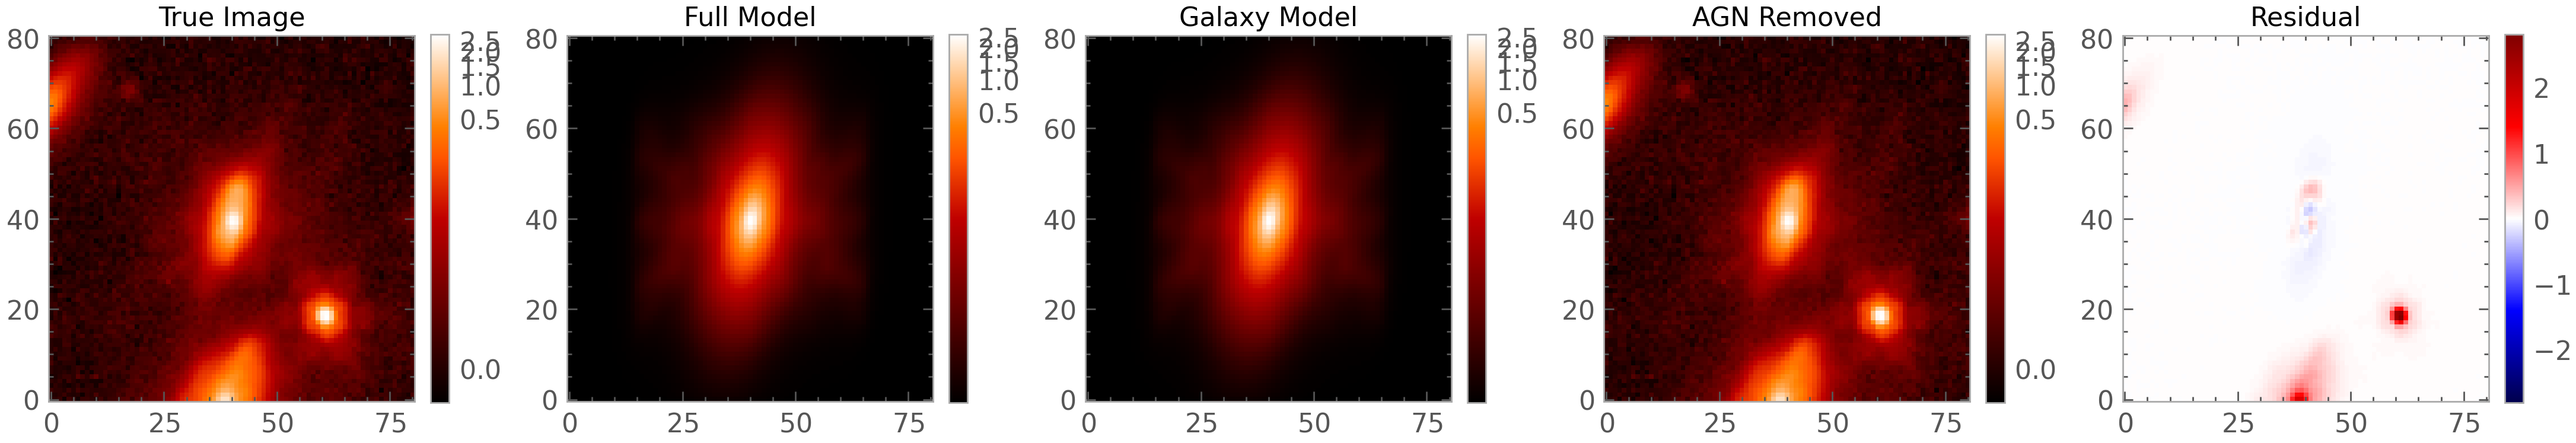

In [294]:
results = {}

for ID in ids:
    filter = 'F444W'
    # ---------- 1) 构造路径 ----------
    oversample = 1
    im_path = f'resolved/F444W_ID{ID}/image.fits'
    psf_path = f'JWST_NIRCam_F444W_PSF_51pix_os1.fits'

    # 读尺寸决定 r_fit（严格要求：方形+以中心为原点）
    r_fit = fits.getdata(im_path).shape[0]//2

    channel = 'LW'

    # ---------- 3) 组装 fitting 配置 ----------

    config = {
        'summary': {
            'name': f'ID{ID}',
            'ra': 0,
            'dec': 0,
            'z': 0,
            'mode': 'images',
            'lambda_rest': 0.656,
            'filter': f'{filter}',
            'r_fit': r_fit,
        },
        'direct': {
            filter: {
                'im0': {
                    'path': [im_path, 0],
                    'oversample': oversample,
                    'psf': 'psf0',
                    'dx': 0., # TODO: warning if all dx dy are free
                    'dy': 0.,
                    'wt': 1.,
                    'zp': 0.,
                }
            }
        },
        'psfs': {
            filter: {
                'psf0': {
                    'oversample': oversample,
                    'path': [psf_path, 0],
                    'scale': 1.,
                    'zp': 0.,
                }
            }
        },
        'sersic': {
            's0': { # disk
                'I_e': 1e-6,
                'R_e': 5,
                'n': 1.0,
                'q': 0.1,
                'theta': np.pi/4,
                'x0': r_fit,
                'y0': r_fit,
            },
            's1': { # bulge
                'I_e': 1e-6,
                'R_e': 1,
                'n': 4.0,
                'q': 0.1,
                'theta': np.pi/4,
                # 'x0': 'sersic.s0.x0',
                # 'y0': 'sersic.s0.y0',
                'x0': r_fit,
                'y0': r_fit,
            },
        },
        'psf': {
            'p0': {
                'x_psf': r_fit,
                'y_psf': r_fit,
                'I_psf': 0,
            }
        },
        'fitting': [{
            # 'method': 'LBFGS',
            # 'maxiter': 20,
            'method': 'Adam',
            'maxiter': 1000,
            '_log_cadence': 100,
            'scheduler': 'StepLR',
            '_step_size': 100,
            'default': {
                'fit': True,
                'lr': 0.1,
                'max': '1e10',
                'min': '-1e10',
            },
            'override': {
                # freeze image
                f'direct.{filter}.im0.dx': {'fit': False},
                f'direct.{filter}.im0.dy': {'fit': False},
                f'direct.{filter}.im0.wt': {'fit': False},
                f'direct.{filter}.im0.zp': {'fit': False},
                # psf image is assumed to be perfect
                f'psfs.{filter}.psf0.scale': {'fit': False}, # should keep 1
                f'psfs.{filter}.psf0.zp': {'fit': False},
                # no point source
                'psf.p0.I_psf': {'fit': False},
                # disk
                'sersic.s0.I_e': {'min': 0, 'lr': 1},
                'sersic.s0.R_e': {'min': 0.},
                # 'sersic.s0.n': {'fit': False},
                'sersic.s0.q': {'min': 0.1, 'max': 1},
                
                # bulge
                'sersic.s1.I_e': {'min': 0, 'lr': 1},
                'sersic.s1.R_e': {'min': 0.},
                'sersic.s1.n': {'min': 4.},
                'sersic.s1.q': {'min': 0.1, 'max': 1},
                # 'sersic.s1.n': {'fit': False},
            },
        }],
    }
    
    
    # 写入本滤镜的临时配置文件
    config_dir = '.'
    os.makedirs(config_dir, exist_ok=True)
    config_path = os.path.join(config_dir, f'fitting_{filter}.yaml')
    with open(config_path, 'w') as f:
        yaml.dump(config, f, Dumper=yaml.SafeDumper, sort_keys=False)

    # ---------- 4) 运行拟合 ----------
    image_fitter = fitting.ImagesFitter(config_path=config_path, device=device)
    # 可再次调整（与上文一致）
    # image_fitter.config['fitting'][0]['method'] = 'Adam'
    # image_fitter.config['fitting'][0]['maxiter'] = 200
    # image_fitter.config['fitting'][0]['_log_cadence'] = 200
    # image_fitter.config['fitting'][0]['scheduler'] = 'StepLR'
    # image_fitter.config['fitting'][0]['_step_size'] = 50
    
    all_losses, all_lrs = image_fitter.fit_all()

    # ---------- 5) 拿到拟合出的组件与真值图 ----------
    iid = next(iter(image_fitter.direct_images[filter].keys()))
    sersic_params, psf_params, direct_params = image_fitter.get_params()
    sersic_models, psf_models = image_fitter.get_fitted_component(iid=iid)

    gal_model = np.sum([i for i in sersic_models.values()], axis=0) if len(sersic_models)>0 else 0.0
    psf_model = np.sum([i for i in psf_models.values()], axis=0) if len(psf_models)>0 else 0.0
    true_image = image_fitter.get_true_image(iid=iid)


    # ---------- 5.1) 显示parameters ----------
    def print_params(title, params_dict):
        for cid, params in params_dict.items():
            print(f'\n[{title} - {cid}]')
            for name, val in params.items():
                if isinstance(val, (numbers.Number, np.number)):
                    print(f'{name:12s} = {val:.4f}')
                else:
                    print(f'{name:12s} = {val}')

    print_params('Sérsic', sersic_params)
    # print_params('PSF',   psf_params)
    # print_params('Image',   direct_params)
    
    plot.plot_image_fitting_result(true_image, gal_model, psf_model)

    # ---------- 6) 误差图（若存在） ----------
    try:
        err_image = fits.getdata(im_path, 2)
        # err_image = dutils.iterative_nan_fill(err_image)
    except Exception:
        err_image = None

    # ---------- 7) 保存到结果字典 ----------
    results[ID] = {
        'fitter': image_fitter,
        'iid': iid,
        'true_image': true_image,
        'sersic_models': sersic_models,
        'sersic_params': sersic_params,
        'direct_params': direct_params,
        'losses': all_losses,
        'lrs': all_lrs,
        'err_image': err_image,
    }

In [295]:
# calculate flux measurement


def nircam_miri_pixscale(fn, oversample):
    """
    根据滤镜名称自动判断:
      - NIRCam SW  → 0.031"/pix
      - NIRCam LW  → 0.063"/pix
      - MIRI       → 0.11"/pix  （与 kpc_pix_scale 完全一致）
    并返回 oversample 后的 pixscale_arcsec。
    """
    # 判定 SW/LW/MIRI（与 kpc_pix_scale 完全一致）
    try:
        lam = int(fn[1:4])   # 'f115w' → 115；MIRI 如 'f770w' → 770
    except Exception:
        lam = 999  # 容错：自动落入 MIRI

    if lam < 240:       # NIRCam SW
        native_scale = 0.031
    elif lam < 500:     # NIRCam LW
        native_scale = 0.063
    else:               # MIRI
        native_scale = 0.11

    return native_scale / float(oversample)

def mjysr_to_uJy_per_pix(values_mjysr, filt_names, oversamples):
    """
    将 MJy/sr （每像素的 surface brightness）转换为 µJy/pix。

    Parameters
    ----------
    values_mjysr : array-like
        输入的 MJy/sr 数组（可为 agn_flux、host_flux、host_err 等）
    filt_names : list[str]
        各滤镜名称，如 ['f090w','f115w',...]
    oversamples : list[int]
        各滤镜的 oversample 值

    Returns
    -------
    values_uJy : ndarray
        转换后的 µJy/pix
    """
    values_mjysr = np.asarray(values_mjysr)
    pixel_size = np.array([
        nircam_miri_pixscale(fn, over)
        for fn, over in zip(filt_names, oversamples)
    ])  # arcsec/pix

    pixel_area = pixel_size**2            # arcsec^2/pix
    sr_to_arcsec2 = 206265.0**2          # arcsec^2/sr

    # MJy/sr → Jy/sr → Jy/pix → µJy/pix
    factor = 1e12 * pixel_area / sr_to_arcsec2

    return values_mjysr * factor

disk_sums = np.array([np.sum(results[ID]['sersic_models']['s0'])
             for ID in ids])

bulge_sums = np.array([np.sum(results[ID]['sersic_models']['s1'])
             for ID in ids])

disk_uJy = mjysr_to_uJy_per_pix(disk_sums, ['f444w']*len(disk_sums), [1]*len(disk_sums))

def uJy_to_ab(uJy):
    '''Convert flux density from microJy to AB magnitude.'''
    uJy=np.asarray(uJy, dtype=float)
    return 23.9 - 2.5*np.log10(uJy)


disk_mag = [uJy_to_ab(uJy) for uJy in disk_uJy]

mag_list = disk_mag

mag_list, disk_uJy

([20.866113430796922,
  21.4160451701179,
  20.545701948155166,
  19.891174205521395,
  22.664217718636394,
  20.597011567029103,
  21.223780797225814],
 array([16.351,  9.853, 21.964, 40.136,  3.121, 20.951, 11.762]))

In [296]:
bulge_sums / disk_sums

array([0.076, 0.117, 0.   , 0.069, 0.001, 0.   , 0.   ], dtype=float32)

In [297]:
import numpy as np
from astropy.cosmology import Planck18 as cosmo

def apparent_to_absolute_mag(mag_list, z_list):
    """
    给定 apparent AB mag + redshift z，计算绝对星等 M。
    未包含 K-correction（如需我可以加）。
    """
    mag_list = np.array(mag_list, dtype=float)
    z_list = np.array(z_list, dtype=float)

    M_list = []

    for m, z in zip(mag_list, z_list):
        if not np.isfinite(m) or not np.isfinite(z):
            M_list.append(np.nan)
            continue

        # 光度距离 (pc)
        DL_pc = cosmo.luminosity_distance(z).to('pc').value

        # 绝对星等公式：M = m - 5 log10( DL/10 )
        M = m - 5*np.log10(DL_pc/10.0)

        M_list.append(M)

    return M_list

z_list = list(new_table['z'])

M_list = apparent_to_absolute_mag(mag_list, z_list)
M_list

[-23.604365141836922,
 -23.034332532777402,
 -24.55877679842578,
 -24.66886286731539,
 -22.29012545214689,
 -24.39464466287148,
 -23.40297563013206]

In [298]:
# [results[ID]['sersic_params']['s0'] for ID in ids]

In [299]:
nn = np.array([results[ID]['sersic_params']['s0']['n'] for ID in ids])
R_e = np.array([results[ID]['sersic_params']['s0']['R_e'] for ID in ids])
R_d = R_e/1.678
R_22 = R_d*2.2

print(R_22)

import numpy as np
from scipy.special import gammaincinv

def bn_from_n(n):
    '''Approximation for b_n (Ciotti & Bertin 1999 style).'''
    n=float(n)
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_r80(Re, n):
    '''
    Compute R80 for a Sersic profile with given Re and n.
    Re: effective radius (same units as desired R80)
    n : Sersic index
    '''
    Re=float(Re)
    n=float(n)
    bn=bn_from_n(n)
    # gammaincinv gives x such that P(a,x)=y, where P is regularized lower gamma
    x80=gammaincinv(2*n, 0.8)
    R80=Re*(x80/bn)**n
    return R80

R_80 = [sersic_r80(Re, n) for Re, n in zip(R_e, nn)]

print(R_80)

[ 6.149 10.686  9.488  8.514  3.957 10.544  7.117]
[7.517959046474259, 13.418636488378262, 15.52761312480199, 12.838373803228329, 5.7630571213991475, 18.444847621869638, 11.37981295651241]


In [300]:
def arctan_vcirc_np(r, V_rot=200., R_v=2., **kwargs):
    '''Arctangent rotation curve: r → V(r) (NumPy).'''
    r=np.asarray(r, dtype=float)
    return (2/np.pi)*V_rot*np.arctan(r/R_v)

v_22 = arctan_vcirc_np(R_22, **fit_results[ID]['velocity_params'])
v_80 = arctan_vcirc_np(R_80, **fit_results[ID]['velocity_params'])

v_22, v_80

(array([223.66 , 260.333, 253.699, 247.074, 184.188, 259.618, 234.833]),
 array([238.749, 271.288, 277.225, 269.33 , 218.373, 283.269, 263.579]))

TF scatter = 0.642 mag


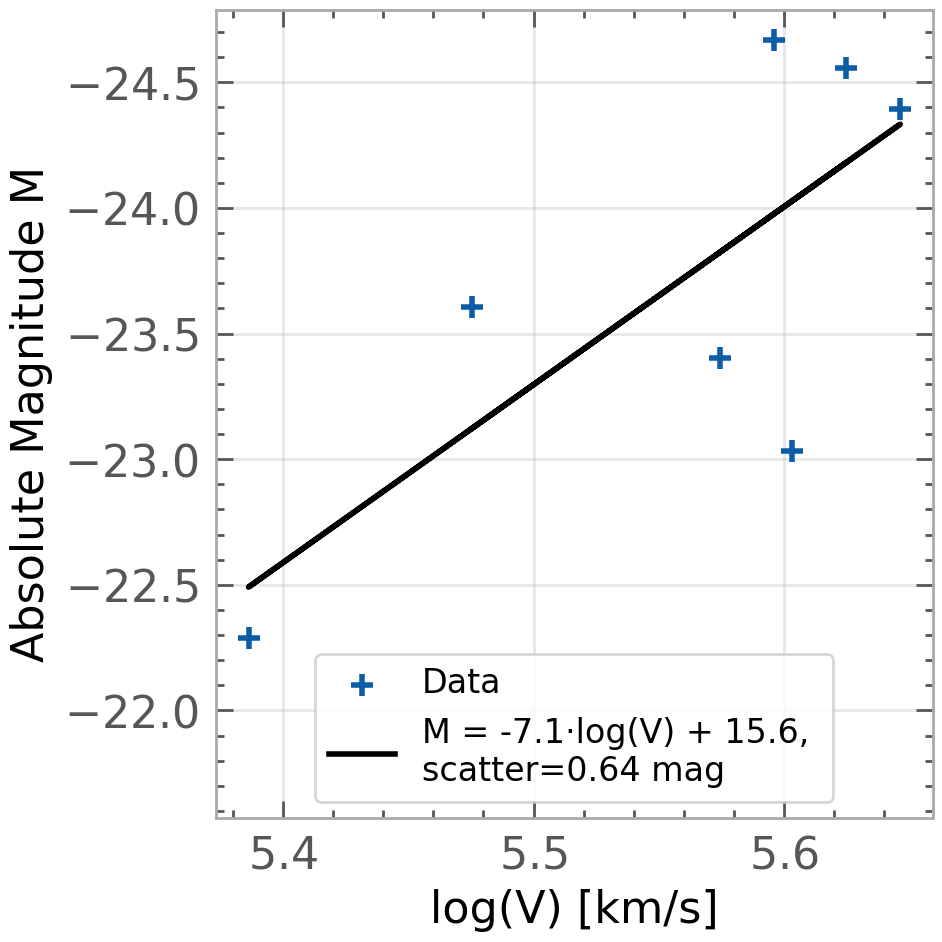

'M = -7.1·log(V) + 15.6, \nscatter=0.64 mag'

In [301]:
import numpy as np
import matplotlib.pyplot as plt

# 数据
# x = np.log(tf_v_list)   # log(V)
# x = np.log(v_22)   # log(V)
x = np.log(v_80)
y = np.array(M_list)

# 拟合
a, b = np.polyfit(x, y, 1)
y_pred = a*x + b

# scatter
N = len(x)
residuals = y - y_pred
scatter = np.sqrt(np.sum(residuals**2) / (N - 2))
print('TF scatter = {:.3f} mag'.format(scatter))

# 作图
plt.figure(figsize=(5, 5))

plt.scatter(x, y, color='C0', s=60, marker='+', label='Data')
plt.plot(x, y_pred, color='k', lw=2,
         label=f'M = {a:.1f}·log(V) + {b:.1f}, \nscatter={scatter:.2f} mag')

ymin, ymax = plt.ylim()
plt.ylim(ymin, ymax + 0.6)
plt.gca().invert_yaxis()

plt.xlabel('log(V) [km/s]')
plt.ylabel('Absolute Magnitude M')

plt.legend(frameon=True, loc='lower center', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig/tf_relation.pdf')
plt.show()

f'M = {a:.1f}·log(V) + {b:.1f}, \nscatter={scatter:.2f} mag'

In [302]:
import numpy as np
from astropy.table import Table
from astropy.io import ascii

ids = [3700, 6170, 8910, 15665, 16887, 21619, 21636]

# 假定你已经有：
# paA_table_filtered
# fit_results
# tf_v_list, mag_list, M_list  # （长度都为 len(ids)）

# -------------------------------
# 从 paA_table_filtered 按 ids 取行
# -------------------------------
row_indices = [np.where(paA_table_filtered['ID']==ID)[0][0] for ID in ids]
base = paA_table_filtered[row_indices]

# =========================================================
# 表 1：在 paA_table_filtered 后面添加 Tully–Fisher 量
#      列：原始 (ID, RA, DEC, z, wave, ...) + tf_v, mag, Mag
# =========================================================
tf_table = base.copy()

tf_table['mag']  = mag_list     # 视星等
tf_table['Mag']  = M_list       # 绝对星等
tf_table['v_80'] = v_80

# --------- 格式设置（可按你前面的习惯来）---------
tf_table['RA'].format    = '%.5f'
tf_table['DEC'].format   = '%.5f'
tf_table['z'].format     = '%.4f'
tf_table['wave'].format  = '%.3f'
tf_table['mag'].format   = '%.3f'
tf_table['Mag'].format   = '%.3f'
tf_table['v_80'].format  = '%.3f'

# 导出 LaTeX（文件名可以自己改）
ascii.write(tf_table, format='latex', output='table_tf_obs.tex', overwrite=True)
ascii.write(tf_table, format='latex', overwrite=True)



# =========================================================
# 表 2：ID + 拟合得到的动力学参数（来自 fit_results）
#      列：ID, V_rot, R_v, x0_v, y0_v, theta_v, inc_v
# =========================================================

V_rot_list   = []
R_v_list     = []
x0_v_list    = []
y0_v_list    = []
theta_v_list = []
inc_v_list   = []

for ID in ids:
    vp = fit_results[ID]['velocity_params']
    V_rot_list.append(float(vp['V_rot']))
    R_v_list.append(float(vp['R_v']))
    x0_v_list.append(float(vp['x0_v']))
    y0_v_list.append(float(vp['y0_v']))
    theta_v_list.append(float(vp['theta_v']))
    inc_v_list.append(float(vp['inc_v']))

fit_table = Table()
fit_table['ID']      = ids
fit_table['V_rot']   = V_rot_list
fit_table['R_v']     = R_v_list
fit_table['x0_v']    = x0_v_list
fit_table['y0_v']    = y0_v_list
fit_table['theta_v'] = theta_v_list
fit_table['inc_v']   = inc_v_list

# --------- 格式设置 ---------
fit_table['V_rot'].format   = '%.1f'
fit_table['R_v'].format     = '%.3f'
fit_table['x0_v'].format    = '%.3f'
fit_table['y0_v'].format    = '%.3f'
fit_table['theta_v'].format = '%.3f'
fit_table['inc_v'].format   = '%.3f'

ascii.write(fit_table, format='latex', output='table_tf_fitparams.tex', overwrite=True)
ascii.write(fit_table, format='latex', overwrite=True)

\begin{table}
\begin{tabular}{cccccccc}
ID & RA & DEC & z & wave & mag & Mag & v_80 \\
3700 & 63.94578 & -24.18057 & 1.1231 & 3.979 & 20.866 & -23.604 & 238.749 \\
6170 & 63.94276 & -24.17143 & 1.1147 & 3.966 & 21.416 & -23.034 & 271.288 \\
8910 & 63.94015 & -24.16551 & 1.4233 & 4.543 & 20.546 & -24.559 & 277.225 \\
15665 & 64.00784 & -24.14891 & 1.1613 & 4.053 & 19.891 & -24.669 & 269.330 \\
16887 & 64.00262 & -24.14865 & 1.3456 & 4.399 & 22.664 & -22.290 & 218.373 \\
21619 & 64.00251 & -24.13402 & 1.3645 & 4.433 & 20.597 & -24.395 & 283.269 \\
21636 & 63.99707 & -24.13483 & 1.1906 & 4.109 & 21.224 & -23.403 & 263.579 \\
\end{tabular}
\end{table}
\begin{table}
\begin{tabular}{ccccccc}
ID & V_rot & R_v & x0_v & y0_v & theta_v & inc_v \\
3700 & -310.8 & 2.063 & 40.959 & 39.822 & 0.467 & 0.848 \\
6170 & 308.1 & 2.791 & 37.024 & 38.327 & -0.722 & 0.735 \\
8910 & 314.3 & 3.334 & 33.700 & 37.742 & -0.414 & 0.782 \\
15665 & -312.7 & 2.341 & 42.295 & 41.380 & -0.765 & 0.694 \\
16887 & 299.2 &